<font size="5">**Text Mining, NLP e Machine Learning applicato**</font><br>

> (c) 2026 Antonio Piemontese


**Seconda mezza giornata (4 ore)** del corso *«Introduzione ai Sistemi AI: algoritmi AI/ML e sviluppo assistito con GitHub Copilot & Cursor»*

> *Tecniche essenziali per trasformare dati testuali in informazioni utilizzabili.*


⚠️ In conformità con la legge sulla AI pubblicata in G.U. il 25.9.25 ed entrata in vigore il 10.10.2025, si comunica che parti di questo notebook sono state realizzate con il supporto di strumenti di AI generativa (chatGPT 5.4, Claude Code, Claude Opus 4.6, Gemini 3.1).

---
**Legenda delle icone (standard) usate nel notebook**

👉 punto di attenzione, il "succo"<br>
📌 nota / inizio di una nota<br>
📦 punto elenco importante<br>
📊 dati/numeri<br>
🔹 punto elenco normale<br>
⭐ punto elenco importante<br>
✅ punto risolto, positivo<br>
❌ punto negativo, da evitare<br>
⚠️ attenzione, warning, allarme<br>
💡 idea chiave<br>
🧠 idea intuitiva<br>
📝 sintesi / bottom-line<br>
⟶ conseguenza, effetto, passo successivo<br>
**🔧 necessaria qui la personalizzazione del notebook**

---

## 0. Che cosa costruiamo oggi

In questa mezza giornata costruiamo, un pezzo alla volta, una piccola **catena di lavorazione** che parte da una cartella piena di file PDF e arriva a una tabella di informazioni utilizzabili da un programma: per ogni documento, *di che tipo è*, *a quali altri documenti somiglia* e *quali dati contiene* (date, importi, codici).

Tre parole ricorrono nel titolo e conviene chiarirle subito, perché le useremo per tutta la giornata:

- **Text mining** (letteralmente «estrazione mineraria dal testo»): l'insieme delle tecniche con cui ricaviamo informazione utile da grandi quantità di testo, cioè da dati **non strutturati**. Un dato è *strutturato* quando sta già in righe e colonne con un significato preciso (una tabella di database); è *non strutturato* quando è testo libero, come il corpo di una e-mail o di un PDF.
- [**NLP**](https://it.wikipedia.org/wiki/Elaborazione_del_linguaggio_naturale) (*Natural Language Processing*, elaborazione del linguaggio naturale): le tecniche con cui un programma tratta il linguaggio umano (dividere un testo in parole, riconoscere nomi e date, confrontare il significato di due frasi…). Il text mining *usa* l'NLP come cassetta degli attrezzi.
- **Machine learning** o **ML** (apprendimento automatico): invece di scrivere a mano le regole («se il testo contiene *bonifico* allora è una fattura»), mostriamo a un algoritmo molti esempi già risolti e lasciamo che sia lui a ricavare le regole. Il risultato dell'apprendimento si chiama **modello**.

Il filo conduttore è lo stesso del programma concordato:

| Punto del programma | Dove lo trattiamo |
|---|---|
| Pulizia, normalizzazione e tokenizzazione del testo | Sezioni **1** e **2** |
| Panoramica su bag-of-words, TF-IDF, embeddings e similarity search | Sezione **3** |
| Esempi di classificazione, clustering ed estrazione di informazioni da testi | Sezioni **4**, **5** e **6** |
| Costruzione semplificata di una pipeline di text mining, con Python e strumenti AI per la generazione assistita del codice | Sezione **7** ed esercizi «con l'assistente» lungo tutto il percorso |

## ⚠️ 0.1 Assunzioni di partenza — da leggere e confermare prima di usare il materiale

Questo notebook è stato preparato **senza conoscere** alcuni dettagli dell'aula e dell'azienda. Elenchiamo qui, in modo esplicito, tutto ciò che abbiamo dato per buono: se un'assunzione non vale, la colonna di destra indica che cosa cambiare.

| # | Che cosa assumiamo | Se l'assunzione non vale |
|---|---|---|
| **A1** | **Pubblico**: sviluppatori software con esperienza di programmazione ma **senza** esperienza specifica di NLP o di machine learning. Python viene letto senza difficoltà, anche se per qualcuno non è il linguaggio di tutti i giorni (il programma cita anche C#). | Con un pubblico già esperto di ML possiamo saltare le parti «a mano» delle sezioni 3 e 4 e dedicare più tempo alle sezioni ⭐. |
| **A2** | **Ambiente**: VS Code con le estensioni *Python* e *Jupyter*, Python 3.10 o successivo (consigliato 3.11 o 3.12), possibilità di installare pacchetti con `pip` o `conda`. | Se i PC sono bloccati, occorre far preinstallare l'ambiente (comandi nella sezione 0.3) prima della lezione. |
| **A3** | **Rete**: in aula c'è accesso a Internet per installare le librerie. Lo scaricamento del modello di embedding (circa 0,5 GB) e del modello linguistico di spaCy è **facoltativo**: se manca, il notebook se ne accorge e prosegue da solo con una tecnica di ripiego. | Senza rete, tutto il percorso obbligatorio funziona comunque, purché le librerie di base siano già installate. |
| **A4** | **Dati**: non abbiamo documenti reali dell'azienda e, per riservatezza, non li vorremmo comunque dentro un notebook didattico. Lavoriamo quindi su un **corpus sintetico** (cioè fabbricato da noi) di circa 330 brevi PDF in italiano, generato dal notebook stesso. Abbiamo ipotizzato **cinque tipi di documento: *fattura*, *contratto*, *assistenza* (segnalazioni tecniche), *reclamo*, *candidatura***. Vedi **l'indice** nel file `indice_documenti.csv`| Per usare documenti veri basta sostituire la cartella dei PDF e il file CSV con le etichette (sezione 1.4): tutto il resto del codice non cambia. |
| **A5** | **Tipo di PDF**: PDF «nativi», cioè con testo selezionabile, non scansioni. Il riconoscimento ottico dei caratteri (OCR), necessario per le scansioni, è descritto ma non eseguito. | Se l'archivio aziendale è fatto soprattutto di scansioni, serve un modulo aggiuntivo sull'OCR (indicazioni nella sezione 1.6). |
| **A6** | **Lingua** dei documenti: italiano. Elenchi di parole, radici e modelli linguistici sono scelti di conseguenza. | Per altre lingue cambiano l'elenco delle stop word, lo *stemmer* e il modello spaCy; il modello di embedding proposto è già multilingue. |
| **A7** | **Hardware**: un normale portatile; nessuna GPU (scheda grafica per il calcolo) necessaria. L'intero notebook gira in meno di un paio di minuti, scaricamenti esclusi. | — |
| **A8** | **Strumenti AI**: i partecipanti hanno a disposizione VS Code, GitHub Copilot e/o Cursor, come da titolo del corso. Gli esercizi «con l'assistente» si possono comunque svolgere a mano. Assumiamo inoltre che la policy aziendale **non** consenta di incollare dati reali nei prompt: tutti gli esempi usano dati di fantasia. | Senza assistente AI si usano direttamente le soluzioni di riferimento incluse nel notebook. |
| **A9** | **Tempi**: 4 ore compresa una pausa di 15 minuti. Il materiale è volutamente un po' più abbondante del necessario: le sezioni marcate con ⭐ sono **facoltative** e si possono saltare senza perdere il filo. | — |
| **A10** | **C#**: la lezione si svolge interamente in Python, come concordato. C# compare soltanto in una breve nota di raccordo alla fine (sezione 7.6). | — |
| **A11** | **Prerequisiti**: la prima mezza giornata (fondamenti di AI/ML e prompt engineering) è già stata svolta. Richiamiamo comunque in breve ogni termine la prima volta che compare. | — |

---

> **Una precisazione importante sui dati sintetici.** Un corpus fabbricato con dei modelli di frase è più «pulito» e più facile di un archivio reale: i numeri che otterremo (per esempio l'accuratezza della classificazione) sono quindi **ottimistici**. Lo scopo è capire il metodo; le prestazioni reali si misurano solo sui documenti veri.

## 0.2 Scaletta e tempi (debolmente indicativa)

| Orario indicativo | Sezione | Contenuto |
|---|---|---|
| 0:00 – 0:10 | **0** | Obiettivi, assunzioni, verifica dell'ambiente |
| 0:10 – 0:35 | **1** | Dal PDF al testo: perché è difficile, come si estrae il testo, come si regge il volume |
| 0:35 – 1:15 | **2** | Pulizia, normalizzazione e tokenizzazione · *Esercizio 1 con l'assistente* |
| 1:15 – 1:55 | **3a** | Bag-of-words, TF-IDF, similarità del coseno, ricerca per similarità |
| 1:55 – 2:10 | — | ☕ Pausa |
| 2:10 – 2:30 | **3b** | Embeddings e ricerca semantica |
| 2:30 – 3:05 | **4** | Classificazione dei documenti |
| 3:05 – 3:20 | **5** | Clustering (raggruppamento senza etichette) |
| 3:20 – 3:40 | **6** | Estrazione di informazioni · *Esercizio 2 con l'assistente* |
| 3:40 – 4:00 | **7** | Pipeline completa, lavoro con Copilot/Cursor, riepilogo · *Esercizio 3* |

**Se il tempo stringe.** Il materiale è più abbondante del tempo disponibile (assunzione A9). Si possono saltare senza perdere il filo, in quest'ordine: le sezioni ⭐ (1.5, 1.6, la parte spaCy della 2.8, 4.9, 5.5, 6.6, l'apprendimento incrementale della 7.5); la sezione 3.8, di cui basta commentare l'output; uno tra gli esercizi 2 e 3, che si può lasciare come lavoro individuale dopo la lezione. Da **non** tagliare: la trappola della riga `Data:` (2.3), il limite dei sinonimi (3.6 – 3.7), l'analisi degli errori (4.7), il confronto tra le due versioni dell'estrattore (6.3 – 6.5).

**Come usiamo il notebook.** Le celle vanno eseguite **nell'ordine in cui compaiono**, dall'alto verso il basso: ogni sezione usa variabili e funzioni create da quelle precedenti. In VS Code una cella si esegue con `Maiusc+Invio`; il pulsante *Run All* esegue tutto il notebook.

**Convenzioni.**
- I nomi di variabili e funzioni sono in italiano (`testo_pulito`, `estrai_testo_pdf`…) per distinguere a colpo d'occhio il *nostro* codice da quello delle librerie, che è in inglese.
- ⭐ = approfondimento facoltativo · 🛠️ = esercizio da svolgere con l'assistente AI · 💡 = osservazione da portarsi a casa · ⚠️ = trappola frequente.

## 0.3 Le personalizzazioni

 Così indicate nel notebook: 🔧 

Il notebook lavora su documenti fabbricati da noi (assunzione A4). Una parte del codice è **generica** e si riusa tale e quale su qualsiasi archivio; un'altra parte è **cucita sui nostri documenti di esempio** e andrà adattata quando si passerà ai documenti veri dell'azienda. Chiamiamo **personalizzazione** ogni punto di questo secondo tipo. Lo segnaliamo con l'icona 🔧, in un riquadro posto subito **prima** della cella di codice interessata: il riquadro dice *che cosa* cambiare (con i nomi esatti delle variabili) e *perché*.

Le personalizzazioni sono di quattro tipi:

| Tipo | Che cos'è | Esempi nel notebook |
|---|---|---|
| **Ingressi e uscite** | Da dove arrivano documenti ed etichette, dove vanno a finire i risultati. | Le cartelle dei PDF, il file CSV con le etichette, il salvataggio dei risultati. |
| **Soglie e parametri** | Numeri che abbiamo **scelto noi** (non sono calcolati dai dati) e che dipendono da com'è fatto l'archivio. | Il 30% delle righe fisse, i 30 caratteri per pagina sotto i quali sospettiamo una scansione, la soglia di confidenza 0,7. |
| **Regole di dominio** | Regole scritte **guardando i nostri documenti**: valgono per quelli, non in generale. | Le espressioni regolari dei codici e dei campi da estrarre, le stop word di dominio, le formule che introducono un totale. |
| **Categorie ed etichette** | L'elenco dei tipi di documento e gli esempi già etichettati. Non sono codice, ma sono la personalizzazione più importante: senza esempi etichettati la classificazione della sezione 4 non si può fare. | Le nostre cinque categorie di fantasia. |

**Che cosa invece non si personalizza: il metodo.** La divisione tra addestramento e verifica, la `Pipeline`, la validazione incrociata, il ciclo *misura → leggi gli errori → correggi → rimisura*, la regola per cui ogni file produce sempre un esito: tutto questo resta identico con qualsiasi archivio, ed è il vero contenuto della giornata.

⚠️ **Un'avvertenza da ricordare.** Le celle che fabbricano i dati di esempio (sezioni 1.2 e 7.3) **svuotano la cartella di destinazione** prima di riempirla. Se le cartelle del notebook venissero fatte puntare a documenti veri, quelle celle **non vanno eseguite**: cancellerebbero i PDF presenti.

Il riepilogo di tutti i punti 🔧 è nell'**appendice in fondo al notebook**.

## 0.4 Mini-glossario di partenza

Ogni termine viene spiegato nel punto in cui serve; qui raccogliamo solo le poche parole che compaiono fin dalle prime righe.

| Termine | Significato |
|---|---|
| **Documento** | L'unità di testo che analizziamo: per noi, il testo contenuto in un file PDF. |
| **Corpus** | L'insieme di tutti i documenti su cui lavoriamo (plurale: *corpora*). |
| **Etichetta** (o **classe**, o **categoria**) | La «risposta giusta» associata a un documento, per esempio `fattura`. Serve per insegnare a un modello e per verificarlo. |
| **Verità di riferimento** (*ground truth*) | I valori corretti, noti in anticipo, con cui confrontiamo i risultati di un programma per misurarne la qualità. |
| **Pipeline** | Una sequenza di passi di elaborazione in cui l'uscita di ciascuno è l'ingresso del successivo: una catena di montaggio per i dati. |
| **DataFrame** | La tabella in memoria della libreria `pandas`: righe, colonne con un nome, operazioni simili a quelle di SQL o di un foglio di calcolo. |

## 0.5 Preparazione dell'ambiente (sintetica)

Si rimanda alla guida md per una spiegazione migliore.

Creiamo un ambiente Python dedicato, di nome `tm` (abbreviazione di *textmining*), così le librerie del corso non interferiscono con altri progetti. I comandi seguenti vanno eseguiti **una sola volta** in un terminale (*Anaconda Prompt* oppure il terminale integrato di VS Code), **non** nel notebook.

```bash
# 1) ambiente dedicato (con conda; in alternativa: python -m venv .venv)
conda create -n tm python=3.11 -y
conda activate tm

# 2) librerie OBBLIGATORIE per questo notebook
conda install -c conda-forge --override-channels numpy pandas scikit-learn matplotlib pypdf reportlab nltk joblib ipykernel

# 3) librerie FACOLTATIVE (sezioni ⭐): si possono installare anche in un secondo momento
conda install -c conda-forge --override-channels pymupdf spacy sentence-transformers
python -m spacy download it_core_news_sm
```

A che cosa serve ciascuna libreria:

| Libreria | Ruolo nel notebook |
|---|---|
| `numpy` | Calcolo numerico su vettori e matrici. |
| `pandas` | Tabelle di dati in memoria (i *DataFrame*). |
| `scikit-learn` (si importa come `sklearn`) | La libreria di riferimento per il machine learning «classico»: vettorizzazione del testo, classificatori, clustering, metriche. |
| `matplotlib` | Grafici. |
| `pypdf` | Lettura dei PDF ed estrazione del testo (scritta interamente in Python, licenza permissiva BSD). |
| `reportlab` | Creazione di PDF: ci serve **solo** per fabbricare il corpus di esempio. |
| `nltk` | *Natural Language Toolkit*: ne usiamo lo *stemmer* per l'italiano (sezione 2.7). |
| `joblib` | Salvataggio dei modelli su disco ed esecuzione in parallelo (si installa insieme a scikit-learn). |
| ⭐ `pymupdf` | Estrazione del testo da PDF molto più veloce (attenzione alla licenza: vedi sezione 1.6). |
| ⭐ `spacy` + `it_core_news_sm` | Lemmatizzazione e riconoscimento di nomi di persone, aziende e luoghi. |
| ⭐ `sentence-transformers` | Embeddings semantici con modelli neurali preaddestrati (installa anche PyTorch, quindi pesa alcune centinaia di MB). |

In VS Code, dopo aver aperto il notebook, selezioniamo in alto a destra il **kernel** `tm` (il *kernel* è il processo Python che esegue le celle). La cella seguente controlla che tutto sia a posto.

In [1]:
# ---------------------------------------------------------------------------
# Verifica dell'ambiente: proviamo a importare ogni libreria e ne stampiamo la
# versione. Le librerie facoltative mancanti NON bloccano il notebook: ci
# limitiamo a segnalarlo, e più avanti le celle interessate useranno un ripiego.
# ---------------------------------------------------------------------------
import importlib
import sys

LIBRERIE_OBBLIGATORIE = ["numpy", "pandas", "sklearn", "matplotlib", "pypdf", "reportlab", "joblib"]
LIBRERIE_CONSIGLIATE = ["nltk"]                                   # c'è un ripiego, ma è meglio averla
LIBRERIE_FACOLTATIVE = ["pymupdf", "spacy", "sentence_transformers"]


def versione_libreria(nome_modulo):
    """Restituisce la versione della libreria, oppure None se non è installata."""
    try:
        modulo = importlib.import_module(nome_modulo)
    except Exception:            # ImportError, ma anche errori di installazioni difettose
        return None
    return getattr(modulo, "__version__", "versione non dichiarata")


print(f"Python {sys.version.split()[0]}\n")
mancanti = []
for gruppo, nomi in [("obbligatoria", LIBRERIE_OBBLIGATORIE),
                     ("consigliata", LIBRERIE_CONSIGLIATE),
                     ("facoltativa", LIBRERIE_FACOLTATIVE)]:
    for nome in nomi:
        versione = versione_libreria(nome)
        stato = "OK      " if versione else "MANCANTE"
        print(f"  [{stato}] {nome:<22} {versione or '':<14} ({gruppo})")
        if versione is None and gruppo == "obbligatoria":
            mancanti.append(nome)

if mancanti:
    # Senza le librerie obbligatorie non ha senso proseguire: fermiamoci subito
    # con un messaggio chiaro invece di incontrare errori oscuri più avanti.
    raise RuntimeError("Mancano librerie obbligatorie: " + ", ".join(mancanti)
                       + ". Installiamole con i comandi della sezione 0.3.")
print("\nAmbiente pronto: possiamo proseguire.")

Python 3.11.11

  [OK      ] numpy                  2.4.6          (obbligatoria)
  [OK      ] pandas                 3.0.6          (obbligatoria)
  [OK      ] sklearn                1.9.1          (obbligatoria)
  [OK      ] matplotlib             3.11.2         (obbligatoria)
  [OK      ] pypdf                  6.19.0         (obbligatoria)
  [OK      ] reportlab              5.0.1          (obbligatoria)
  [OK      ] joblib                 1.6.0          (obbligatoria)
  [OK      ] nltk                   3.10.3         (consigliata)
  [OK      ] pymupdf                1.28.0         (facoltativa)
  [OK      ] spacy                  3.8.14         (facoltativa)


c:\Users\Utente\miniconda3\envs\tm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  [OK      ] sentence_transformers  6.0.1          (facoltativa)

Ambiente pronto: possiamo proseguire.


In [2]:
# ---------------------------------------------------------------------------
# Import e impostazioni comuni a tutto il notebook.
# ---------------------------------------------------------------------------
import json                         # lettura/scrittura di dati in formato JSON
import random                       # numeri casuali (per fabbricare il corpus di esempio)
import re                           # espressioni regolari ("regex")
import time                         # misure di tempo
import unicodedata                  # normalizzazione dei caratteri Unicode
import warnings
from collections import Counter     # contatore di elementi: ci servirà per contare le parole
from datetime import date, timedelta
from pathlib import Path            # gestione dei percorsi indipendente dal sistema operativo

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import Image   # rendering di immagini in Jupyter Notebook

In [3]:
# "Seme" del generatore di numeri casuali: fissandolo, ogni esecuzione produce
# esattamente gli stessi dati e gli stessi risultati. È ciò che rende un
# esperimento RIPRODUCIBILE, e in aula evita che ognuno veda numeri diversi.
SEME = 42

**Le tre cartelle**

Sono le tre sottocartelle di `dati_corso`, la cartella di lavoro che il notebook crea accanto a sé. Le crea vuote la cella seguente, e per questo hanno tutte la stessa data e ora. Si riempiono man mano che eseguiamo le sezioni. Corrispondono alle **tre parti di un sistema di smistamento reale**: <u>l'archivio storico, la posta in arrivo e il modello salvato</u>.

**`corpus_pdf`: l'archivio storico etichettato.**
- *Contenuto:* la sezione 1.2 vi scrive i 326 PDF sintetici (`doc_0001.pdf` … `doc_0326.pdf`) più i due file problematici, `zz_corrotto.pdf` e `zz_scansione.pdf`. I nomi dei file non rivelano il tipo di documento, di proposito. Le etichette e i valori veri dei campi stanno nel file `indice_documenti.csv`, accanto alla cartella.
- *A che cosa serve:* è il materiale su cui lavorano le sezioni da 1 a 6. Da qui **il software impara DAI DATI le righe fisse, il vocabolario, il classificatore e i gruppi** (vedi tabella successiva). Con l'indice misuriamo la qualità dei risultati.
- *Quando viene rigenerata:* solo se manca o è incompleta. Con il seme fisso il contenuto sarebbe comunque identico. Per forzare la rigenerazione si imposta `RIGENERA_CORPUS = True`.

**`in_arrivo`: la posta del giorno.**
- *Contenuto:* la sezione 7.3 vi genera 30 PDF mai visti dal modello, più i soliti due file problematici. Usa un seme diverso, quindi testi, nomi e importi sono diversi. La cartella viene svuotata e riscritta a ogni esecuzione di quella cella.
- *A che cosa serve:* è l'ingresso di `elabora_cartella` (sezione 7.4), la funzione che esegue la pipeline completa.
- *Verità di riferimento:* resta solo in memoria, nella variabile `verita_arrivi`. Non viene salvata su disco, perché in un caso reale i documenti nuovi arrivano senza etichetta. La usiamo solo per il controllo finale.

**`modelli`: il modello salvato.**
- *Contenuto:* la sezione 7.2 vi salva `smistatore_documenti.joblib`, un pacchetto con tutto ciò che serve per classificare un documento:
  - il classificatore addestrato su tutti i documenti etichettati;
  - l'elenco delle righe fisse e la soglia di confidenza;
  - la data di addestramento;
  - le versioni delle librerie.
- *A che cosa serve:* è ciò che un programma in esercizio caricherebbe, senza dover riaddestrare nulla. Le avvertenze della sezione 7.2 restano valide:
  - un file `joblib` si carica solo se di provenienza certa;
  - è legato alla versione di scikit-learn con cui è stato salvato.

**Gli altri file di `dati_corso`.** Accanto alle tre cartelle compaiono `indice_documenti.csv` (sezione 1.2) e, dopo la sezione 7.4, i risultati dello smistamento in due formati: `risultati_smistamento.csv` e `risultati_smistamento.jsonl`.

**Due note pratiche:**
- Tutta la cartella `dati_corso` si può cancellare senza danni, perché il notebook la ricostruisce.
- Su Windows un PDF aperto in un visualizzatore non si può eliminare. Se la rigenerazione trova un file aperto, la cella si ferma con un messaggio che chiede di chiuderlo.

Per lavorare su documenti veri (assunzione A4) si sostituiscono il contenuto di `corpus_pdf` e il file `indice_documenti.csv`. Il resto del notebook non cambia.

**L'apprendimento**

| Che cosa | Chi lo ricava dai dati | È machine learning? | Usa le etichette? |
|---|---|---|---|
| **Righe fisse** (sez. 2.3) | Una nostra regola statistica: una riga è considerata fissa (cioè intestazione o piè di pagina) se compare in più del 30% dei documenti e ha poche varianti | No, è un semplice conteggio. L'elenco però nasce dal corpus, non da noi | No |
| **Vocabolario e IDF** (sez. 3.6) | `TfidfVectorizer`, con `fit` | Non è un modello che fa previsioni, ma è una trasformazione i cui valori dipendono dai dati | No |
| **Classificatore** (sez. 4) | La regressione logistica, che calcola un peso per ogni termine e categoria | Sì, è apprendimento **supervisionato** | Sì, le categorie dell'indice |
| **Clustering in gruppi** (sez. 5) | Algoritmo K-Means, che calcola i centroidi | Sì, è apprendimento **non supervisionato** | No |

**Il criterio che li accomuna.** Tutto ciò che prende i propri valori **dai dati**, invece che da una nostra decisione, si dice "imparato" o "adattato ai dati". In scikit-learn è tutto ciò che viene calcolato da `fit`. Pesi, IDF, vocabolario e centroidi sono i **parametri**. Le scelte che facciamo noi si chiamano **iperparametri** (sezione 4.9). Ne sono esempi il valore di `C` (il livello di regolarizzazione della regressione logistica), la soglia del 30% (una riga è considerata intestazione o piè di pagina se compare in più del 30% dei documenti) e il numero di gruppi `k` (del clustering k-means).

**Perché la distinzione conta.** Ciò che è ricavato dai dati va calcolato solo sull'archivio storico e poi applicato tale e quale ai documenti nuovi. Sui documenti nuovi non si ricalcola nulla: si usano solo `transform` e `predict`. È la regola contro il *data leakage* della sezione 4.1. Per lo stesso motivo il pacchetto salvato in `modelli` contiene il classificatore, l'elenco delle righe fisse, il vocabolario e gli IDF. Sono tutti "imparati" dallo stesso archivio e devono viaggiare insieme.

Nel notebook la cosa è detta con le virgolette, per esempio nella sezione 2.3: «questa pulizia "impara" dal corpus». Nella mia risposta di prima le virgolette mancavano, e il soggetto sbagliato poteva trarre in inganno.

> 🔧 **Da personalizzare — le cartelle (ingressi e uscite).** Con documenti veri, `CARTELLA_PDF` deve indicare la cartella dell'archivio storico e `CARTELLA_ARRIVI` quella dei documenti da smistare. Conviene lavorare su una **copia** dei documenti, mai sugli originali. ⚠️ In quel caso non vanno eseguite le celle di generazione delle sezioni 1.2 e 7.3, che svuotano queste cartelle. Se i PDF sono distribuiti in sottocartelle, nelle sezioni 1.4 e 1.5 `glob("*.pdf")` va sostituito con `rglob("*.pdf")`, che cerca anche nelle sottocartelle.

In [4]:
# Cartelle di lavoro: vengono create accanto al notebook.
CARTELLA_DATI = Path("dati_corso")
CARTELLA_PDF = CARTELLA_DATI / "corpus_pdf"       # i PDF "storici", già etichettati
CARTELLA_ARRIVI = CARTELLA_DATI / "in_arrivo"     # PDF nuovi, mai visti (sezione 7)
CARTELLA_MODELLI = CARTELLA_DATI / "modelli"      # modelli salvati su disco
for cartella in (CARTELLA_PDF, CARTELLA_ARRIVI, CARTELLA_MODELLI):
    cartella.mkdir(parents=True, exist_ok=True)

# Impostazioni di visualizzazione delle tabelle pandas: colonne di testo più larghe.
pd.set_option("display.max_colwidth", 110)
pd.set_option("display.width", 160)



def migliaia(numero):
    """Scrive un intero con il punto come separatore delle migliaia, all'italiana: 26323 -> '26.323'."""
    return f"{numero:,}".replace(",", ".")


print("Cartelle di lavoro pronte in:", CARTELLA_DATI.resolve())

Cartelle di lavoro pronte in: C:\Users\Utente\Desktop\salvataggi\SALVATAGGIO DATI\Documents\Seminari\Data Science (corsi)\Repository GitHub corsi\Corso-Reindal\Corso-Reindal-AI\Corso-AI-Rendal-bis\Text Mining\dati_corso


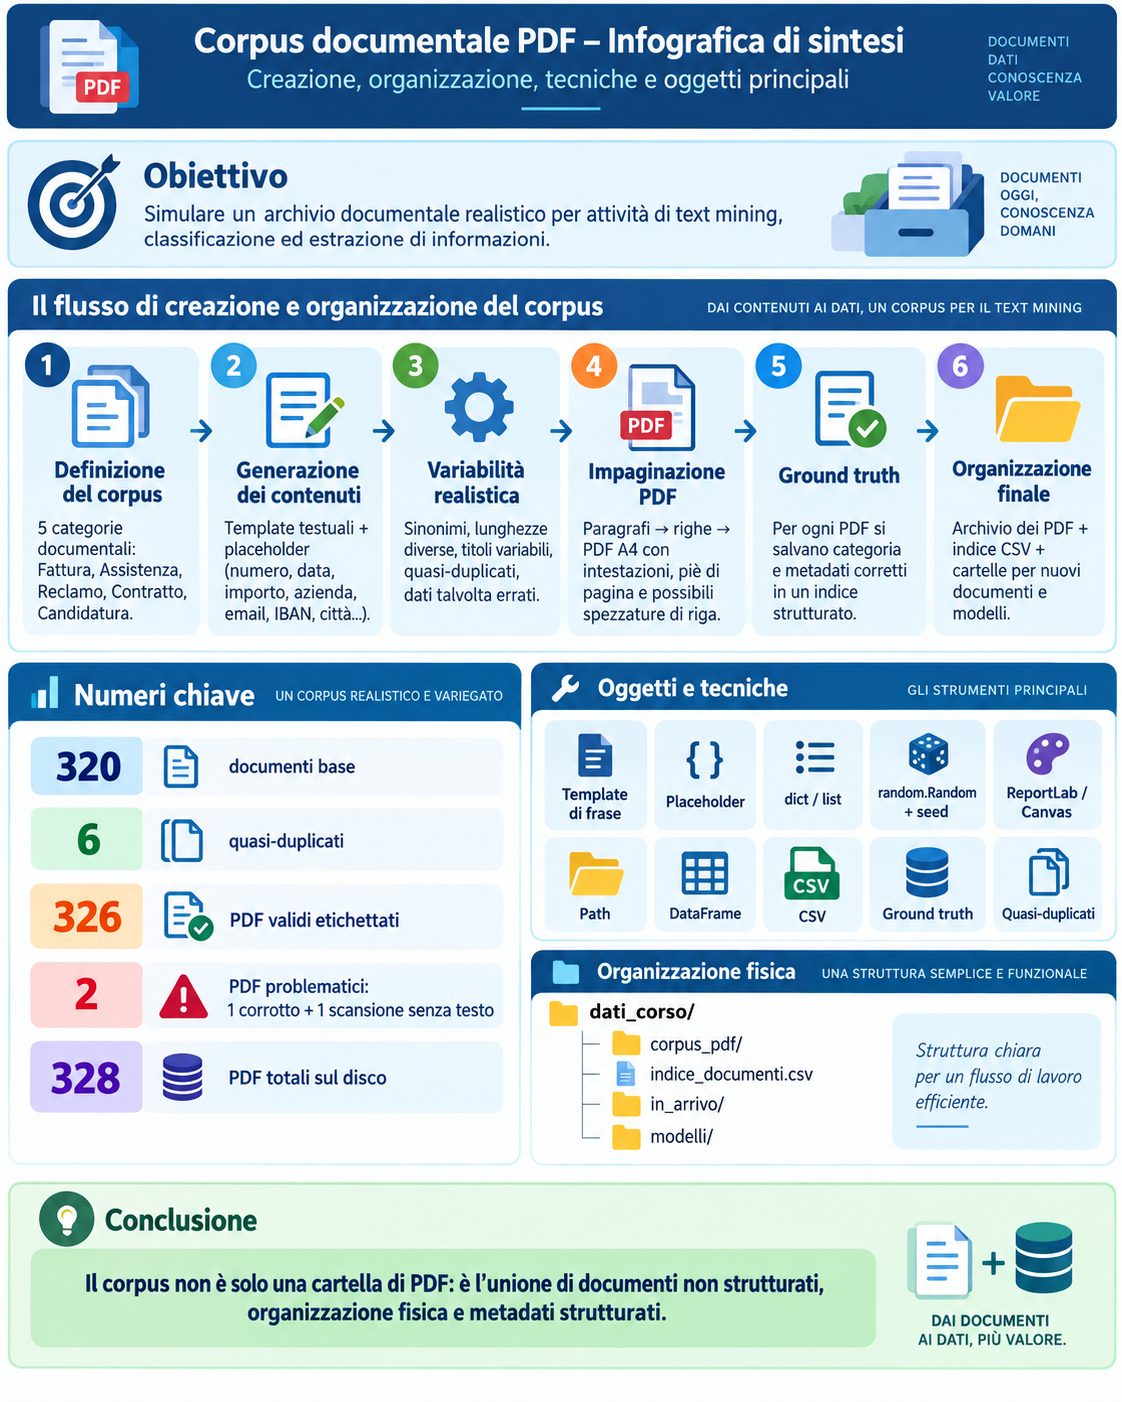

In [27]:
Image('workflow_organizzazione.png')

E' importante, prima di creare o leggere cartelle e file, controllare la cartella corrente, nella quale le cartelle/file saranno create o lette.<br>
A questo scopo c'è il comodo [comando *magic*](https://ipython.readthedocs.io/en/stable/interactive/magics.html) `%pwd`:

In [6]:
%pwd

'c:\\Users\\Utente\\Desktop\\salvataggi\\SALVATAGGIO DATI\\Documents\\Seminari\\Data Science (corsi)\\Repository GitHub corsi\\Corso-Reindal\\Corso-Reindal-AI\\Corso-AI-Rendal-bis\\Text Mining'

---
# 1. Dal PDF al testo

*Tempo indicativo: 25 minuti.*

Il programma parte dalla «pulizia del testo», ma in un'azienda che elabora soprattutto **PDF** c'è un passo che viene ancora prima: il testo bisogna *tirarlo fuori* dal file. Conviene capire subito perché questo passo è meno banale di quanto sembri, dato che molti dei difetti che dovremo ripulire nella sezione 2 nascono proprio qui.

## 1.1 Perché il PDF è un formato ostico

Il PDF è nato per **stampare e visualizzare** una pagina in modo identico ovunque, non per conservare la struttura logica di un testo. Dentro un PDF non troviamo «titoli», «paragrafi» e «frasi», ma istruzioni di disegno del tipo: *«con questo font, disegna questi glifi a partire da queste coordinate della pagina»* (un **glifo** è la forma grafica di un carattere). Chi estrae il testo deve quindi *ricostruirlo* a partire dalla posizione dei glifi, e la ricostruzione è inevitabilmente imperfetta.

Esistono due famiglie di PDF molto diverse:

| Tipo | Come nasce | Come si estrae il testo |
|---|---|---|
| **PDF nativo** (o «digitale») | Esportato da un programma: Word, un gestionale, un sistema di fatturazione… Il testo è presente nel file e si può selezionare con il mouse. | Con una libreria che legge le istruzioni di disegno (`pypdf`, `pdfplumber`, `PyMuPDF`…). È il caso che trattiamo oggi. |
| **PDF scansionato** | Prodotto da uno scanner o da una fotografia: ogni pagina è un'**immagine**, e il testo «non c'è». | Serve l'**OCR** (*Optical Character Recognition*, riconoscimento ottico dei caratteri): un programma che «legge» l'immagine e restituisce i caratteri. È più lento e introduce errori di riconoscimento. |

I <u>difetti tipici</u> del testo estratto da un PDF nativo sono:

1. **A capo a fine riga**: nel PDF un paragrafo è impaginato su più righe. All'estrazione, alla fine di *ogni riga visiva della pagina* compare un carattere di a capo (`\n`), anche se in quel punto la frase non è finita: il testo risulta «spezzato» in punti che non hanno alcun significato.

    **Un esempio di questo difetto.** Sulla pagina leggiamo un paragrafo continuo su tre righe:

    ```text
    Si trasmette in allegato la fattura n. FT-2026-00123 relativa alla fornitura
    del servizio Portale Clienti. Il pagamento dovrà avvenire tramite bonifico
    bancario entro 30 giorni dalla data di emissione.
    ```

    Il testo estratto diventa questa stringa:

    ```text
    ...relativa alla fornitura\ndel servizio Portale Clienti. Il pagamento dovrà avvenire tramite bonifico\nbancario entro 30 giorni...
    ```

    Perché è un difetto:

    - non distinguiamo più un a capo vero, cioè la fine di un paragrafo, da uno dovuto solo alla larghezza della pagina.
    - le espressioni di più parole vengono spezzate: *bonifico bancario* diventa *bonifico\nbancario*, e una ricerca o una regex che si aspetta uno spazio non la trova. Lo stesso capita a una data (*12 marzo\n2026*), a un importo seguito dalla valuta, ai gruppi di un IBAN.
    - gli strumenti che lavorano per frasi, come la NER e gli embeddings, ricevono frasi troncate.
    - il difetto si combina con la sillabazione (il secondo della lista): paga-\nmento.

2. **Sillabazione**: una parola spezzata a fine riga (`comuni-` / `cazione`) viene estratta in due pezzi.
3. **Intestazioni, piè di pagina e numeri di pagina** ripetuti su ogni pagina, che finiscono mescolati al contenuto.
4. **Ordine di lettura sbagliato** quando la pagina ha più colonne, tabelle o riquadri.
5. **Caratteri speciali**: legature tipografiche (il singolo glifo `ﬁ` al posto delle due lettere `f` + `i`), spazi «non separabili», virgolette e apostrofi tipografici.

Nel seguito li incontreremo quasi tutti, perché il corpus di esempio è **costruito apposta per contenerli**.

## 1.2 Fabbrichiamo il corpus di esempio

Come dichiarato nell'assunzione **A4**, non abbiamo documenti reali: ne fabbrichiamo di verosimili. Il meccanismo è semplice:

- per ciascuno dei cinque tipi di documento abbiamo preparato un elenco di **modelli di frase** con dei segnaposto (`{numero}`, `{totale}`, `{prodotto}`…);
- per ogni documento scegliamo a caso alcune frasi, riempiamo i segnaposto con valori di fantasia (nomi, aziende, importi, date, IBAN) e scriviamo il tutto in un file PDF;
- mentre lo facciamo, **prendiamo nota dei valori veri** (tipo di documento, data, numero, importo…) in un file CSV: è la nostra *verità di riferimento*, con cui più avanti potremo misurare quanto sbagliano i nostri programmi.

Per rendere l'esercizio meno artificiale abbiamo introdotto di proposito alcune difficoltà:

- **classi sbilanciate**: le fatture sono più del doppio delle candidature, come accade negli archivi reali;
- **documenti dal tipo poco evidente**: aperture e oggetti generici che non nominano il tipo di documento, documenti brevissimi, frasi «ibride» che parlano il linguaggio di un'altra categoria (un reclamo che cita una fattura), frasi plausibili in due categorie e una piccola quota di documenti dal contenuto **misto**. Sono i casi che metteranno in difficoltà il classificatore, come avviene con i documenti veri;
- **sinonimi**: lo stesso concetto è espresso con parole diverse (*malfunzionamento*, *guasto*, *anomalia*…);
- **difetti da PDF**: intestazione e piè di pagina identici su ogni pagina, parole spezzate a fine riga, alcuni documenti su due pagine;
- **dati «fuori posto»**: in alcuni documenti la data sta in fondo alla lettera anziché in cima, e alcuni oggetti citano il numero di *un altro* documento (un reclamo che contesta una fattura): serviranno nella sezione 6;
- **quasi-duplicati**: alcuni documenti sono copie di altri, con un numero di documento diverso (come accade con solleciti e reinvii);
- **due file problematici**: un PDF corrotto e un PDF senza testo (come una scansione), per verificare che la nostra lettura non si blocchi.

> Le tre celle seguenti **non sono l'argomento del corso**: servono solo **A PRODURRE I DATI**. Le eseguiamo e le leggiamo soltanto se siamo curiosi di vedere come si genera un PDF con `reportlab`.

> 🔧 **Da personalizzare — documenti ed etichette veri.** Con un archivio reale le tre celle seguenti **si saltano** (⚠️ la terza svuota `CARTELLA_PDF`). Al loro posto serve un file di etichette preparato da noi, da caricare nella variabile `indice`, per esempio con `indice = pd.read_csv("etichette.csv")`. Colonne indispensabili: `file` (il nome del PDF) e `categoria`. Le altre colonne (`data_documento`, `numero_documento`, `importo_totale`…) servono solo a **misurare** i risultati: si possono compilare a mano per un campione di 100–200 documenti. Senza di esse, le celle che confrontano con la verità di riferimento (5.5, 6.4, 6.5 e il controllo finale della 7.4) si saltano. Il generatore resta comunque utile: permette di sviluppare e collaudare il codice senza toccare dati riservati.

In [5]:
# ---------------------------------------------------------------------------
# GENERAZIONE DEL CORPUS (1/3): anagrafiche di fantasia e modelli di frase.
# Tutti i nomi, le aziende, gli indirizzi e-mail e gli IBAN sono inventati.
# Il dominio ".example" è riservato proprio agli esempi: non esiste su Internet.
# ---------------------------------------------------------------------------
INTESTAZIONE_FISSA = "Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno"

NOMI_PERSONE = ["Mario Rossi", "Giulia Bianchi", "Luca Ferrari", "Francesca Russo", "Paolo Colombo",
                "Elena Ricci", "Andrea Marino", "Chiara Greco", "Stefano Bruno", "Sara Gallo",
                "Davide Conti", "Marta De Luca"]
AZIENDE = {"Alfa Sistemi S.r.l.": "alfasistemi.example", "Beta Logistica S.p.A.": "betalogistica.example",
           "Gamma Energia S.r.l.": "gammaenergia.example", "Delta Assicurazioni S.p.A.": "deltaassicurazioni.example",
           "Omega Trasporti S.r.l.": "omegatrasporti.example", "Sigma Consulting S.r.l.": "sigmaconsulting.example"}
CITTA = ["Torino", "Milano", "Roma", "Bologna", "Napoli", "Firenze", "Genova", "Verona"]
PRODOTTI = ["Portale Clienti", "Gestionale Ordini", "App Mobile", "Archivio Documentale",
            "Fatturazione Online", "Reportistica Avanzata", "Posta Certificata"]
PROBLEMI = ["un malfunzionamento", "un guasto", "un'anomalia", "un blocco improvviso", "un errore bloccante"]
RUOLI = ["sviluppatore backend", "analista funzionale", "data engineer", "sistemista", "project manager", "tester"]
LAUREE = ["Informatica", "Ingegneria Gestionale", "Matematica", "Economia"]
COMPETENZE = ["Python", "SQL", "C#", "Java", "Docker", "Kubernetes", "Azure", "analisi dei dati",
              "gestione dei progetti", "metodologie agili"]
MESI = ["gennaio", "febbraio", "marzo", "aprile", "maggio", "giugno", "luglio", "agosto",
        "settembre", "ottobre", "novembre", "dicembre"]

# Quanti documenti per categoria: volutamente SBILANCIATI, come negli archivi reali.
DOCUMENTI_PER_CATEGORIA = {"fattura": 90, "assistenza": 80, "reclamo": 60, "contratto": 50, "candidatura": 40}
N_QUASI_DUPLICATI = 6

# Per ogni categoria: "apertura" = frase iniziale (contiene sempre il numero del documento);
# "sempre" = gruppi di varianti di cui UNA è sempre presente; "corpo" = frasi scelte a caso.
MODELLI_FRASE = {
    "fattura": {
        "titoli": ["Fattura n. {numero}", "Invio fattura", "Sollecito di pagamento"],
        "apertura": [
            "Si trasmette in allegato la fattura n. {numero} relativa alla fornitura del servizio {prodotto}.",
            "Con la presente inviamo la fattura n. {numero} per le attività svolte sul servizio {prodotto}.",
            "Fattura n. {numero} emessa per il canone periodico del servizio {prodotto}.",
        ],
        "sempre": [[
            "Totale da pagare: € {totale}.",
            "Totale fattura: {totale} euro.",
            "Importo totale dovuto: EUR {totale}.",
        ]],
        "corpo": [
            "L'imponibile ammonta a {imponibile} euro, a cui si aggiunge l'IVA al 22% pari a {iva} euro.",
            "Il pagamento dovrà avvenire tramite bonifico bancario entro {giorni} giorni dalla data di emissione.",
            "Coordinate bancarie per il bonifico: IBAN {iban}.",
            "Si sollecita il saldo della fattura, scaduta il {data_scadenza} e non ancora pagata.",
            "La fattura è emessa in formato elettronico e trasmessa tramite il Sistema di Interscambio.",
            "Partita IVA del cedente: {piva}.",
            "In caso di ritardato pagamento saranno applicati gli interessi di mora previsti dalla legge.",
            "Si prega di indicare nella causale del bonifico il numero della fattura.",
            "La scadenza del pagamento è fissata al {data_scadenza}.",
            "L'importo comprende le attività di manutenzione ordinaria svolte nel periodo di riferimento.",
        ],
    },
    "contratto": {
        "titoli": ["Contratto n. {numero}", "Proposta di rinnovo contrattuale", "Condizioni di fornitura"],
        "apertura": [
            "Il presente contratto n. {numero} è stipulato tra {azienda} e il fornitore per l'erogazione del servizio {prodotto}.",
            "Contratto di servizio n. {numero}: le parti concordano le condizioni di fornitura del servizio {prodotto}.",
            "Si invia per la firma il contratto n. {numero} relativo al servizio {prodotto}.",
        ],
        "corpo": [
            "Il contratto ha durata di {mesi} mesi e si rinnova tacitamente salvo disdetta.",
            "Ciascuna parte può esercitare il diritto di recesso con un preavviso scritto di {giorni} giorni.",
            "Il canone annuo concordato è pari a {importo} euro, oltre IVA.",
            "Le parti si impegnano a mantenere la riservatezza sulle informazioni scambiate durante l'esecuzione del contratto.",
            "Per ogni controversia sarà competente in via esclusiva il foro di {citta}.",
            "Il fornitore garantisce i livelli di servizio descritti nell'allegato tecnico.",
            "Eventuali modifiche alle clausole dovranno essere concordate per iscritto tra le parti.",
            "Il trattamento dei dati personali avviene nel rispetto della normativa vigente.",
            "La proposta di rinnovo dovrà essere firmata dal legale rappresentante di {azienda}.",
            "In caso di inadempimento, la parte lesa potrà risolvere il contratto ai sensi di legge.",
        ],
    },
    "assistenza": {
        "titoli": ["Ticket {numero}", "Richiesta di assistenza tecnica", "Intervento previsto dal contratto n. {numero_contratto}"],
        "apertura": [
            "Ticket {numero}: l'utente segnala {un_problema} del servizio {prodotto} dopo l'ultimo aggiornamento.",
            "Segnalazione {numero}: da questa mattina si verifica {un_problema} sul servizio {prodotto}.",
            "Richiesta di assistenza {numero} a causa di {un_problema} che riguarda il servizio {prodotto}.",
        ],
        "corpo": [
            "All'accesso il sistema restituisce un messaggio di errore e la sessione viene chiusa.",
            "Il problema si presenta in modo intermittente dalle ore {ora} di questa mattina.",
            "Abbiamo già provato a riavviare il server e a svuotare la cache del browser, senza risultato.",
            "Si richiede l'intervento di un tecnico per ripristinare il servizio.",
            "L'applicazione risulta molto lenta e in alcuni casi non risponde ai comandi.",
            "Non è possibile effettuare il login: la password viene rifiutata anche dopo il reset.",
            "A causa di {un_problema} gli operatori non riescono a caricare i documenti sulla piattaforma.",
            "Dopo il riavvio si è ripresentato {un_problema} sullo stesso modulo.",
            "Priorità della segnalazione: {priorita}.",
            "In allegato inviamo la schermata con il codice di errore visualizzato.",
            "Il tecnico ha installato una correzione e ha chiesto di verificare se il problema è risolto.",
        ],
    },
    "reclamo": {
        "titoli": ["Reclamo n. {numero}", "Reclamo formale", "Contestazione della fattura n. {numero2}"],
        "apertura": [
            "Con la presente intendo presentare formale reclamo (pratica n. {numero}) per il disservizio subito con il servizio {prodotto}.",
            "Reclamo n. {numero}: segnalo la mia totale insoddisfazione per il servizio {prodotto}.",
            "Scrivo per contestare quanto accaduto con il servizio {prodotto} (pratica di reclamo n. {numero}).",
        ],
        "corpo": [
            "La consegna è avvenuta con {giorni} giorni di ritardo rispetto a quanto promesso.",
            "Sono molto insoddisfatto del servizio ricevuto e del modo in cui è stata gestita la mia richiesta.",
            "Chiedo il rimborso di {importo} euro per l'importo addebitato ingiustamente.",
            "Nonostante i numerosi solleciti, nessuno mi ha ricontattato.",
            "In mancanza di una risposta entro {giorni} giorni mi rivolgerò a un'associazione dei consumatori.",
            "Il prodotto ricevuto è risultato danneggiato e non conforme a quanto ordinato.",
            "Ritengo inaccettabile il comportamento dell'operatore del servizio clienti.",
            "Chiedo un risarcimento per il danno subito a causa del disservizio.",
            "Mi è stata addebitata due volte la stessa somma e pretendo la restituzione immediata.",
            "Mi aspetto delle scuse formali e un indennizzo adeguato.",
        ],
    },
    "candidatura": {
        "titoli": ["Candidatura rif. {numero}", "Invio curriculum vitae", "Candidatura spontanea"],
        "apertura": [
            "Con la presente desidero candidarmi per la posizione di {ruolo} (rif. annuncio {numero}) presso la vostra sede di {citta}.",
            "In risposta all'annuncio {numero}, propongo la mia candidatura per il ruolo di {ruolo}.",
            "Invio la mia candidatura spontanea (rif. {numero}) per una posizione di {ruolo} nella sede di {citta}.",
        ],
        "corpo": [
            "In allegato invio il mio curriculum vitae aggiornato.",
            "Ho maturato {anni} anni di esperienza come {ruolo} in aziende del settore.",
            "Ho conseguito la laurea in {laurea} presso l'Università di {citta}.",
            "Tra le mie competenze principali: {competenze}.",
            "Sono disponibile per un colloquio conoscitivo anche in videochiamata.",
            "Sono fortemente motivato a crescere professionalmente in un contesto innovativo.",
            "Parlo correntemente inglese e ho una buona conoscenza del francese.",
            "Resto in attesa di un vostro riscontro e ringrazio per l'attenzione.",
            "Nel mio ultimo incarico ho coordinato un gruppo di lavoro di cinque persone.",
            "Autorizzo il trattamento dei miei dati personali ai fini della selezione.",
        ],
    },
}

# Frasi "ibride": parlano il linguaggio di UN'ALTRA categoria e rendono il problema meno banale.
FRASI_IBRIDE = {
    "fattura": ["La fattura si riferisce al canone previsto dal contratto di servizio in vigore.",
                "Per contestazioni sull'importo è possibile presentare un reclamo entro dieci giorni."],
    "contratto": ["Il pagamento del canone avverrà tramite bonifico a trenta giorni dalla data della fattura.",
                  "Il contratto include il servizio di assistenza tecnica con intervento entro quattro ore."],
    "assistenza": ["Ricordiamo che il contratto di manutenzione prevede un intervento entro quattro ore lavorative.",
                   "Il cliente è insoddisfatto e minaccia di presentare un reclamo formale per il disservizio."],
    "reclamo": ["Il reclamo riguarda la fattura n. {numero2}, il cui pagamento è già stato effettuato tramite bonifico.",
                "Ho aperto più volte un ticket di assistenza per il malfunzionamento, senza ottenere una soluzione."],
    "candidatura": ["Sono interessato a un contratto a tempo indeterminato, ma valuto anche altre proposte.",
                    "Ho lavorato nell'assistenza tecnica ai clienti, gestendo ticket e segnalazioni di errore."],
}

# Aperture NEUTRE: citano il numero del documento ma non dicono di che tipo di documento si tratta.
# Negli archivi reali capita spesso: la lettera di accompagnamento è generica e il contenuto sta nel seguito.
APERTURE_NEUTRE = [
    "In riferimento alla pratica n. {numero} relativa al servizio {prodotto}, si comunica quanto segue.",
    "Facciamo seguito ai precedenti contatti sul servizio {prodotto} (rif. {numero}).",
    "Si trasmette la documentazione rif. {numero} riguardante il servizio {prodotto}.",
]

# Frasi CONDIVISE: sono plausibili in DUE categorie, quindi da sole non bastano a decidere.
# Sono la fonte principale degli errori del classificatore, come accade con i documenti veri.
FRASI_CONDIVISE = {
    ("reclamo", "assistenza"): [
        "Il servizio non funziona correttamente da diversi giorni e il problema non è ancora stato risolto.",
        "Ho già segnalato più volte il problema senza ricevere una risposta risolutiva.",
        "Chiedo che un tecnico intervenga al più presto per ripristinare il servizio.",
    ],
    ("fattura", "contratto"): [
        "Il canone del servizio è dovuto in rate trimestrali anticipate, con pagamento tramite bonifico.",
        "Gli importi indicati si intendono al netto dell'IVA e sono soggetti ad adeguamento annuale.",
        "Il pagamento del canone dovrà avvenire entro {giorni} giorni dal ricevimento del documento.",
    ],
    ("fattura", "reclamo"): [
        "L'importo addebitato non corrisponde a quanto concordato e se ne chiede la verifica.",
        "Si resta in attesa della nota di credito a storno dell'importo non dovuto.",
    ],
    ("contratto", "candidatura"): [
        "Si allega la documentazione richiesta, firmata e completa dei dati anagrafici.",
        "Resto disponibile a discutere le condizioni economiche e la data di decorrenza.",
    ],
}


def frasi_condivise_per(categoria):
    """Tutte le frasi condivise in cui compare la categoria, con la categoria 'vicina' corrispondente."""
    risultato = []
    for coppia, elenco in FRASI_CONDIVISE.items():
        if categoria in coppia:
            vicina = coppia[0] if coppia[1] == categoria else coppia[1]
            risultato += [(frase, vicina) for frase in elenco]
    return risultato


# Frasi neutre e formule di chiusura: possono comparire in qualsiasi documento e non aiutano a distinguerli.
FRASI_NEUTRE = [
    "Restiamo a disposizione per qualsiasi chiarimento.",
    "Per ulteriori informazioni è possibile scrivere a {email}.",
    "Si prega di fare riferimento alla presente comunicazione in ogni futura corrispondenza.",
    "La documentazione completa è disponibile su richiesta.",
]
FORMULE_DI_CHIUSURA = [
    "Cordiali saluti.",
    "Distinti saluti.",
    "In attesa di un cortese riscontro, porgiamo i nostri migliori saluti.",
    "Ringraziando per l'attenzione, inviamo i nostri più cordiali saluti.",
]
TITOLI_GENERICI = ["Comunicazione", "Vostra richiesta", "Documentazione allegata", "Comunicazione del {data}"]

print("Categorie:", ", ".join(f"{c} ({n})" for c, n in DOCUMENTI_PER_CATEGORIA.items()))

Categorie: fattura (90), assistenza (80), reclamo (60), contratto (50), candidatura (40)


In [6]:
# ---------------------------------------------------------------------------
# GENERAZIONE DEL CORPUS (2/3): funzioni di supporto.
# ---------------------------------------------------------------------------
import textwrap

from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas


def formatta_importo(valore):
    """1234.5 -> '1.234,50' (notazione italiana: punto per le migliaia, virgola per i decimali)."""
    testo = f"{valore:,.2f}"                                   # '1,234.50' (notazione anglosassone)
    return testo.replace(",", "#").replace(".", ",").replace("#", ".")


def formatta_data(giorno, stile):
    """Scrive una data in stile 'numerico' (12/03/2026) oppure 'esteso' (12 marzo 2026)."""
    if stile == "numerico":
        return giorno.strftime("%d/%m/%Y")
    return f"{giorno.day} {MESI[giorno.month - 1]} {giorno.year}"


def genera_iban(rng):
    """Genera un IBAN italiano di fantasia ma FORMALMENTE valido.

    Struttura: 'IT' + 2 cifre di controllo + CIN (1 lettera) + ABI (5 cifre) + CAB (5 cifre)
    + numero di conto (12 caratteri). Le due cifre di controllo si calcolano con la regola
    internazionale 'modulo 97', la stessa che useremo nella sezione 6 per VALIDARE gli IBAN estratti.
    """
    bban = (rng.choice("ABCDEFGHIJKLMNOPQRSTUVWXYZ") + f"{rng.randrange(10**5):05d}"
            + f"{rng.randrange(10**5):05d}" + f"{rng.randrange(10**12):012d}")
    # Si sposta il prefisso 'IT00' in fondo e si convertono le lettere in numeri (A=10 ... Z=35):
    # int(c, 36) fa esattamente questa conversione sia per le cifre sia per le lettere.
    numerico = "".join(str(int(c, 36)) for c in bban + "IT00")
    controllo = 98 - int(numerico) % 97
    return f"IT{controllo:02d}{bban}"


def raggruppa_a_quattro(codice):
    """'IT60X0542811101000000123456' -> 'IT60 X054 2811 ...' (come viene stampato di solito)."""
    return " ".join(codice[i:i + 4] for i in range(0, len(codice), 4))


VOCALI = "aeiouàèéìòù"


def spezza_parola(parola):
    """Trova un punto plausibile in cui spezzare una parola lunga, imitando la sillabazione italiana:
    'paga-mento' (prima di una consonante), 'contrat-to' (tra due consonanti uguali), 'documen-tale'."""
    for i in range(len(parola) // 2, len(parola) - 3):
        prima, qui, dopo = parola[i - 1].lower(), parola[i].lower(), parola[i + 1].lower()
        if prima in VOCALI and qui not in VOCALI:
            if dopo not in VOCALI and (qui == dopo or qui in "lmnr"):
                return parola[:i + 1], parola[i + 1:]
            return parola[:i], parola[i:]
    return None


def manda_a_capo(paragrafo, rng, larghezza=78, prob_sillabazione=0.35):
    """Divide un paragrafo in righe e, ogni tanto, spezza una parola a fine riga con il trattino,
    come fanno i programmi di impaginazione. È il difetto che dovremo riparare nella sezione 2."""
    righe = textwrap.wrap(paragrafo, width=larghezza, break_long_words=False, break_on_hyphens=False)
    for i in range(len(righe) - 1):
        prima_parola, _, resto = righe[i + 1].partition(" ")
        if prima_parola.isalpha() and len(prima_parola) >= 9 and rng.random() < prob_sillabazione:
            parti = spezza_parola(prima_parola)
            if parti:
                righe[i] += " " + parti[0] + "-"
                righe[i + 1] = parti[1] + (" " + resto if resto else "")
    return righe


def scrivi_pdf(percorso, righe, righe_per_pagina=20):
    """Scrive le righe di testo in un PDF A4, con intestazione e piè di pagina fissi su ogni pagina."""
    foglio = canvas.Canvas(str(percorso), pagesize=A4)
    _, altezza = A4
    pagine = [righe[i:i + righe_per_pagina] for i in range(0, len(righe), righe_per_pagina)] or [[]]
    for numero_pagina, righe_pagina in enumerate(pagine, start=1):
        foglio.setFont("Helvetica", 8)
        foglio.drawString(50, altezza - 40, INTESTAZIONE_FISSA)
        foglio.setFont("Helvetica", 11)
        y = altezza - 80
        for riga in righe_pagina:
            foglio.drawString(50, y, riga)
            y -= 16
        foglio.setFont("Helvetica", 8)
        foglio.drawString(50, 40, f"Pagina {numero_pagina} di {len(pagine)} - Documento riservato")
        foglio.showPage()                                   # chiude la pagina corrente
    foglio.save()


def componi_documento(categoria, rng):
    """Crea UN documento di fantasia. Restituisce un dizionario con:
    - 'paragrafi': il testo (una stringa per paragrafo), prima dell'impaginazione;
    - tutti i valori 'veri' che ci serviranno come verità di riferimento."""
    anno = rng.choice([2025, 2026])
    giorno = date(anno, 1, 1) + timedelta(days=rng.randrange(0, 365 if anno == 2025 else 240))
    persona = rng.choice(NOMI_PERSONE)
    azienda, dominio = rng.choice(list(AZIENDE.items()))
    email = persona.lower().replace(" ", ".") + "@" + dominio
    progressivo = rng.randrange(1, 99999)
    numero = {"fattura": f"FT-{anno}-{progressivo:05d}", "contratto": f"CTR-{anno}-{progressivo % 10000:04d}",
              "assistenza": f"TCK-{progressivo + 100000:06d}", "reclamo": f"REC-{anno}-{progressivo % 10000:04d}",
              "candidatura": f"HR-{anno}-{progressivo % 1000:03d}"}[categoria]
    imponibile = round(rng.uniform(150, 9000), 2)
    iva = round(imponibile * 0.22, 2)
    totale = round(imponibile + iva, 2)
    iban = genera_iban(rng)
    iban_valido = True
    if rng.random() < 0.15:
        # Ogni tanto "sbagliamo" una cifra: simula un errore di battitura.
        # Ci servirà per mostrare che un controllo di validità scova i dati sbagliati.
        posizione = rng.randrange(10, len(iban))
        iban = iban[:posizione] + str((int(iban[posizione]) + 1) % 10) + iban[posizione + 1:]
        iban_valido = False
    stile_data = rng.choice(["numerico", "esteso"])
    data_testo = formatta_data(giorno, stile_data)
    valori = dict(
        numero=numero, numero2=f"FT-{anno}-{rng.randrange(1, 99999):05d}",
        numero_contratto=f"CTR-{anno}-{rng.randrange(1, 9999):04d}", prodotto=rng.choice(PRODOTTI),
        azienda=azienda, citta=rng.choice(CITTA), email=email, data=data_testo,
        giorni=rng.choice([10, 15, 30, 60, 90]), mesi=rng.choice([12, 24, 36]),
        imponibile=formatta_importo(imponibile), iva=formatta_importo(iva), totale=formatta_importo(totale),
        importo=formatta_importo(round(rng.uniform(40, 3000), 2)), iban=raggruppa_a_quattro(iban),
        piva=f"{rng.randrange(10**10, 10**11)}", un_problema=rng.choice(PROBLEMI),
        data_scadenza=formatta_data(giorno + timedelta(days=30), "numerico"),
        ora=f"{rng.randrange(7, 12)}:{rng.choice(['00', '15', '30', '45'])}",
        priorita=rng.choice(["alta", "media", "bassa"]), ruolo=rng.choice(RUOLI), anni=rng.randrange(2, 16),
        laurea=rng.choice(LAUREE), competenze=", ".join(rng.sample(COMPETENZE, 3)),
    )
    modelli = MODELLI_FRASE[categoria]
    # --- corpo del documento -----------------------------------------------------------------------
    # Tre "taglie": breve (pochissimo testo su cui decidere), normale, lungo (va su due pagine).
    sorte = rng.random()
    if sorte < 0.20:
        n_frasi = 1
    elif sorte < 0.32:
        n_frasi = rng.randrange(8, 11)
    else:
        n_frasi = rng.randrange(2, 6)
    condivise = frasi_condivise_per(categoria)
    frasi = [rng.choice(gruppo) for gruppo in modelli.get("sempre", [])]
    if n_frasi == 1 and condivise and rng.random() < 0.4:
        # documento breve la cui unica frase è AMBIGUA: resta da decidere solo su apertura e titolo
        frasi.append(rng.choice(condivise)[0])
    else:
        frasi += rng.sample(modelli["corpo"], k=min(n_frasi, len(modelli["corpo"])))
    # frasi "ibride" (lessico di un'altra categoria): nessuna, una oppure due
    n_ibride = rng.choices([0, 1, 2], weights=[0.55, 0.33, 0.12])[0]
    frasi += rng.sample(FRASI_IBRIDE[categoria], k=min(n_ibride, len(FRASI_IBRIDE[categoria])))
    # frasi "condivise" (plausibili in due categorie)
    if condivise and rng.random() < 0.45:
        frasi += [f for f, _ in rng.sample(condivise, k=min(rng.randrange(1, 3), len(condivise)))]
    # documenti MISTI (circa 1 su 8): l'etichetta resta quella prevalente, ma quasi metà del testo
    # appartiene alla categoria vicina. Sono i casi su cui anche due persone discuterebbero.
    if condivise and rng.random() < 0.12:
        vicina = rng.choice(sorted({v for _, v in condivise}))
        quante = max(1, len(frasi) - 1)
        frasi += rng.sample(MODELLI_FRASE[vicina]["corpo"], k=min(quante, len(MODELLI_FRASE[vicina]["corpo"])))
    rng.shuffle(frasi)
    # apertura: esplicita sul tipo di documento, oppure (una volta su tre) neutra
    apertura = rng.choice(APERTURE_NEUTRE if rng.random() < 0.35 else modelli["apertura"])
    frasi = ([apertura] + frasi
             + rng.sample(FRASI_NEUTRE, k=rng.randrange(0, 2)) + [rng.choice(FORMULE_DI_CHIUSURA)])
    frasi = [f.format(**valori) for f in frasi]
    # --- titolo: esplicito sul tipo di documento una volta su tre, altrimenti generico ---------------
    titolo = rng.choice(modelli["titoli"] if rng.random() < 0.33 else TITOLI_GENERICI).format(**valori)
    # --- riga con la data: di solito in cima; in circa un documento su sei in FONDO ("Luogo, data"),
    #     come nelle lettere firmate. Metterà in difficoltà l'idea ingenua "la prima data è quella giusta".
    data_in_fondo = rng.random() < 0.17
    if data_in_fondo or stile_data == "esteso":
        riga_data = f"{rng.choice(CITTA)}, {data_testo}"
    else:
        riga_data = f"Data: {data_testo}"
    paragrafi = [f"Mittente: {persona} - {azienda} - {email}", f"Oggetto: {titolo}", ""]
    if not data_in_fondo:
        paragrafi.insert(0, riga_data)
    for i in range(0, len(frasi), 3):                        # raggruppiamo le frasi in paragrafi da tre
        paragrafi += [" ".join(frasi[i:i + 3]), ""]
    if data_in_fondo:
        paragrafi.append(riga_data)
    testo_completo = " ".join(paragrafi)
    return {
        "paragrafi": paragrafi, "categoria": categoria, "data_documento": giorno.isoformat(),
        "numero_documento": numero,
        "importo_totale": totale if categoria == "fattura" else None,
        "email": email,
        # l'IBAN è "vero" solo se la frase che lo contiene è stata effettivamente scelta
        "iban": iban if valori["iban"] in testo_completo else None,
        "iban_valido": iban_valido if valori["iban"] in testo_completo else None,
    }


print("Funzioni di generazione definite. Esempio di IBAN di fantasia:", raggruppa_a_quattro(genera_iban(random.Random(1))))

Funzioni di generazione definite. Esempio di IBAN di fantasia: IT92 E746 0608 2711 2994 4532 028


In [7]:
# ---------------------------------------------------------------------------
# GENERAZIONE DEL CORPUS (3/3): scrittura dei PDF e dell'indice con la verità di riferimento (ground truth nell'indice).
# Se i file esistono già (per esempio alla seconda esecuzione del notebook) non li rigeneriamo:
# grazie al seme fisso, il contenuto sarebbe comunque identico.
# ---------------------------------------------------------------------------
FILE_INDICE = CARTELLA_DATI / "indice_documenti.csv"
RIGENERA_CORPUS = False          # mettiamo True per forzare la rigenerazione


def genera_corpus(cartella, quanti_per_categoria, n_quasi_duplicati, seme):
    """Scrive i PDF nella cartella e restituisce l'indice (una riga per documento) come DataFrame."""
    rng = random.Random(seme)                        # generatore casuale LOCALE e riproducibile
    documenti = [componi_documento(categoria, rng)
                 for categoria, quanti in quanti_per_categoria.items() for _ in range(quanti)]
    # Quasi-duplicati: stessa lettera, ma con un numero di documento diverso (capita con i solleciti e i reinvii).
    for originale in rng.sample(documenti, k=n_quasi_duplicati):
        copia = dict(originale)
        nuovo_numero = originale["numero_documento"][:-2] + f"{rng.randrange(100):02d}"
        copia["paragrafi"] = [p.replace(originale["numero_documento"], nuovo_numero) for p in originale["paragrafi"]]
        copia["numero_documento"] = nuovo_numero
        copia["duplicato_di"] = id(originale)
        documenti.append(copia)
    rng.shuffle(documenti)                           # mescoliamo: nella cartella i tipi sono alla rinfusa
    nomi_file = {id(d): f"doc_{i:04d}.pdf" for i, d in enumerate(documenti, start=1)}
    righe_indice = []
    for documento in documenti:
        nome = nomi_file[id(documento)]
        righe = []
        for paragrafo in documento["paragrafi"]:
            righe += manda_a_capo(paragrafo, rng) if paragrafo else [""]
        while righe and not righe[-1]:               # niente righe vuote in coda (creerebbero pagine vuote)
            righe.pop()
        scrivi_pdf(cartella / nome, righe)
        riga = {k: v for k, v in documento.items() if k not in ("paragrafi", "duplicato_di")}
        riga["file"] = nome
        riga["quasi_duplicato_di"] = nomi_file.get(documento.get("duplicato_di"))
        righe_indice.append(riga)
    colonne = ["file", "categoria", "data_documento", "numero_documento", "importo_totale",
               "email", "iban", "iban_valido", "quasi_duplicato_di"]
    return pd.DataFrame(righe_indice)[colonne].sort_values("file").reset_index(drop=True)


def crea_file_problematici(cartella):
    """Due 'trappole' realistiche: un PDF corrotto e un PDF senza testo (come una scansione)."""
    (cartella / "zz_corrotto.pdf").write_bytes(b"%PDF-1.4\nquesto file e' stato troncato durante il trasferimento")
    foglio = canvas.Canvas(str(cartella / "zz_scansione.pdf"), pagesize=A4)
    foglio.rect(60, 500, 470, 250)                   # solo un rettangolo: nessun carattere di testo
    foglio.save()


def svuota_cartella_pdf(cartella):
    """Elimina i PDF di una cartella. Su Windows un file aperto in un visualizzatore non si può cancellare:
    in quel caso ci fermiamo con un messaggio chiaro invece di un errore oscuro."""
    for vecchio in cartella.glob("*.pdf"):
        try:
            vecchio.unlink()
        except PermissionError:
            raise RuntimeError(f"Impossibile eliminare {vecchio.name}: probabilmente è aperto in un visualizzatore PDF. "
                               "Chiudiamolo e rieseguiamo la cella.") from None


n_attesi = sum(DOCUMENTI_PER_CATEGORIA.values()) + N_QUASI_DUPLICATI + 2
if RIGENERA_CORPUS or not FILE_INDICE.exists() or len(list(CARTELLA_PDF.glob("*.pdf"))) != n_attesi:
    svuota_cartella_pdf(CARTELLA_PDF)
    inizio = time.perf_counter()
    indice = genera_corpus(CARTELLA_PDF, DOCUMENTI_PER_CATEGORIA, N_QUASI_DUPLICATI, SEME)
    crea_file_problematici(CARTELLA_PDF)
    indice.to_csv(FILE_INDICE, index=False)
    print(f"Generati {len(indice)} PDF etichettati + 2 file problematici in {time.perf_counter() - inizio:.1f} s")
else:
    print("Corpus già presente su disco: non lo rigeneriamo.")

# Da qui in poi leggiamo SEMPRE l'indice dal CSV, come faremmo con etichette fornite da qualcun altro.
indice = pd.read_csv(FILE_INDICE)
print(f"\nDocumenti nell'indice: {len(indice)}")
print(indice["categoria"].value_counts().to_string())

Generati 326 PDF etichettati + 2 file problematici in 0.7 s

Documenti nell'indice: 326
categoria
fattura        92
assistenza     81
reclamo        61
contratto      51
candidatura    41


In [9]:
indice.head(20)

,file,categoria,data_documento,numero_documento,importo_totale,email,iban,iban_valido,quasi_duplicato_di
0,doc_0001.pdf,fattura,2026-01-05,FT-2026-88347,4831.90,stefano.bruno@sigmaconsulting.example,IT41F1402612624165460975402,True,NaN
1,doc_0002.pdf,fattura,2026-05-28,FT-2026-52184,8127.24,elena.ricci@sigmaconsulting.example,IT88V1560898017490613131976,True,NaN
2,doc_0003.pdf,candidatura,2025-11-10,HR-2025-405,NaN,stefano.bruno@deltaassicurazioni.example,NaN,NaN,NaN
3,doc_0004.pdf,assistenza,2026-06-14,TCK-112617,NaN,elena.ricci@alfasistemi.example,NaN,NaN,NaN
4,doc_0005.pdf,assistenza,2025-02-16,TCK-158904,NaN,giulia.bianchi@sigmaconsulting.example,NaN,NaN,NaN
5,doc_0006.pdf,candidatura,2025-02-26,HR-2025-606,NaN,paolo.colombo@sigmaconsulting.example,NaN,NaN,NaN
6,doc_0007.pdf,assistenza,2026-05-12,TCK-140789,NaN,davide.conti@gammaenergia.example,NaN,NaN,NaN
7,doc_0008.pdf,reclamo,2026-05-03,REC-2026-2811,NaN,paolo.colombo@betalogistica.example,NaN,NaN,NaN
8,doc_0009.pdf,contratto,2025-05-11,CTR-2025-1946,NaN,elena.ricci@deltaassicurazioni.example,NaN,NaN,NaN
9,doc_0010.pdf,fattura,2025-01-31,FT-2025-62461,9241.38,francesca.russo@gammaenergia.example,IT73D5896397595284905180422,True,NaN


Di particolare interesse, nella penultima cella di codice, è la definizione della funzione `crea_file_problematici`.

Questa funziona crea **due file difettosi** <u>messi apposta nella cartella</u>. Servono a dimostrare che la lettura in blocco non si ferma davanti a un file problematico.

**`zz_corrotto.pdf`: un PDF rovinato.** Non è un vero PDF. È **un file di poche decine di byte che inizia con la "firma" dei PDF (`%PDF-1.4`)**. Subito dopo contiene solo una frase di testo («questo file e' stato troncato durante il trasferimento»). **Simula un file arrivato a metà**. `pypdf` riconosce l'intestazione e cerca la struttura interna del documento. Non la trova e solleva l'eccezione `PdfStreamError: Stream has ended unexpectedly`, cioè «il flusso di dati è finito prima del previsto». La funzione `estrai_cartella` cattura l'eccezione e registra `stato = "errore"`, con tipo e messaggio nella colonna `dettaglio`. Poi passa al file successivo.

**`zz_scansione.pdf`: un PDF senza testo.** È un PDF valido di una pagina, su cui è disegnato solo un rettangolo: **nessun carattere**. **Simula una scansione, in cui la pagina è un'immagine**. `pypdf` lo apre senza errori, ma `extract_text()` restituisce una stringa vuota. Il testo è sotto la soglia dei 30 caratteri per pagina, quindi la funzione lo marca come `senza_testo` e lo indica come candidato per l'OCR.



**Due dettagli:**
- Il prefisso `zz_` serve solo a farli finire in fondo all'elenco. Per questo occupano le righe 326 e 327 e si notano subito.
- Non hanno una riga nell'indice delle etichette, quindi la `merge` della cella successiva li esclude. Il corpus di lavoro resta di 326 documenti. Gli stessi due file vengono creati anche in `in_arrivo` (sezione 7.3), dove la pipeline li mette tra quelli da rivedere.

📌 **Che cosa non abbiamo simulato.** In un archivio reale capitano altri casi:
- PDF protetti da password.
- File da zero byte.
- File con estensione `.pdf` che in realtà sono altro.
- Il caso più insidioso: PDF il cui testo si estrae come sequenza di caratteri senza senso, per un difetto nella codifica dei font. Per il nostro codice quel file risulta `ok`, perché di testo ce n'è. Per intercettarlo serve un controllo in più, per esempio la quota di parole riconoscibili sul totale.

Oltre a questi due file, nel corpus ci sono **altri difetti messi apposta**:
- intestazioni e piè di pagina ripetuti, e parole spezzate a fine riga (sezione 2);
- i documenti brevi, generici o misti che mettono in difficoltà il classificatore (sezione 4);
- i 6 quasi-duplicati (sezione 5.5);
- gli IBAN con una cifra sbagliata, le date in fondo alla lettera e gli oggetti che citano il numero di un altro documento (sezione 6).

Apriamo con il sistema operativo un paio di file dalla cartella `dati_corso/corpus_pdf` per vedere che aspetto hanno: intestazione aziendale in alto, poche righe di testo, piè di pagina con il numero di pagina. L'**indice** (`indice_documenti.csv`) contiene, per ogni file, la categoria e i valori veri dei campi: in un caso reale queste informazioni arriverebbero da un sistema documentale o da un lavoro di etichettatura manuale.

## 1.3 Estraiamo il testo da un PDF con `pypdf`

`pypdf` espone un oggetto `PdfReader` che rappresenta il file; la sua proprietà `pages` è l'elenco delle pagine e ogni pagina ha un metodo `extract_text()` che tenta di ricostruire il testo a partire dalla posizione dei glifi.

> 🔧 **Da personalizzare — la funzione di estrazione.** `estrai_testo_pdf` è quasi generica. Con PDF reali dobbiamo:<br>
> (1)<br>
> valutare i file **protetti da password**, che `pypdf` segnala con `lettore.is_encrypted`;<br>
> (2)<br>
> restituire **una lista di pagine** invece di un'unica stringa: con documenti lunghi serve per sapere a che pagina si trova un dato e per dividere il testo in blocchi (sezione 3.9);<br>
> (3)<br>
> il ciclo che cerca `file_esempio` (vedi la cella di codice sottostante)<br>
>
> *questo ciclo serve solo a scegliere in automatico un buon documento da mostrare in aula, cioè uno che contenga tutti i difetti di cui parla la sezione 1.1. È come sfogliare un raccoglitore finché troviamo una lettera di due pagine con una parola andata a capo col trattino. La tiriamo fuori per mostrarla e smettiamo di sfogliare.*<br>
>
> è solo didattico: sceglie un documento «istruttivo» da mostrare. Con <u>documenti veri</u> va **sostituito** con una scelta a mano (`file_esempio = "nome_di_un_documento.pdf"`), perché cerca il nostro piè di pagina e perché la variabile è usata anche nelle sezioni 2.4, 2.5 e 3.6.<br>
> Per impaginazioni a più colonne o con tabelle, un'altra libreria (sezione 1.6). 

In [8]:
import logging

from pypdf import PdfReader

# pypdf scrive nel log degli avvisi per ogni piccola irregolarità dei file: li silenziamo
# (lasciando passare solo gli errori veri) per non riempire il notebook di messaggi.
logging.getLogger("pypdf").setLevel(logging.ERROR)


def estrai_testo_pdf(percorso):
    """Restituisce tutto il testo di un PDF come unica stringa (le pagine sono separate da un a capo)."""
    lettore = PdfReader(str(percorso))
    # extract_text() può restituire None o una stringa vuota per le pagine senza testo: "or ''" ci protegge.
    testi_pagine = [(pagina.extract_text() or "") for pagina in lettore.pages]
    return "\n".join(testi_pagine)


# Scegliamo come esempio un documento di due pagine che contenga almeno una parola spezzata a fine riga,
# così nel testo grezzo vediamo tutti i difetti in una volta sola.
file_esempio = None
for nome in indice["file"]:
    testo = estrai_testo_pdf(CARTELLA_PDF / nome)
    if "Pagina 2 di 2" in testo and re.search(r"[a-zà-ù]-\n[a-zà-ù]", testo):
        file_esempio = nome
        break

testo_esempio = estrai_testo_pdf(CARTELLA_PDF / file_esempio)
print(f"File: {file_esempio} - categoria vera: {indice.set_index('file').loc[file_esempio, 'categoria']}")
print("=" * 100)
print(testo_esempio)
print("=" * 100)

File: doc_0001.pdf - categoria vera: fattura
Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno
Mittente: Stefano Bruno - Sigma Consulting S.r.l. -
stefano.bruno@sigmaconsulting.example
Oggetto: Documentazione allegata
In riferimento alla pratica n. FT-2026-88347 relativa al servizio Posta
Certificata, si comunica quanto segue. Coordinate bancarie per il bonifico:
IBAN IT41 F140 2612 6241 6546 0975 402. Il pagamento dovrà avvenire tramite
bonifico bancario entro 10 giorni dalla data di emissione.
In caso di ritardato pagamento saranno applicati gli interessi di mora
previsti dalla legge. L'imponibile ammonta a 3.960,57 euro, a cui si aggiunge
l'IVA al 22% pari a 871,33 euro. Per contestazioni sull'importo è possibile presen-
tare un reclamo entro dieci giorni.
Si sollecita il saldo della fattura, scaduta il 04/02/2026 e non ancora
pagata. Totale da pagare: € 4.831,90. Restiamo a disposizione per qualsiasi
chiarimento.
Distinti saluti.
Pagina 1 di 2 - Do

In [ ]:
type(testo_esempio)    # --> oggetto di tipo STRINGA

str

💡 **Che cosa osserviamo nel testo grezzo.** Ci sono tutti i difetti annunciati nella sezione 1.1:

- la riga di **intestazione** e la riga di **piè di pagina** compaiono in mezzo al contenuto, una volta per pagina;
- ogni riga della pagina è diventata una riga di testo: le frasi sono **spezzate dagli a capo**;
- alcune **parole sono divise in due** da un trattino seguito da un a capo;
- i dati interessanti (date, importi, codici) sono lì, ma annegati nel testo libero.

Prima di occuparcene (sezione 2), estendiamo l'estrazione all'intera cartella.

## 1.4 Estrazione su tutta la cartella, pensando ai grandi volumi

Quando i file sono migliaia o milioni, tre accorgimenti fanno la differenza:

1. **Non fermarsi al primo errore.** In un archivio reale ci sono sempre file corrotti, protetti da password o vuoti. Un file difettoso va *registrato* e saltato, non deve interrompere l'elaborazione degli altri.
2. **Riconoscere le scansioni.** Se da un PDF esce pochissimo testo, quasi certamente le pagine sono immagini: va messo da parte per l'OCR. Usiamo una **euristica** (cioè una regola pratica, che funziona spesso ma non è una garanzia): meno di 30 caratteri per pagina → «senza testo».
3. **Non tenere tutto in memoria.** Scriviamo l'estrazione come **funzione generatrice**: una funzione che, grazie alla parola chiave `yield`, produce i risultati *uno alla volta, solo quando vengono richiesti*, invece di costruire un'enorme lista. Chi viene da C# riconosce lo stesso meccanismo di `yield return`. Con questa forma il consumo di memoria non dipende dal numero di file, e il chiamante può scrivere ogni risultato su disco o in un database man mano che arriva.

> 🔧 **Da personalizzare — l'estrazione in blocco.** `caratteri_minimi_per_pagina=30` è una soglia scelta a occhio: va tarata guardando qualche scansione vera dell'archivio. In esercizio, inoltre, gli esiti non si tengono in memoria: il testo estratto si **salva** (database o file) insieme a un'impronta del file, così i PDF già elaborati non si rileggono (sezione 7.5), e i file `senza_testo` vanno in una coda separata per l'OCR.

In [10]:
def estrai_cartella(cartella, caratteri_minimi_per_pagina=30):
    """Funzione GENERATRICE: per ogni PDF della cartella produce un dizionario con il testo e l'esito.

    Campo 'stato':
      - 'ok'           : testo estratto correttamente;
      - 'senza_testo'  : il file si apre ma contiene pochissimo testo -> probabile scansione, serve OCR;
      - 'errore'       : il file non si può leggere (corrotto, protetto...). L'elaborazione PROSEGUE.
    """
    for percorso in sorted(Path(cartella).glob("*.pdf")):
        esito = {"file": percorso.name, "n_pagine": 0, "testo_grezzo": "", "stato": "ok", "dettaglio": ""}
        try:
            lettore = PdfReader(str(percorso))
            esito["n_pagine"] = len(lettore.pages)
            esito["testo_grezzo"] = "\n".join((pagina.extract_text() or "") for pagina in lettore.pages)
            if len(esito["testo_grezzo"].strip()) < caratteri_minimi_per_pagina * max(1, esito["n_pagine"]):
                esito["stato"] = "senza_testo"
                esito["dettaglio"] = "testo quasi assente: probabile scansione, da inviare all'OCR"
        except Exception as errore:
            # Catturiamo QUALSIASI eccezione di proposito: qui ci interessa non fermare il lotto.
            # L'errore non viene nascosto: lo registriamo, così potrà essere analizzato dopo.
            esito["stato"] = "errore"
            esito["dettaglio"] = f"{type(errore).__name__}: {errore}"
        yield esito                                   # consegniamo UN risultato e ci "mettiamo in pausa"


inizio = time.perf_counter()
estrazione = pd.DataFrame(estrai_cartella(CARTELLA_PDF))      # pd.DataFrame "consuma" il generatore
durata = time.perf_counter() - inizio

print(f"File esaminati: {len(estrazione)} in {durata:.1f} s ({len(estrazione) / durata:.0f} file al secondo)")
print("\nEsito dell'estrazione:")
print(estrazione["stato"].value_counts().to_string())
print("\nFile che richiedono attenzione:")
estrazione.loc[estrazione["stato"] != "ok", ["file", "stato", "dettaglio"]]

File esaminati: 328 in 1.2 s (263 file al secondo)

Esito dell'estrazione:
stato
ok             326
errore           1
senza_testo      1

File che richiedono attenzione:


,file,stato,dettaglio
326,zz_corrotto.pdf,errore,PdfStreamError: Stream has ended unexpectedly
327,zz_scansione.pdf,senza_testo,"testo quasi assente: probabile scansione, da inviare all'OCR"


💡 I **due file problematici** - due file difettosi che erano stati creati appositamente dalla funzione `crea_file_problematici`, nella terza cella della sezione 1.2, e poi messi anch'essi nella cartella - servono a dimostrare che **la lettura in blocco non si ferma davanti a un file problematico**. Infatti, sono stati **intercettati e classificati** senza bloccare gli altri: è il comportamento che vogliamo da un sistema che gira di notte su migliaia di file. La velocità misurata (file al secondo) ci permette una stima grossolana dei tempi su grandi volumi: con `pypdf`, che è scritto interamente in Python, i tempi crescono rapidamente con documenti di molte pagine; nella sezione 1.6 vediamo le alternative.

📌 **Uniamo ora il testo estratto con le etichette dell'indice**. Otteniamo la tabella `documenti`, che ci accompagnerà per tutto il notebook.

In [11]:
# "merge" è l'equivalente pandas di una JOIN di SQL: uniamo le due tabelle sulla colonna 'file'.
# how="inner" tiene solo i file presenti in ENTRAMBE: i due file problematici (che non hanno
# etichetta e non hanno testo) restano quindi fuori dal corpus di lavoro.
documenti = (estrazione.loc[estrazione["stato"] == "ok", ["file", "n_pagine", "testo_grezzo"]]
             .merge(indice, on="file", how="inner")
             .reset_index(drop=True))

print(f"Corpus di lavoro: {len(documenti)} documenti, {documenti['n_pagine'].sum()} pagine in totale")
print(f"Lunghezza media del testo grezzo: {documenti['testo_grezzo'].str.len().mean():.0f} caratteri\n")
documenti[["file", "categoria", "n_pagine", "testo_grezzo"]].head()

Corpus di lavoro: 326 documenti, 403 pagine in totale
Lunghezza media del testo grezzo: 931 caratteri



,file,categoria,n_pagine,testo_grezzo
0,doc_0001.pdf,fattura,2,Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno\nMittente: Stefano Bru...
1,doc_0002.pdf,fattura,2,Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno\nData: 28/05/2026\nMit...
2,doc_0003.pdf,candidatura,2,Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno\nData: 10/11/2025\nMit...
3,doc_0004.pdf,assistenza,1,"Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno\nMilano, 14 giugno 202..."
4,doc_0005.pdf,assistenza,1,Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno\nData: 16/02/2025\nMit...


In [19]:
print(type(documenti))    # --> oggetto di tipo DATAFRAME di pandas
display(documenti.shape)
display(documenti.head(10))
display(documenti.dtypes)

<class 'pandas.DataFrame'>


(326, 11)

,file,n_pagine,testo_grezzo,categoria,data_documento,numero_documento,importo_totale,email,iban,iban_valido,quasi_duplicato_di
0,doc_0001.pdf,2,Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno\nMittente: Stefano Bru...,fattura,2026-01-05,FT-2026-88347,4831.90,stefano.bruno@sigmaconsulting.example,IT41F1402612624165460975402,True,NaN
1,doc_0002.pdf,2,Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno\nData: 28/05/2026\nMit...,fattura,2026-05-28,FT-2026-52184,8127.24,elena.ricci@sigmaconsulting.example,IT88V1560898017490613131976,True,NaN
2,doc_0003.pdf,2,Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno\nData: 10/11/2025\nMit...,candidatura,2025-11-10,HR-2025-405,NaN,stefano.bruno@deltaassicurazioni.example,NaN,NaN,NaN
3,doc_0004.pdf,1,"Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno\nMilano, 14 giugno 202...",assistenza,2026-06-14,TCK-112617,NaN,elena.ricci@alfasistemi.example,NaN,NaN,NaN
4,doc_0005.pdf,1,Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno\nData: 16/02/2025\nMit...,assistenza,2025-02-16,TCK-158904,NaN,giulia.bianchi@sigmaconsulting.example,NaN,NaN,NaN
5,doc_0006.pdf,1,"Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno\nFirenze, 26 febbraio ...",candidatura,2025-02-26,HR-2025-606,NaN,paolo.colombo@sigmaconsulting.example,NaN,NaN,NaN
6,doc_0007.pdf,1,"Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno\nMilano, 12 maggio 202...",assistenza,2026-05-12,TCK-140789,NaN,davide.conti@gammaenergia.example,NaN,NaN,NaN
7,doc_0008.pdf,1,Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno\nMittente: Paolo Colom...,reclamo,2026-05-03,REC-2026-2811,NaN,paolo.colombo@betalogistica.example,NaN,NaN,NaN
8,doc_0009.pdf,1,"Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno\nMilano, 11 maggio 202...",contratto,2025-05-11,CTR-2025-1946,NaN,elena.ricci@deltaassicurazioni.example,NaN,NaN,NaN
9,doc_0010.pdf,2,"Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno\nGenova, 31 gennaio 20...",fattura,2025-01-31,FT-2025-62461,9241.38,francesca.russo@gammaenergia.example,IT73D5896397595284905180422,True,NaN


file                      str
n_pagine                int64
testo_grezzo              str
categoria                 str
data_documento            str
numero_documento          str
importo_totale        float64
email                     str
iban                      str
iban_valido            object
quasi_duplicato_di        str
dtype: object

## 1.5 ⭐ Approfondimento: estrazione in parallelo

L'estrazione del testo è un lavoro che impegna il processore (in gergo: *CPU-bound*) ed è **indipendente da file a file**: è quindi il candidato ideale per essere distribuito su più core. In Python i *thread* non aiutano per questo tipo di lavoro (l'interprete esegue un solo thread Python alla volta), mentre funzionano i **processi** separati.

Usiamo `joblib`, che avvia un gruppo di processi di lavoro e distribuisce loro i file. Un dettaglio pratico importante in ambiente Windows + notebook: `joblib` riesce a spedire ai processi anche le funzioni definite nelle celle, cosa che il modulo standard `multiprocessing` non sa fare.

⚠️ Con pochi file piccoli, come i nostri, il parallelismo può risultare **più lento** dell'esecuzione sequenziale: avviare i processi ha un costo fisso di qualche secondo. Il vantaggio arriva quando il lavoro per file è consistente (PDF di molte pagine) e i file sono tanti.

In [20]:
import os

from joblib import Parallel, delayed


def estrai_un_file(percorso):
    """Versione 'un file alla volta' dell'estrazione: è l'unità di lavoro che distribuiamo ai processi."""
    try:
        return {"file": Path(percorso).name, "testo_grezzo": estrai_testo_pdf(percorso), "stato": "ok"}
    except Exception as errore:
        return {"file": Path(percorso).name, "testo_grezzo": "", "stato": f"errore: {type(errore).__name__}"}


percorsi = sorted(CARTELLA_PDF.glob("*.pdf"))
n_processi = min(4, os.cpu_count() or 1)

inizio = time.perf_counter()
risultati_sequenziali = [estrai_un_file(p) for p in percorsi]
t_sequenziale = time.perf_counter() - inizio

inizio = time.perf_counter()
# delayed(f)(x) significa "prepara la chiamata f(x) senza eseguirla": sarà Parallel a smistarla a un processo.
risultati_paralleli = Parallel(n_jobs=n_processi)(delayed(estrai_un_file)(p) for p in percorsi)
t_parallelo = time.perf_counter() - inizio

print(f"Sequenziale          : {t_sequenziale:5.1f} s")
print(f"Parallelo ({n_processi} processi): {t_parallelo:5.1f} s   (include il tempo di avvio dei processi)")
print("Stessi risultati?    :", risultati_sequenziali == risultati_paralleli)

Sequenziale          :   1.2 s
Parallelo (4 processi):   0.9 s   (include il tempo di avvio dei processi)
Stessi risultati?    : True


## 1.6 ⭐ Quale libreria scegliere, e che cosa fare con le scansioni

| Libreria | Punti di forza | Limiti | Licenza |
|---|---|---|---|
| `pypdf` | Solo Python, nessuna dipendenza, installazione banale. Ottima per iniziare e per operazioni sui file (unire, dividere, ruotare). | È la più lenta; la ricostruzione di impaginazioni complesse è basilare. | BSD (permissiva) |
| `pdfplumber` | Accesso fine alla posizione di ogni parola; buona **estrazione di tabelle**. | Lenta quanto `pypdf` o più. | MIT (permissiva) |
| `PyMuPDF` (si importa come `pymupdf`) | Molto più veloce (è un involucro attorno a una libreria scritta in C); estrae anche blocchi, immagini e coordinate. | — | **AGPL** oppure licenza commerciale |

⚠️ **Attenzione alla licenza di PyMuPDF.** La AGPL è una licenza *copyleft* forte: in parole semplici, chi la incorpora in un prodotto distribuito o offerto come servizio in rete può essere tenuto a pubblicare il proprio codice sorgente con la stessa licenza, salvo acquistare la licenza commerciale. Non è un giudizio legale, ma un promemoria: **prima di adottarla in un prodotto aziendale va coinvolto chi si occupa di licenze.** È esattamente il tipo di controllo che occorre fare anche sulle dipendenze suggerite da un assistente AI (ne riparliamo nella sezione 7).

La cella seguente confronta la velocità di `pypdf` e `PyMuPDF`, se quest'ultima è installata.

**E le scansioni?** Per i file classificati `senza_testo` serve una catena OCR. Lo strumento open source più diffuso è **Tesseract** (con il pacchetto linguistico italiano), spesso usato tramite `ocrmypdf`, che aggiunge a un PDF scansionato uno strato di testo invisibile: da lì in poi il file si tratta come un PDF nativo. Tre avvertenze pratiche: l'OCR è da decine a centinaia di volte più lento dell'estrazione diretta; la qualità dipende molto dalla risoluzione della scansione; gli errori di riconoscimento (`l` al posto di `1`, `rn` al posto di `m`) rendono ancora più importante la fase di pulizia e i controlli di validità sui dati estratti.

In [21]:
# ⭐ Confronto di velocità pypdf / PyMuPDF (solo se PyMuPDF è installata).
try:
    import pymupdf                                   # versioni recenti
except ImportError:
    try:
        import fitz as pymupdf                       # nome storico del modulo nelle versioni meno recenti
    except ImportError:
        pymupdf = None

if pymupdf is None:
    print("PyMuPDF non è installata: saltiamo il confronto (pip install pymupdf per provarlo).")
else:
    def estrai_testo_pymupdf(percorso):
        """Stessa funzione di estrai_testo_pdf, ma basata su PyMuPDF."""
        with pymupdf.open(str(percorso)) as documento_pdf:
            return "\n".join(pagina.get_text() for pagina in documento_pdf)

    percorsi_validi = [CARTELLA_PDF / nome for nome in documenti["file"]]
    for etichetta, funzione in [("pypdf", estrai_testo_pdf), ("PyMuPDF", estrai_testo_pymupdf)]:
        inizio = time.perf_counter()
        for percorso in percorsi_validi:
            funzione(percorso)
        print(f"{etichetta:<8}: {time.perf_counter() - inizio:5.2f} s per {len(percorsi_validi)} file")

pypdf   :  1.20 s per 326 file
PyMuPDF :  0.60 s per 326 file


Esiste un comodo comando magic che ci dà l'elenco degli oggetti python creati in memoria (nel kernel):

In [22]:
%who

A4	 APERTURE_NEUTRE	 AZIENDE	 CARTELLA_ARRIVI	 CARTELLA_DATI	 CARTELLA_MODELLI	 CARTELLA_PDF	 CITTA	 COMPETENZE	 
Counter	 DOCUMENTI_PER_CATEGORIA	 FILE_INDICE	 FORMULE_DI_CHIUSURA	 FRASI_CONDIVISE	 FRASI_IBRIDE	 FRASI_NEUTRE	 INTESTAZIONE_FISSA	 Image	 
LAUREE	 LIBRERIE_CONSIGLIATE	 LIBRERIE_FACOLTATIVE	 LIBRERIE_OBBLIGATORIE	 MESI	 MODELLI_FRASE	 NOMI_PERSONE	 N_QUASI_DUPLICATI	 PROBLEMI	 
PRODOTTI	 Parallel	 Path	 PdfReader	 RIGENERA_CORPUS	 RUOLI	 SEME	 TITOLI_GENERICI	 VOCALI	 
canvas	 cartella	 componi_documento	 crea_file_problematici	 date	 delayed	 documenti	 durata	 estrai_cartella	 
estrai_testo_pdf	 estrai_testo_pymupdf	 estrai_un_file	 estrazione	 etichetta	 file_esempio	 formatta_data	 formatta_importo	 frasi_condivise_per	 
funzione	 genera_corpus	 genera_iban	 gruppo	 importlib	 indice	 inizio	 json	 logging	 
mancanti	 manda_a_capo	 migliaia	 n_attesi	 n_processi	 nome	 nomi	 np	 os	 
pd	 percorsi	 percorsi_validi	 percorso	 plt	 pymupdf	 raggruppa_a_quattro	 random	 r

---
# 2. Pulizia, normalizzazione e tokenizzazione

*Tempo indicativo: 40 minuti. Primo punto del programma.*

## 2.1 Tre parole, tre lavori diversi

Nel linguaggio comune si dice «pulire il testo» per indicare tutto ciò che si fa prima dell'analisi. Conviene invece distinguere tre lavori, perché rispondono a domande diverse:

| Passo | Domanda a cui risponde | Esempi |
|---|---|---|
| **Pulizia** | *Che cosa, nel testo estratto, **non è contenuto interessante**?* | Intestazioni e piè di pagina, numeri di pagina, a capo di impaginazione, parole spezzate dalla sillabazione. |
| **Normalizzazione** | *Quali forme diverse sono in realtà **la stessa cosa**?* | `Fattura` / `fattura` / `FATTURA`; la lettera `è` scritta in due modi diversi in Unicode; `ﬁ` (legatura) e `fi`. |
| **Tokenizzazione** | *Quali sono le **unità elementari** del testo?* | Dividere `L'imponibile è di 1.250,00 euro` in unità dette **token**: parole, numeri, segni di punteggiatura… |

💡 **Non esiste «la» pulizia giusta: dipende da che cosa facciamo dopo.** È il messaggio più importante di questa sezione. Per questo produrremo **due versioni** di ogni documento:

- `testo_leggibile` — <u>solo</u> **pulizia** e normalizzazione dei caratteri. Resta un testo naturale, con maiuscole, numeri e punteggiatura. Serve a tre scopi: essere letto da una persona, farci **estrarre dati** con le espressioni regolari (sezione 6: lì maiuscole e cifre sono preziose) ed essere dato in pasto ai **modelli neurali** (embeddings e LLM, *Large Language Model*, i grandi modelli linguistici alla base degli assistenti AI), che sono stati addestrati su testo naturale e lo capiscono meglio così com'è.
- `testo_normalizzato` — normalizzazione **spinta** (tutto minuscolo, niente numeri, niente codici). Serve ai metodi che *contano le parole* (bag-of-words e TF-IDF, sezione 3), per i quali `Fattura` e `fattura` devono essere la stessa cosa.

> I modelli neurali hanno una "intelligenza" che permette loro di elaborare anche testi più grezzi, e dunque un "testo leggibile" è sufficiente.<br>
> Al contrario, le tecniche TD, TF, TF-IDF, ecc (raggruppate sotto il termine generico di [*Text Mining*](https://en.wikipedia.org/wiki/Text_mining)) richiedono dati input più elaborati, perchè appunto contano le parole,e dunque un "testo normalizzato".

## 2.2 Normalizzazione dei caratteri: le trappole di Unicode

**Unicode** è lo standard che assegna un numero (detto *code point*) a ogni carattere di ogni scrittura. Ha una particolarità che crea problemi silenziosi: **lo stesso testo visibile può essere scritto con sequenze diverse di code point**. Due esempi che si incontrano spesso nei PDF:

- la lettera `è` può essere un **unico** code point (`U+00E8`) oppure la **coppia** `e` + «accento grave combinante» (`U+0300`): sullo schermo sono identiche, per Python sono stringhe diverse;
- la **legatura** `ﬁ` (`U+FB01`) è un solo carattere tipografico che *sembra* `f` + `i`: una ricerca della parola `firma` non trova `ﬁrma`.

La soluzione è la **normalizzazione Unicode**, disponibile nel modulo standard `unicodedata`. Le due forme che ci interessano:

- **NFC** (*Normalization Form Composed*): ricompone le coppie «lettera + accento» in un carattere unico;
- **NFKC** (la `K` sta per *compatibility*): fa lo stesso **e in più** sostituisce i caratteri «di compatibilità» con i loro equivalenti semplici: la legatura `ﬁ` diventa `fi`, lo **spazio non separabile** (`U+00A0`, uno spazio speciale che impedisce l'a capo) diventa uno spazio normale.

Per l'analisi del testo usiamo **NFKC**. Apostrofi e virgolette tipografiche (`’`, `“`, `”`) non vengono toccati da NFKC: li sostituiamo noi con una tabella di traduzione.

In [23]:
# Costruiamo apposta una frase "avvelenata", scrivendo i caratteri speciali con il loro codice:
#   \ufb01 = legatura 'ﬁ'    e\u0300 = 'e' + accento grave combinante    \u00a0 = spazio non separabile
#   \u2019 = apostrofo tipografico (’)
campione = "La \ufb01rma e\u0300 stata apposta.\u00a0L\u2019importo e\u0300 di 1.250,00\u00a0euro"

print("Come appare     :", campione)
print("Lunghezza       :", len(campione), "caratteri")
print("Contiene 'firma':", "firma" in campione)          # False: c'è la legatura
print("Contiene 'è'    :", "è" in campione)              # False: la 'è' è scritta come coppia e + accento

# Passo 1: normalizzazione Unicode NFKC
normalizzato = unicodedata.normalize("NFKC", campione)

# Passo 2: tabella di traduzione per apostrofi, virgolette e lineette tipografiche.
# str.maketrans costruisce una tabella {carattere da sostituire: sostituto}; translate la applica in un colpo solo.
TABELLA_CARATTERI = str.maketrans({"\u2019": "'", "\u2018": "'", "\u201c": '"', "\u201d": '"',
                                   "\u2013": "-", "\u2014": "-", "\u00ad": ""})   # \u00ad = trattino "morbido" invisibile
normalizzato = normalizzato.translate(TABELLA_CARATTERI)

print("\nDopo la normalizzazione")
print("Come appare     :", normalizzato)
print("Lunghezza       :", len(normalizzato), "caratteri")
print("Contiene 'firma':", "firma" in normalizzato)
print("Contiene 'è'    :", "è" in normalizzato)
print("\nNome Unicode del primo carattere di '\ufb01rma':", unicodedata.name("\ufb01"))

Come appare     : La ﬁrma è stata apposta. L’importo è di 1.250,00 euro
Lunghezza       : 55 caratteri
Contiene 'firma': False
Contiene 'è'    : False

Dopo la normalizzazione
Come appare     : La firma è stata apposta. L'importo è di 1.250,00 euro
Lunghezza       : 54 caratteri
Contiene 'firma': True
Contiene 'è'    : True

Nome Unicode del primo carattere di 'ﬁrma': LATIN SMALL LIGATURE FI


## ⭐ 2.3 UTF-8

E UTF-8??

UTF-8 lo usiamo già, ovunque serve. Il problema della sezione 2.2 sta a un altro livello, e UTF-8 non lo può risolvere.

**I tre livelli da non confondere:**

| Livello | Che cos'è | Esempio | Dove compare nel notebook |
|---|---|---|---|
| **Unicode** (i *code point*) | Il catalogo: a ogni carattere corrisponde un numero. | `è` = U+00E8 · accento grave «combinante» = U+0300 · legatura `ﬁ` = U+FB01 | Le stringhe di Python sono sequenze di code point. |
| **Codifica** (*encoding*): UTF-8, UTF-16, cp1252… | Il modo di trasformare quei numeri in **byte**, per scriverli in un file o spedirli in rete. | `è` (U+00E8) in UTF-8 diventa i due byte `C3 A8`. | Ogni lettura e scrittura di file: i CSV, il JSON Lines, il notebook stesso. |
| **Normalizzazione** (NFC, NFKC) | Rende identiche le sequenze di code point diverse che rappresentano lo stesso testo. | `e` + accento combinante diventa `è`; `ﬁ` diventa `fi`. | Sezione 2.2. |

**Perché UTF-8 non basta.** La `è` scritta come carattere unico e la `è` scritta come `e` più accento combinante sono entrambe Unicode valido. Entrambe si codificano in UTF-8 senza problemi, solo con byte diversi. Anche con tutto in UTF-8 restano due stringhe diverse: il confronto fallisce e una ricerca non trova nulla. Un esempio che ho verificato:

```python
import unicodedata
a = "\u00e8"          # è come carattere unico
b = "e\u0300"         # e + accento grave combinante
print(a, b, a == b, len(a), len(b))            # è è False 1 2
print(a.encode("utf-8"), b.encode("utf-8"))    # b'\xc3\xa8'  b'e\xcc\x80'
print(unicodedata.normalize("NFC", b) == a)    # True
```

Sullo schermo le due stringhe sono identiche, ma per Python sono diverse e in UTF-8 producono byte diversi. Solo la normalizzazione le rende uguali.

**Dove entra UTF-8 nel notebook.** Entra solo ai confini, cioè quando il testo passa da un file alla memoria o viceversa. In memoria una stringa di Python non ha una codifica: è una sequenza di code point.
- **Testo dei PDF:** lo restituisce `pypdf` già come stringa, quindi in quel passaggio non c'è nessuna codifica da scegliere.
- **File che scriviamo** (`indice_documenti.csv`, i risultati in CSV e JSON Lines): `pandas` usa UTF-8 come impostazione predefinita.
- **Codice che apre file di testo a mano:** vale l'avvertenza della lista di controllo della sezione 7.6. Su Windows va scritto sempre `open(..., encoding="utf-8")`, perché la codifica predefinita del sistema non è UTF-8.

**Come distinguere i due problemi:**
- Un errore di **codifica** si vede. Un file scritto in UTF-8 e letto con un'altra codifica mostra caratteri storpiati: `perché` diventa `perchÃ©`. Si cura indicando la codifica giusta quando si apre il file.
- Un problema di **normalizzazione** non si vede. Il testo appare perfetto, ma confronti, ricerche e conteggi danno risultati sbagliati. Si cura con `unicodedata.normalize`.

Se può servire anche ai partecipanti, in fondo alla parte di testo della 2.2 si può aggiungere questo paragrafo:

```markdown
💡 Normalizzazione e UTF-8 non sono la stessa cosa. UTF-8 è una codifica: stabilisce come i caratteri diventano byte quando scriviamo o leggiamo un file. La normalizzazione lavora un livello più su, sui caratteri stessi. Le due scritture di `è` sono entrambe UTF-8 valido (con byte diversi), eppure per Python restano stringhe diverse: un errore di codifica *si vede* (`perchÃ©`), un problema di normalizzazione no.
```

## 2.4 Pulizia: riconoscere da soli intestazioni e piè di pagina

Potremmo scrivere a mano la regola «elimina la riga che inizia con *Nordovest Servizi Digitali*», ma in un archivio reale ogni tipo di documento ha le sue intestazioni e nessuno le conosce tutte. Usiamo invece un'idea **statistica**, semplice ed efficace:

> una riga che compare **identica in molti documenti** non è contenuto interessante: è un elemento fisso dell'impaginazione (in inglese *boilerplate*).

Due accorgimenti:

- prima del confronto sostituiamo ogni numero con `#`, altrimenti `Pagina 1 di 2` e `Pagina 2 di 2` sembrerebbero righe diverse;
- contiamo in **quanti documenti** compare una riga, non quante volte in totale (una riga ripetuta dieci volte nello stesso documento non è per forza un'intestazione).

Come soglia scegliamo il 30%: in un archivio convivono più modelli di documento, e un'intestazione può essere comune «solo» a una parte di essi.

> 🔧 **Da personalizzare — le righe fisse.** `soglia=0.3` e `max_varianti=10` dipendono dall'archivio. Se convivono molte impaginazioni diverse (una per fornitore, per esempio), un'intestazione può comparire in meno del 30% dei documenti: conviene allora cercare le righe fisse **separatamente per ogni famiglia** di documenti. Nei documenti lunghi, poi, `Pagina 1 di 300`, `Pagina 2 di 300`… producono centinaia di varianti e sfuggono al criterio: per i numeri di pagina serve una regola apposita (un'espressione regolare).

In [24]:
from collections import defaultdict


def chiave_riga(riga):
    """Forma 'canonica' di una riga per il confronto: senza spazi ai bordi e con i numeri sostituiti da '#'."""
    return re.sub(r"\d+", "#", riga.strip())


def trova_righe_ripetute(testi, soglia=0.3, max_varianti=None):
    """Restituisce le righe (in forma canonica) presenti in più di 'soglia' (frazione) dei documenti.

    Il risultato è un dizionario {riga: (in quanti documenti compare, quante varianti originali ha)}.
    max_varianti: se indicato, scarta le righe che nel corpus compaiono con più di
    'max_varianti' testi originali diversi (vediamo subito a che cosa serve).
    """
    in_quanti_documenti = Counter()
    varianti = defaultdict(set)                      # forma canonica -> insieme dei testi originali incontrati
    for testo in testi:
        chiavi_del_documento = set()                 # set: ogni riga conta UNA volta per documento
        for riga in testo.splitlines():
            if riga.strip():
                chiave = chiave_riga(riga)
                chiavi_del_documento.add(chiave)
                varianti[chiave].add(riga.strip())
        in_quanti_documenti.update(chiavi_del_documento)
    minimo = soglia * len(testi)
    return {chiave: (n, len(varianti[chiave])) for chiave, n in in_quanti_documenti.items()
            if n > minimo and (max_varianti is None or len(varianti[chiave]) <= max_varianti)}


candidate = trova_righe_ripetute(documenti["testo_grezzo"])
print(f"{'riga (forma canonica)':<90} {'in quanti doc.':>14} {'varianti':>9}")
for chiave, (n_documenti, n_varianti) in sorted(candidate.items()):
    print(f"{chiave:<90} {n_documenti:>14} {n_varianti:>9}")

riga (forma canonica)                                                                      in quanti doc.  varianti
Data: #/#/#                                                                                           127       116
Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno                   326         1
Pagina # di # - Documento riservato                                                                   326         6


⚠️ **Una trappola istruttiva.** Tra le righe «fisse» è finita anche `Data: #/#/#`: compare in circa metà dei documenti e, dopo aver sostituito le cifre con `#`, sembra sempre uguale. Ma quella riga **contiene un dato** (la data del documento, che vorremo estrarre nella sezione 6): eliminarla sarebbe una perdita di informazione *silenziosa*, di quelle che si scoprono mesi dopo.

La colonna **varianti** ci dà il criterio per distinguere i due casi: un vero elemento fisso ha pochissime varianti originali (`Pagina 1 di 1`, `Pagina 1 di 2`, `Pagina 2 di 2`), mentre una riga di dati ne ha centinaia (una per ogni data). Aggiungiamo quindi la condizione «al massimo 10 varianti».

💡 La lezione generale: **ogni pulizia automatica va controllata a occhio su un campione**, guardando *che cosa viene buttato via*. E notiamo un fatto che tornerà nella sezione 7: questa pulizia **«impara» dal corpus** (l'elenco delle righe fisse si ricava dai documenti), quindi l'elenco va conservato e riapplicato tale e quale ai documenti nuovi.

Cerchiamo ora le righe fisse (da eliminare):

In [25]:
RIGHE_FISSE = set(trova_righe_ripetute(documenti["testo_grezzo"], max_varianti=10))
print(f"Righe riconosciute come elementi fissi dell'impaginazione: {len(RIGHE_FISSE)}\n")
for riga in sorted(RIGHE_FISSE):
    print("  •", riga)

Righe riconosciute come elementi fissi dell'impaginazione: 2

  • Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno
  • Pagina # di # - Documento riservato


In [29]:
type(RIGHE_FISSE)

set

## 2.5 Pulizia: ricucire le parole spezzate e le righe

Restano due difetti: le parole divise dalla **sillabazione** (`paga-` a fine riga, `mento` all'inizio della successiva) e gli **a capo** in mezzo alle frasi. Li ripariamo con due **espressioni regolari** (*regex*: un mini-linguaggio per descrivere schemi di testo; in Python si usano con il modulo `re`).

![Esempio di *regex* di un indirizzo email](regex.png)


```python
re.sub(r"([a-zà-ù])-\n([a-zà-ù])", r"\1\2", testo)
```

Leggiamola pezzo per pezzo:

| Frammento | Significato |
|---|---|
| `[a-zà-ù]` | **una** lettera minuscola, comprese le accentate (l'intervallo `à-ù` copre le minuscole accentate dell'alfabeto latino) |
| `( … )` | *gruppo di cattura*: «ricordati ciò che hai trovato qui»; i gruppi sono numerati da sinistra |
| `-\n` | un trattino seguito da un a capo |
| `r"\1\2"` | il testo sostitutivo: il contenuto del gruppo 1 seguito da quello del gruppo 2, cioè le due lettere **senza** trattino e a capo in mezzo |

⚠️ **Perché solo lettere minuscole?** Perché nei documenti ci sono codici come `FT-2026-00123`: se per caso andassero a capo dopo un trattino, una regola troppo generosa li fonderebbe in `FT-202600123`, rovinando proprio i dati che vogliamo estrarre. Limitando la regola a «minuscola, trattino, a capo, minuscola» i codici sono al sicuro. È un buon esempio di come una regex vada sempre pensata anche sui casi che **non** deve toccare.

⚠️ **L'ordine dei passi conta.** Alcune parole sono spezzate *a cavallo di due pagine*: tra le due metà ci sono piè di pagina e intestazione. Se ricuciamo le parole **prima** di togliere le righe fisse, quelle parole restano rotte. La cella seguente lo verifica con i numeri.

In [26]:
RE_SILLABAZIONE = re.compile(r"([a-zà-ù])-\n([a-zà-ù])")


def togli_righe_fisse(testo, righe_da_scartare):
    """Elimina le righe vuote e quelle riconosciute come elementi fissi dell'impaginazione."""
    righe = [riga.strip() for riga in testo.splitlines()]
    return "\n".join(r for r in righe if r and chiave_riga(r) not in righe_da_scartare)


def ricuci_sillabazione(testo):
    """'paga-\\nmento' -> 'pagamento'."""
    return RE_SILLABAZIONE.sub(r"\1\2", testo)


def conta_parole_spezzate(testi):
    """Quanti 'trattino a fine riga' sono ancora presenti nei testi."""
    return sum(len(re.findall(r"[a-zà-ù]-\n", testo)) for testo in testi)


grezzi = documenti["testo_grezzo"]
ordine_sbagliato = [togli_righe_fisse(ricuci_sillabazione(t), RIGHE_FISSE) for t in grezzi]
ordine_giusto = [ricuci_sillabazione(togli_righe_fisse(t, RIGHE_FISSE)) for t in grezzi]

print("Parole spezzate nel testo grezzo                       :", conta_parole_spezzate(grezzi))
print("... dopo 'ricuci' e POI 'togli righe fisse' (sbagliato) :", conta_parole_spezzate(ordine_sbagliato))
print("... dopo 'togli righe fisse' e POI 'ricuci' (giusto)    :", conta_parole_spezzate(ordine_giusto))

Parole spezzate nel testo grezzo                       : 128
... dopo 'ricuci' e POI 'togli righe fisse' (sbagliato) : 2
... dopo 'togli righe fisse' e POI 'ricuci' (giusto)    : 0


Mettiamo insieme i passi di **pulizia** in un'unica funzione, che produce il `testo_leggibile`.

In [33]:
def pulisci_estrazione(testo, righe_da_scartare=frozenset()):
    """PULIZIA del testo estratto da un PDF. Il risultato è testo naturale su una sola riga.

    Passi, in un ordine che NON è casuale:
      1. normalizzazione dei caratteri Unicode (NFKC + apostrofi/virgolette tipografici);
      2. eliminazione di righe vuote e righe fisse (intestazioni, piè di pagina);
      3. ricucitura delle parole spezzate dalla sillabazione;
      4. a capo e spazi multipli -> un solo spazio.
    """
    testo = unicodedata.normalize("NFKC", testo).translate(TABELLA_CARATTERI)
    testo = togli_righe_fisse(testo, righe_da_scartare)
    testo = ricuci_sillabazione(testo)
    testo = re.sub(r"\s+", " ", testo)      # \s = qualsiasi spazio bianco (spazio, tabulazione, a capo); + = uno o più
    return testo.strip()


# l'eleborazione di TUTTI i testi
documenti["testo_leggibile"] = documenti["testo_grezzo"].apply(pulisci_estrazione, righe_da_scartare=RIGHE_FISSE)

# stampa un esempio di testo prima e dopo la pulizia, così vediamo che cosa succede
riga_esempio = documenti.set_index("file").loc[file_esempio]
print("PRIMA (testo grezzo):\n" + "-" * 100)
print(riga_esempio["testo_grezzo"])

print("\nDOPO (testo leggibile):\n" + "-" * 100)
print(textwrap.fill(riga_esempio["testo_leggibile"], width=100))     # textwrap.fill serve solo a stamparlo su più righe

PRIMA (testo grezzo):
----------------------------------------------------------------------------------------------------
Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno
Mittente: Stefano Bruno - Sigma Consulting S.r.l. -
stefano.bruno@sigmaconsulting.example
Oggetto: Documentazione allegata
In riferimento alla pratica n. FT-2026-88347 relativa al servizio Posta
Certificata, si comunica quanto segue. Coordinate bancarie per il bonifico:
IBAN IT41 F140 2612 6241 6546 0975 402. Il pagamento dovrà avvenire tramite
bonifico bancario entro 10 giorni dalla data di emissione.
In caso di ritardato pagamento saranno applicati gli interessi di mora
previsti dalla legge. L'imponibile ammonta a 3.960,57 euro, a cui si aggiunge
l'IVA al 22% pari a 871,33 euro. Per contestazioni sull'importo è possibile presen-
tare un reclamo entro dieci giorni.
Si sollecita il saldo della fattura, scaduta il 04/02/2026 e non ancora
pagata. Totale da pagare: € 4.831,90. Restiamo

## 2.6 Normalizzazione per i metodi che contano le parole

Per i metodi della sezione 3 (che *contano* le parole) spingiamo oltre la normalizzazione:

1. **Minuscole.** `Fattura`, `fattura` e `FATTURA` devono essere la stessa parola. (Per testi multilingue esiste anche `str.casefold()`, una versione più aggressiva di `lower()` pensata per i confronti: per esempio trasforma la `ß` tedesca in `ss`.)
2. **Via gli indirizzi e-mail e i codici identificativi** (`FT-2026-00123`, `TCK-104233`…). Non sono linguaggio: sono *dati*, e li tratteremo come tali nella sezione 6. Lasciarli nel testo avrebbe due effetti negativi: gonfiare a dismisura il **vocabolario** (l'elenco delle parole distinte: ogni codice è una «parola» che compare una volta sola) e, nel nostro corpus didattico, rendere la classificazione banale (basterebbe la sigla `FT` per riconoscere una fattura).
3. **Via i numeri**: ce ne occuperemo tramite il tokenizzatore, che terrà soltanto le sequenze di lettere.

💡 *Alternativa diffusa:* invece di eliminare numeri, e-mail e codici, li si sostituisce con dei **segnaposto** (`NUMERO`, `EMAIL`, `CODICE`). Così il modello sa che «qui c'era un importo», informazione a volte utile, senza che il vocabolario esploda.

💡 *E gli accenti?* Nei PDF prodotti da un software gli accenti sono coerenti, quindi li teniamo (`è` verbo ed `e` congiunzione sono parole diverse). In testi digitati di fretta da persone (`perche`, `piu'`, `e'`) può invece convenire eliminarli da tutte le parole, per **ricondurre le varianti a un'unica forma**.

> 🔧 **Da personalizzare — i codici da togliere.** `RE_CODICE` descrive i *nostri* codici (`FT-2026-00123`, `TCK-104233`). Va riscritta sui formati veri dell'azienda: numeri di protocollo, di ordine, di polizza, di pratica. Lo stesso vale per ogni altro elemento che non è linguaggio e che gonfierebbe il vocabolario (targhe, codici fiscali, codici articolo…).

Il codice "re" di costruzione della espressione regolare per un certo tipo di dato è ben generato da un buon  LLM.

In [34]:
# Espressioni regolari compilate una volta sola (re.compile): più veloci se usate migliaia di volte.
RE_EMAIL = re.compile(r"[\w.+-]+@[\w-]+(?:\.[\w-]+)+")
#   [\w.+-]+        uno o più caratteri tra lettere/cifre/underscore (\w), punto, più, trattino -> la parte prima della @
#   @[\w-]+         la chiocciola e il primo pezzo del dominio
#   (?:\.[\w-]+)+   uno o più blocchi ".qualcosa"; (?: ... ) è un gruppo che raggruppa SENZA catturare
RE_CODICE = re.compile(r"\b[A-Z]{2,4}-\d[\d-]*\b")
#   \b              confine di parola (il punto di passaggio tra un carattere "di parola" e uno che non lo è)
#   [A-Z]{2,4}-     da 2 a 4 lettere maiuscole seguite da un trattino (FT-, CTR-, TCK-, REC-, HR-)
#   \d[\d-]*        una cifra seguita da altre cifre o trattini


def normalizza_testo(testo_leggibile):
    """NORMALIZZAZIONE spinta, per i metodi che contano le parole (bag-of-words, TF-IDF)."""
    testo = RE_EMAIL.sub(" ", testo_leggibile)      # prima di passare al minuscolo: RE_CODICE cerca le MAIUSCOLE
    testo = RE_CODICE.sub(" ", testo)
    testo = testo.lower()
    return re.sub(r"\s+", " ", testo).strip()


documenti["testo_normalizzato"] = documenti["testo_leggibile"].apply(normalizza_testo)
print(textwrap.fill(documenti.set_index("file").loc[file_esempio, "testo_normalizzato"], width=100))

mittente: stefano bruno - sigma consulting s.r.l. - oggetto: documentazione allegata in riferimento
alla pratica n. relativa al servizio posta certificata, si comunica quanto segue. coordinate
bancarie per il bonifico: iban it41 f140 2612 6241 6546 0975 402. il pagamento dovrà avvenire
tramite bonifico bancario entro 10 giorni dalla data di emissione. in caso di ritardato pagamento
saranno applicati gli interessi di mora previsti dalla legge. l'imponibile ammonta a 3.960,57 euro,
a cui si aggiunge l'iva al 22% pari a 871,33 euro. per contestazioni sull'importo è possibile
presentare un reclamo entro dieci giorni. si sollecita il saldo della fattura, scaduta il 04/02/2026
e non ancora pagata. totale da pagare: € 4.831,90. restiamo a disposizione per qualsiasi
chiarimento. distinti saluti. bologna, 5 gennaio 2026


In [36]:
documenti.head()

,file,n_pagine,testo_grezzo,categoria,data_documento,numero_documento,importo_totale,email,iban,iban_valido,quasi_duplicato_di,testo_leggibile,testo_normalizzato
0,doc_0001.pdf,2,Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno\nMittente: Stefano Bru...,fattura,2026-01-05,FT-2026-88347,4831.90,stefano.bruno@sigmaconsulting.example,IT41F1402612624165460975402,True,NaN,Mittente: Stefano Bruno - Sigma Consulting S.r.l. - stefano.bruno@sigmaconsulting.example Oggetto: Documen...,mittente: stefano bruno - sigma consulting s.r.l. - oggetto: documentazione allegata in riferimento alla p...
1,doc_0002.pdf,2,Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno\nData: 28/05/2026\nMit...,fattura,2026-05-28,FT-2026-52184,8127.24,elena.ricci@sigmaconsulting.example,IT88V1560898017490613131976,True,NaN,Data: 28/05/2026 Mittente: Elena Ricci - Sigma Consulting S.r.l. - elena.ricci@sigmaconsulting.example Ogg...,data: 28/05/2026 mittente: elena ricci - sigma consulting s.r.l. - oggetto: comunicazione con la presente ...
2,doc_0003.pdf,2,Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno\nData: 10/11/2025\nMit...,candidatura,2025-11-10,HR-2025-405,NaN,stefano.bruno@deltaassicurazioni.example,NaN,NaN,NaN,Data: 10/11/2025 Mittente: Stefano Bruno - Delta Assicurazioni S.p.A. - stefano.bruno@deltaassicurazioni.e...,data: 10/11/2025 mittente: stefano bruno - delta assicurazioni s.p.a. - oggetto: comunicazione facciamo se...
3,doc_0004.pdf,1,"Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno\nMilano, 14 giugno 202...",assistenza,2026-06-14,TCK-112617,NaN,elena.ricci@alfasistemi.example,NaN,NaN,NaN,"Milano, 14 giugno 2026 Mittente: Elena Ricci - Alfa Sistemi S.r.l. - elena.ricci@alfasistemi.example Ogget...","milano, 14 giugno 2026 mittente: elena ricci - alfa sistemi s.r.l. - oggetto: ticket richiesta di assisten..."
4,doc_0005.pdf,1,Nordovest Servizi Digitali S.p.A. - Archivio documentale - Documento ad uso interno\nData: 16/02/2025\nMit...,assistenza,2025-02-16,TCK-158904,NaN,giulia.bianchi@sigmaconsulting.example,NaN,NaN,NaN,Data: 16/02/2025 Mittente: Giulia Bianchi - Sigma Consulting S.r.l. - giulia.bianchi@sigmaconsulting.examp...,data: 16/02/2025 mittente: giulia bianchi - sigma consulting s.r.l. - oggetto: comunicazione si trasmette ...


## 2.7 Tokenizzazione

**Tokenizzare** significa dividere il testo in unità elementari, i **token**. La scelta più ovvia, spezzare sugli spazi con `split()`, mostra subito i suoi limiti: la punteggiatura resta attaccata alle parole (`euro:` e `euro` diventano due «parole» diverse) e l'apostrofo italiano incolla l'articolo al nome (`l'imponibile`).

Usiamo allora una regex che descrive **che cosa è un token** per noi: *una sequenza di almeno due lettere*.

```python
TOKEN_PATTERN = r"[^\W\d_]{2,}"
```

| Frammento | Significato |
|---|---|
| `\w` | un carattere «di parola»: lettera (anche accentata), cifra o *underscore* `_` |
| `\W` | il contrario: qualsiasi carattere che **non** è di parola |
| `[^ … ]` | classe **negata**: «un carattere che non sia nessuno di questi» |
| `[^\W\d_]` | un carattere che non è *non-di-parola*, non è una cifra (`\d`) e non è `_` → per esclusione, **una lettera** di qualsiasi alfabeto |
| `{2,}` | ripetuto almeno due volte: scartiamo i token di una sola lettera (`l`, `e`, `a`…) |

Con questa scelta i numeri spariscono (nessun token) e `l'imponibile` diventa il solo token `imponibile`.

💡 **Tre livelli di tokenizzazione.** Oggi lavoriamo con token che sono **parole**. Gli LLM, compresi quelli dietro Copilot e Cursor, usano invece token che sono **pezzi di parola** (*subword*): un vocabolario di qualche decina di migliaia di frammenti frequenti, ricavato automaticamente dai dati, con cui si può comporre qualsiasi parola, anche mai vista (`fatturazione` → `fatt` + `ur` + `azione`, per dare l'idea). È il motivo per cui costi e limiti dei servizi AI si misurano in *token* e non in parole, e per cui un testo italiano «costa» di solito più token dello stesso testo in inglese.

In [37]:
frase = "L'imponibile è di 1.250,00 euro: il pagamento va effettuato entro 30 giorni!"

# Tentativo ingenuo: spezzare sugli spazi
print("split()      :", frase.lower().split())

# Tokenizzazione con espressione regolare: teniamo solo le sequenze di almeno due lettere
TOKEN_PATTERN = r"[^\W\d_]{2,}"
print("regex        :", re.findall(TOKEN_PATTERN, frase.lower()))

split()      : ["l'imponibile", 'è', 'di', '1.250,00', 'euro:', 'il', 'pagamento', 'va', 'effettuato', 'entro', '30', 'giorni!']
regex        : ['imponibile', 'di', 'euro', 'il', 'pagamento', 'va', 'effettuato', 'entro', 'giorni']


📌 Per velocizzare useremo la classe `TfidfVectorizer`, che prima di vettorizzare fa la **tokenizzazione**.

Cosa è la tokenizzazione? Si veda questa slide del famoso ricercatore ed autore [**Sebastian Raschka**](https://sebastianraschka.com/), come **esempio di tokenizzazione di LLM**.<br>
Attenzione: lo step di embedding c'è solo nei modelli neurali e non nel text mining.

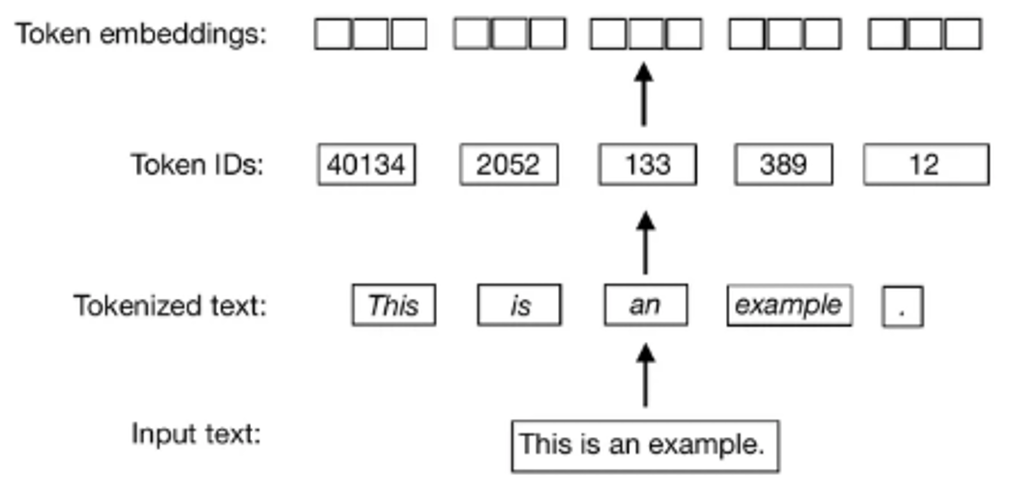

In [ ]:

Image('tokenized_text.png')

ed anche quest'altra (più ampia), sempre dello stesso autore:

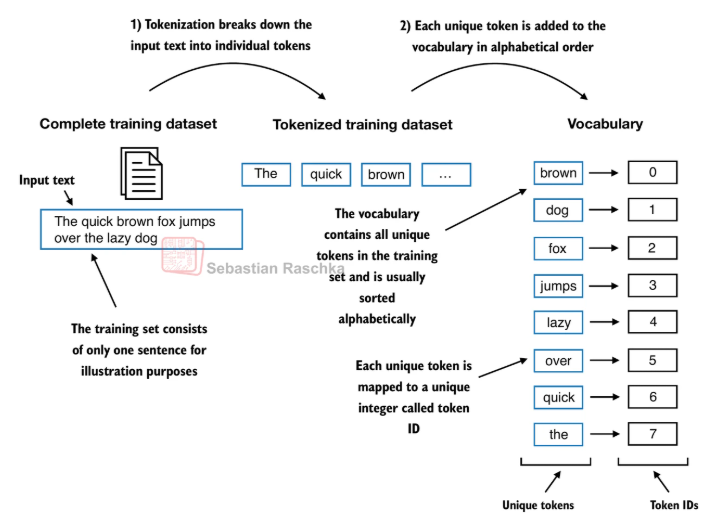

In [25]:
Image(filename='tokenizzazione_raschka.png')

## 2.8 Stop word

Un concetto di Text Mining e non di LLM.

Le **stop word** sono le parole grammaticali molto frequenti (articoli, preposizioni, congiunzioni, ausiliari) che compaiono in *tutti* i testi e quindi non aiutano a distinguerli. Quando *contiamo* le parole, eliminarle riduce il rumore e le dimensioni dei dati.

Una lista di stop word è **solo una lista**: non c'è nulla di magico, e va adattata al problema. Oltre alle parole grammaticali aggiungiamo infatti alcune **stop word di dominio**: parole come `mittente`, `oggetto` o `saluti`, che nel *nostro* archivio compaiono in ogni documento.

⚠️ **Quando NON toglierle.**
- Abbiamo lasciato fuori di proposito **`non`** e **`senza`**: la negazione cambia il significato (`non funziona` ≠ `funziona`), e in compiti come l'analisi dei reclami è decisiva.
- Per embeddings neurali e LLM **non si tolgono mai**: quei modelli leggono la frase intera e hanno bisogno della grammatica.

Librerie come `nltk` e `spaCy` forniscono liste già pronte per l'italiano; qui ne definiamo una nostra, breve e ispezionabile, per non avere dipendenze e per poterla modificare in aula.

> 🔧 **Da personalizzare — le stop word di dominio e la lingua.** `STOP_WORD_DOMINIO` contiene le parole onnipresenti nei *nostri* documenti. Per trovare quelle dell'archivio vero basta rieseguire su di esso il conteggio dei token più frequenti contenuto in questa stessa cella: le parole in cima alla classifica che non distinguono un documento dall'altro (il nome dell'azienda, le etichette dei moduli, le formule legali) sono le candidate. Con documenti in altre lingue cambiano anche `STOP_WORD_IT`, lo stemmer della sezione 2.8 e il modello spaCy.

In [39]:
STOP_WORD_IT = sorted(set("""
il lo la le gli un uno una
di da in con su per tra fra
del dello della dei degli delle dell al allo alla ai agli alle all dal dallo dalla dai dagli dalle dall
nel nello nella nei negli nelle nell sul sullo sulla sui sugli sulle sull col coi
ed od ma anche se che chi cui come dove quando perché poiché mentre oppure quindi però inoltre né
mi ti ci vi si li ne io tu lui lei noi voi loro
mio mia miei mie tuo tua suo sua suoi sue nostro nostra nostri nostre vostro vostra vostri vostre
questo questa questi queste quest quello quella quelli quelle quell ciò
sono sei siamo siete era erano essere stato stata stati state sarà saranno sia siano
ho ha hai abbiamo avete hanno aveva avere avuto
più molto già ancora solo così poi qui qua sempre ogni qualsiasi
tutto tutti tutta tutte altro altri altra altre stesso stessa
""".split()))

# Stop word "di dominio": parole che nel NOSTRO archivio compaiono ovunque (etichette dei campi, formule
# di saluto) e quindi non distinguono un documento dall'altro. Ogni archivio ha le sue.
STOP_WORD_DOMINIO = ["mittente", "oggetto", "data", "saluti", "cordiali", "distinti", "presente"]
STOP_WORD_IT = sorted(set(STOP_WORD_IT) | set(STOP_WORD_DOMINIO))

print(f"Stop word nella nostra lista: {len(STOP_WORD_IT)}")


Stop word nella nostra lista: 168


In [40]:
STOP_WORD_IT

['abbiamo',
 'agli',
 'ai',
 'al',
 'all',
 'alla',
 'alle',
 'allo',
 'altra',
 'altre',
 'altri',
 'altro',
 'anche',
 'ancora',
 'avere',
 'avete',
 'aveva',
 'avuto',
 'che',
 'chi',
 'ci',
 'ciò',
 'coi',
 'col',
 'come',
 'con',
 'cordiali',
 'così',
 'cui',
 'da',
 'dagli',
 'dai',
 'dal',
 'dall',
 'dalla',
 'dalle',
 'dallo',
 'data',
 'degli',
 'dei',
 'del',
 'dell',
 'della',
 'delle',
 'dello',
 'di',
 'distinti',
 'dove',
 'ed',
 'era',
 'erano',
 'essere',
 'fra',
 'già',
 'gli',
 'ha',
 'hai',
 'hanno',
 'ho',
 'il',
 'in',
 'inoltre',
 'io',
 'la',
 'le',
 'lei',
 'li',
 'lo',
 'loro',
 'lui',
 'ma',
 'mentre',
 'mi',
 'mia',
 'mie',
 'miei',
 'mio',
 'mittente',
 'molto',
 'ne',
 'negli',
 'nei',
 'nel',
 'nell',
 'nella',
 'nelle',
 'nello',
 'noi',
 'nostra',
 'nostre',
 'nostri',
 'nostro',
 'né',
 'od',
 'oggetto',
 'ogni',
 'oppure',
 'per',
 'perché',
 'però',
 'più',
 'poi',
 'poiché',
 'presente',
 'qua',
 'qualsiasi',
 'quando',
 'quell',
 'quella',
 'quelle'

Una domanda molto interessante è la seguente:

> Quali sono le parole più frequenti del corpus, <u>prima</u> e <u>dopo</u> aver tolto le stop word?

In [41]:
tutti_i_token = [t for testo in documenti["testo_normalizzato"] for t in re.findall(TOKEN_PATTERN, testo)]
insieme_stop_word = set(STOP_WORD_IT)               # la ricerca in un set è molto più veloce che in una lista
token_senza_stop = [t for t in tutti_i_token if t not in insieme_stop_word]

print(f"\nToken totali nel corpus: {migliaia(len(tutti_i_token))}  ->  senza stop word: {migliaia(len(token_senza_stop))} "
      f"({1 - len(token_senza_stop) / len(tutti_i_token):.0%} in meno)")
print("\n15 token più frequenti PRIMA :", [parola for parola, _ in Counter(tutti_i_token).most_common(15)])
print("15 token più frequenti DOPO  :", [parola for parola, _ in Counter(token_senza_stop).most_common(15)])


Token totali nel corpus: 30.728  ->  senza stop word: 18.955 (38% in meno)

15 token più frequenti PRIMA : ['il', 'di', 'la', 'in', 'per', 'servizio', 'un', 'si', 'del', 'mittente', 'oggetto', 'saluti', 'fattura', 'non', 'giorni']
15 token più frequenti DOPO  : ['servizio', 'fattura', 'non', 'giorni', 'contratto', 'documentazione', 'pagamento', 'richiesta', 'importo', 'comunicazione', 'bonifico', 'entro', 'euro', 'quanto', 'inviamo']


💡 Prima della rimozione, le parole più frequenti erano quasi tutte grammaticali e non dicevano nulla sul contenuto (interessante); dopo, emergono le parole che descrivono davvero di che cosa parla l'archivio. È un fenomeno generale (noto come [*legge di Zipf*](https://it.wikipedia.org/wiki/Legge_di_Zipf)): in qualsiasi lingua poche parole coprono gran parte del testo.

## 2.9 Stemming o lemmatizzazione?

`fattura`, `fatture`, `fatturazione`; `pagare`, `pagato`, `pagamento`: per chi *conta le parole* sono tutte parole diverse, ma esprimono lo stesso concetto. Due tecniche le riconducono a una forma comune:

| | **Stemming** | **Lemmatizzazione** |
|---|---|---|
| Che cosa fa | Taglia i suffissi con **regole** meccaniche e ottiene una **radice** (*stem*). | Riporta ogni parola al suo **lemma**, cioè la forma che troveremmo sul dizionario, usando un vocabolario e l'analisi grammaticale. |
| Esempio | `pagamenti` → `pag` | `pagamenti` → `pagamento`; `sono` → `essere` |
| Il risultato è una parola vera? | Spesso no. | Sì. |
| Velocità e requisiti | Velocissimo, nessun modello da scaricare. | Più lento, richiede un modello linguistico. |
| Errori tipici | *Over-stemming*: fonde parole di significato diverso. *Under-stemming*: non riesce a fondere forme della stessa parola. | Sbaglia sulle parole che non conosce e quando l'analisi grammaticale è incerta. |

Seguiamo il solito percorso: prima una versione **fatta a mano**, per capire il principio, poi quella **di libreria**.

In [42]:
# --- Versione "a mano": uno stemmer ingenuo che taglia il suffisso più lungo che trova -----------------------
SUFFISSI = ["azione", "azioni", "amento", "amenti", "imento", "imenti", "mente", "abile", "ibile",
            "ando", "endo", "are", "ere", "ire", "ato", "ata", "ati", "ate", "ito", "ita", "iti", "ite",
            "uto", "uta", "i", "e", "a", "o"]
SUFFISSI.sort(key=len, reverse=True)       # proviamo prima i suffissi più lunghi


def stemmer_ingenuo(parola):
    """Toglie il primo suffisso che corrisponde, purché restino almeno 3 lettere di radice."""
    for suffisso in SUFFISSI:
        if parola.endswith(suffisso) and len(parola) - len(suffisso) >= 3:
            return parola[:-len(suffisso)]
    return parola


# --- Versione di libreria: lo stemmer Snowball per l'italiano, fornito da nltk -------------------------------
# Snowball è una famiglia di stemmer basati su regole, uno per lingua: non richiede di scaricare modelli.
try:
    from nltk.stem.snowball import SnowballStemmer
    stemmer_snowball = SnowballStemmer("italian").stem
    print("Stemmer Snowball (nltk) disponibile.")
except ImportError:
    stemmer_snowball = None
    print("nltk non è installata: proseguiamo con lo stemmer ingenuo (pip install nltk per il confronto).")

parole_prova = ["fattura", "fatture", "fatturazione", "pagamento", "pagamenti", "pagare", "pagato",
                "contratto", "contratti", "contrattuale", "tecnico", "tecnica", "tecnici",
                "università", "universo", "rapidamente"]
confronto = pd.DataFrame({"parola": parole_prova,
                          "stemmer ingenuo": [stemmer_ingenuo(p) for p in parole_prova]})
if stemmer_snowball:
    confronto["Snowball (nltk)"] = [stemmer_snowball(p) for p in parole_prova]
confronto

Stemmer Snowball (nltk) disponibile.


,parola,stemmer ingenuo,Snowball (nltk)
0,fattura,fattur,fattur
1,fatture,fattur,fattur
2,fatturazione,fattur,fattur
3,pagamento,pag,pag
4,pagamenti,pag,pag
5,pagare,pag,pag
6,pagato,pag,pag
7,contratto,contratt,contratt
8,contratti,contratt,contratt
9,contrattuale,contrattual,contrattual


💡 **Che cosa osserviamo.** Le diverse forme di *fattura* e di *pagare* convergono sulla stessa radice, che **non è una parola di senso compiuto**: va benissimo, perché la radice è solo un'etichetta usata per contare. Controlliamo nella tabella anche i casi delicati: *università* e *universo* finiscono nella stessa radice (sarebbe over-stemming)? *contrattuale* raggiunge *contratto* (altrimenti è under-stemming)?

Vediamo ora la lemmatizzazione con **spaCy**, una libreria NLP «industriale». Il suo modello per l'italiano `it_core_news_sm` (la sigla `sm` sta per *small*: circa 15 MB) esegue in un colpo solo tokenizzazione, analisi grammaticale, lemmatizzazione e riconoscimento di entità (che useremo nella sezione 6).

Riconoscimento di entità ([*Entity Recognition*](https://en.wikipedia.org/wiki/Named-entity_recognition)): città, persone, aziende, ecc.

In [43]:
# ⭐ Lemmatizzazione con spaCy (facoltativa: richiede 'pip install spacy' e
#    'python -m spacy download it_core_news_sm').
try:
    import spacy
    nlp_it = spacy.load("it_core_news_sm")
except Exception as errore:                          # libreria o modello non installati
    nlp_it = None
    print(f"spaCy o il modello italiano non sono disponibili ({type(errore).__name__}): saltiamo la dimostrazione.")

if nlp_it is not None:
    frase_prova = "I tecnici hanno installato le correzioni e i pagamenti sono stati effettuati."
    analisi = nlp_it(frase_prova)                    # l'oggetto restituito è una sequenza di token "arricchiti"
    # token.text = la parola com'è scritta; token.lemma_ = il lemma; token.pos_ = la categoria grammaticale
    display(pd.DataFrame([{"token": t.text, "lemma": t.lemma_, "categoria grammaticale": t.pos_}
                          for t in analisi if not t.is_punct]))

spaCy o il modello italiano non sono disponibili (OSError): saltiamo la dimostrazione.


**Quale scegliere?** Una regola pratica:

- con **TF-IDF e pochi dati** (centinaia di documenti), stemming o lemmatizzazione aiutano, perché concentrano su una sola radice i conteggi altrimenti dispersi su molte forme;
- con **TF-IDF ma molti dati**, il vantaggio si assottiglia: il modello vede abbastanza esempi di ogni forma;
- con **embeddings neurali e LLM**, nessuna delle due: si passa il testo naturale.

Nella sezione 4 lo misureremo, invece di crederlo sulla parola.

## 2.9 Il nostro tokenizzatore completo

Riuniamo tutto in una funzione `tokenizza`, con due interruttori per attivare o no stop word e stemming. Un dettaglio utile sui grandi volumi: le stesse parole si ripetono migliaia di volte, quindi **memorizziamo** la radice già calcolata con `functools.lru_cache` (una *cache*: alla seconda richiesta della stessa parola la risposta è immediata).

In [44]:
from functools import lru_cache

# Usiamo Snowball se c'è, altrimenti lo stemmer ingenuo: il resto del notebook non cambia.
_funzione_radice = stemmer_snowball or stemmer_ingenuo


@lru_cache(maxsize=100_000)
def radice(parola):
    """Radice della parola, con memorizzazione dei risultati già calcolati."""
    return _funzione_radice(parola)


def tokenizza(testo_normalizzato, togli_stop_word=True, applica_stemming=False):
    """Da un testo GIÀ normalizzato (minuscolo) a una lista di token."""
    token = re.findall(TOKEN_PATTERN, testo_normalizzato)
    if togli_stop_word:
        token = [t for t in token if t not in insieme_stop_word]
    if applica_stemming:
        token = [radice(t) for t in token]
    return token


testo_prova = documenti["testo_normalizzato"].iloc[0]
print("Testo normalizzato :", testo_prova[:160], "...")
print("\nToken              :", tokenizza(testo_prova)[:14], "...")
print("\nToken con stemming :", tokenizza(testo_prova, applica_stemming=True)[:14], "...")

Testo normalizzato : mittente: stefano bruno - sigma consulting s.r.l. - oggetto: documentazione allegata in riferimento alla pratica n. relativa al servizio posta certificata, si c ...

Token              : ['stefano', 'bruno', 'sigma', 'consulting', 'documentazione', 'allegata', 'riferimento', 'pratica', 'relativa', 'servizio', 'posta', 'certificata', 'comunica', 'quanto'] ...

Token con stemming : ['stef', 'brun', 'sigm', 'consulting', 'document', 'alleg', 'rifer', 'pratic', 'relat', 'serviz', 'post', 'certific', 'comun', 'quant'] ...


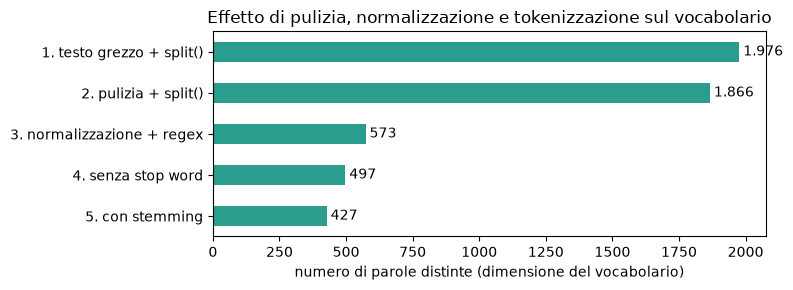

In [45]:
# Quanto si riduce il VOCABOLARIO (numero di parole distinte) a ogni passo?
# Un vocabolario più piccolo significa meno colonne nelle matrici della sezione 3 e conteggi meno dispersi.
def dimensione_vocabolario(liste_di_token):
    return len({token for lista in liste_di_token for token in lista})


passi = {
    "1. testo grezzo + split()": [t.split() for t in documenti["testo_grezzo"]],
    "2. pulizia + split()": [t.split() for t in documenti["testo_leggibile"]],
    "3. normalizzazione + regex": [tokenizza(t, togli_stop_word=False) for t in documenti["testo_normalizzato"]],
    "4. senza stop word": [tokenizza(t) for t in documenti["testo_normalizzato"]],
    "5. con stemming": [tokenizza(t, applica_stemming=True) for t in documenti["testo_normalizzato"]],
}
dimensioni = pd.Series({nome: dimensione_vocabolario(liste) for nome, liste in passi.items()})

asse = dimensioni[::-1].plot.barh(figsize=(8, 3), color="#2a9d8f")
asse.set_xlabel("numero di parole distinte (dimensione del vocabolario)")
asse.set_title("Effetto di pulizia, normalizzazione e tokenizzazione sul vocabolario")
for posizione, valore in enumerate(dimensioni[::-1]):
    asse.text(valore, posizione, f" {migliaia(valore)}", va="center")
plt.tight_layout()
plt.show()

💡 Il salto più grande avviene tra il passo 2 e il passo 3: eliminando codici, numeri, e-mail, maiuscole e punteggiatura attaccata, sparisce la gran parte delle «parole», quasi tutte comparse una volta sola. In un archivio reale l'effetto è ancora più marcato.

## 2.10 🛠️ Esercizio 1 (con l'assistente AI): mascherare i dati sensibili

**Contesto.** Prima di archiviare i testi in un sistema di analisi, o di inviarli a un servizio esterno, è buona norma **mascherare** i dati personali. Vogliamo una funzione `maschera_dati_sensibili(testo)` che sostituisca:

- gli indirizzi e-mail con `[EMAIL]`;
- gli IBAN italiani, scritti con o senza spazi, con `[IBAN]`;
- le partite IVA (11 cifre consecutive) con `[PIVA]`;

e che lasci **intatto tutto il resto** (importi, date, numeri di ticket).

**Il metodo di lavoro con l'assistente**, che riuseremo in tutti gli esercizi:

1. **Specifica prima del codice.** Scriviamo che cosa deve fare la funzione, con esempi di ingresso e uscita. Un prompt vago produce codice vago.
2. **I test li scriviamo (o almeno li controlliamo) noi.** Sono la nostra definizione di «funziona». Qui sotto sono già pronti, nella funzione `collauda_mascheratura`.
3. **Generiamo** il codice con Copilot o Cursor, poi lo **collaudiamo**.
4. **Leggiamo** il codice generato prima di accettarlo: lo capiamo? Tratta i casi limite? Ha importato librerie di cui non abbiamo bisogno?

**Prompt suggerito** (da incollare nella chat di Copilot o di Cursor, con questo notebook aperto):

```text
Scrivi in Python la funzione maschera_dati_sensibili(testo: str) -> str usando solo il modulo re.
Deve sostituire: gli indirizzi e-mail con [EMAIL]; gli IBAN italiani (IT + 2 cifre + 23 caratteri
alfanumerici, con o senza spazi ogni 4 caratteri) con [IBAN]; le partite IVA (esattamente 11 cifre
consecutive, non precedute o seguite da altre cifre o lettere) con [PIVA].
Non deve modificare importi in euro, date e codici come TCK-104233 o FT-2026-00123.
Compila le espressioni regolari una sola volta fuori dalla funzione, commenta ogni espressione
in italiano e aggiungi una docstring con due esempi.
```

⚠️ Nel prompt mettiamo **solo dati di fantasia**, mai frammenti di documenti reali (assunzione A8).

In [23]:
# I TEST: coppie (testo di ingresso, risultato atteso). Li scriviamo PRIMA della funzione.
def collauda_mascheratura(funzione):
    """Esegue i casi di prova sulla funzione passata e stampa l'esito di ciascuno."""
    casi = [
        ("Scrivere a mario.rossi@alfasistemi.example per informazioni.", "Scrivere a [EMAIL] per informazioni."),
        ("Coordinate: IBAN IT60 X054 2811 1010 0000 0123 456.", "Coordinate: IBAN [IBAN]."),
        ("IBAN: IT60X0542811101000000123456", "IBAN: [IBAN]"),
        ("Partita IVA del cedente: 12345678901.", "Partita IVA del cedente: [PIVA]."),
        # casi "negativi": qui la funzione NON deve cambiare nulla
        ("Totale da pagare: € 1.220,00 entro il 12/03/2026.", "Totale da pagare: € 1.220,00 entro il 12/03/2026."),
        ("Ticket TCK-104233 e fattura FT-2026-00123.", "Ticket TCK-104233 e fattura FT-2026-00123."),
    ]
    superati = 0
    for ingresso, atteso in casi:
        ottenuto = funzione(ingresso)
        esito = "OK " if ottenuto == atteso else "NO "
        superati += ottenuto == atteso
        print(f"[{esito}] {ingresso}")
        if ottenuto != atteso:
            print(f"        atteso  : {atteso}\n        ottenuto: {ottenuto}")
    print(f"\nCasi superati: {superati} su {len(casi)}")

In [24]:
# 🛠️ SPAZIO PER L'ESERCIZIO: incolliamo qui sotto la funzione generata dall'assistente, poi eseguiamo la cella.
# (Finché la funzione non esiste, la cella si limita a ricordarcelo: il notebook non si interrompe.)


if "maschera_dati_sensibili" in globals():
    collauda_mascheratura(maschera_dati_sensibili)
else:
    print("La funzione maschera_dati_sensibili non è ancora definita: generiamola con l'assistente e rieseguiamo.")

La funzione maschera_dati_sensibili non è ancora definita: generiamola con l'assistente e rieseguiamo.


**Soluzione di riferimento.** Confrontiamola con quella proposta dall'assistente: le differenze sono spesso istruttive (ordine delle sostituzioni, gestione degli spazi negli IBAN, confini di parola).

In [25]:
RE_IBAN = re.compile(r"\bIT\d{2}(?:\s?[A-Z0-9]){23}\b")
#   \bIT\d{2}            'IT' a inizio parola, seguito dalle 2 cifre di controllo
#   (?:\s?[A-Z0-9]){23}  23 caratteri alfanumerici, ciascuno eventualmente preceduto da uno spazio
#                        (così riconosciamo sia la forma compatta sia quella a gruppi di quattro)
RE_PARTITA_IVA = re.compile(r"\b\d{11}\b")
#   esattamente 11 cifre delimitate da confini di parola: non "pesca" dentro numeri più lunghi o dentro gli IBAN


def maschera_dati_sensibili_rif(testo):
    """Sostituisce e-mail, IBAN e partite IVA con dei segnaposto.

    >>> maschera_dati_sensibili_rif("Scrivere a anna@posta.example")
    'Scrivere a [EMAIL]'
    """
    testo = RE_EMAIL.sub("[EMAIL]", testo)
    testo = RE_IBAN.sub("[IBAN]", testo)            # PRIMA gli IBAN, poi le partite IVA
    testo = RE_PARTITA_IVA.sub("[PIVA]", testo)
    return testo


collauda_mascheratura(maschera_dati_sensibili_rif)

[OK ] Scrivere a mario.rossi@alfasistemi.example per informazioni.
[OK ] Coordinate: IBAN IT60 X054 2811 1010 0000 0123 456.
[OK ] IBAN: IT60X0542811101000000123456
[OK ] Partita IVA del cedente: 12345678901.
[OK ] Totale da pagare: € 1.220,00 entro il 12/03/2026.
[OK ] Ticket TCK-104233 e fattura FT-2026-00123.

Casi superati: 6 su 6


---
# 3. Rappresentare il testo con i numeri: bag-of-words, TF-IDF, embeddings

*Tempo indicativo: 40 minuti prima della pausa (3.1 – 3.6) e 20 minuti dopo (3.7 – 3.9). Secondo punto del programma.*

## 3.1 Perché servono i vettori

Gli algoritmi di machine learning non sanno nulla di parole: lavorano su **numeri**. Il passo centrale di tutto il text mining è quindi la **vettorizzazione**: trasformare ogni documento in un **vettore**, cioè una lista ordinata di numeri di lunghezza fissa. Una volta che i documenti sono vettori possiamo misurare quanto sono *vicini* (ricerca per similarità), tracciare *confini* tra gruppi (classificazione) e cercare *addensamenti* (clustering).

Vedremo tre modi di costruire questi vettori, in ordine crescente di raffinatezza:

| Rappresentazione | Idea | Tipo di vettore |
|---|---|---|
| **Bag-of-words** | Contiamo quante volte compare ogni parola. | Lunghissimo (una posizione per ogni parola del vocabolario) e quasi tutto di zeri: **sparso**. |
| **TF-IDF** | Come sopra, ma le parole *rare nel corpus* pesano di più di quelle che compaiono ovunque. | Come sopra. |
| **Embeddings** | Un modello comprime il *significato* del testo in poche centinaia di numeri. | Corto e tutto pieno: **denso**. |

## 3.2 Bag-of-words, prima a mano e poi con scikit-learn

*Bag-of-words* significa «sacco di parole»: immaginiamo di ritagliare tutte le parole di un documento e di buttarle in un sacco. Sappiamo **quali** parole ci sono e **quante volte**, ma abbiamo perso l'**ordine**.

Per costruire la rappresentazione servono due passi:

1. stabilire il **vocabolario**: l'elenco ordinato di tutte le parole distinte del corpus. A ogni parola corrisponde una posizione del vettore (in gergo ML una **feature**, cioè una caratteristica misurabile del documento);
2. per ogni documento, **contare** le occorrenze di ciascuna parola del vocabolario.

Il risultato è una tabella con una riga per documento e una colonna per parola: la **matrice documenti-termini**. Partiamo da un mini-corpus di quattro frasi, così i numeri si possono controllare a occhio (qui teniamo anche le stop word, per semplicità).

In [26]:
frasi = ["il cliente paga la fattura",
         "il fornitore paga il cliente",
         "il cliente paga il fornitore",
         "il server non risponde"]

# --- A MANO ---------------------------------------------------------------------------------------------
# 1) vocabolario: tutte le parole distinte, in ordine alfabetico
vocabolario = sorted({parola for frase in frasi for parola in frase.split()})
# 2) conteggi: Counter conta le occorrenze di ogni parola; conteggi[parola] vale 0 per le parole assenti
righe = []
for frase in frasi:
    conteggi = Counter(frase.split())
    righe.append([conteggi[parola] for parola in vocabolario])

bow_a_mano = pd.DataFrame(righe, columns=vocabolario, index=frasi)
bow_a_mano

,cliente,fattura,fornitore,il,la,non,paga,risponde,server
il cliente paga la fattura,1,1,0,1,1,0,1,0,0
il fornitore paga il cliente,1,0,1,2,0,0,1,0,0
il cliente paga il fornitore,1,0,1,2,0,0,1,0,0
il server non risponde,0,0,0,1,0,1,0,1,1


In [27]:
# --- CON SCIKIT-LEARN -------------------------------------------------------------------------------------
from sklearn.feature_extraction.text import CountVectorizer

# token_pattern: usiamo la STESSA definizione di token della sezione 2 (sequenze di almeno due lettere)
vettorizzatore_bow = CountVectorizer(token_pattern=TOKEN_PATTERN)

# fit_transform fa due cose: "fit" IMPARA il vocabolario dal corpus, "transform" CONTA le parole.
matrice_bow = vettorizzatore_bow.fit_transform(frasi)

bow_sklearn = pd.DataFrame(matrice_bow.toarray(),                        # toarray(): da matrice sparsa a tabella "piena"
                           columns=vettorizzatore_bow.get_feature_names_out(), index=frasi)
display(bow_sklearn)
print("Identica a quella costruita a mano?", bow_sklearn.equals(bow_a_mano))

# Il limite del "sacco di parole": le frasi 2 e 3 dicono cose OPPOSTE ma hanno lo stesso identico vettore.
print("\nLe frasi 2 e 3 hanno lo stesso vettore?", (bow_sklearn.iloc[1] == bow_sklearn.iloc[2]).all())

,cliente,fattura,fornitore,il,la,non,paga,risponde,server
il cliente paga la fattura,1,1,0,1,1,0,1,0,0
il fornitore paga il cliente,1,0,1,2,0,0,1,0,0
il cliente paga il fornitore,1,0,1,2,0,0,1,0,0
il server non risponde,0,0,0,1,0,1,0,1,1


Identica a quella costruita a mano? True

Le frasi 2 e 3 hanno lo stesso vettore? True


⚠️ **Il limite del sacco di parole.** *«Il fornitore paga il cliente»* e *«il cliente paga il fornitore»* hanno significati opposti ma vettori identici: l'ordine è andato perso.

Un rimedio parziale sono gli **n-grammi**: invece delle sole parole singole (*unigrammi*), contiamo anche le sequenze di *n* parole consecutive. Con i **bigrammi** (*n* = 2) `fornitore paga` e `cliente paga` diventano feature distinte, e le due frasi tornano distinguibili. Il prezzo è un vocabolario molto più grande.

In [28]:
# ngram_range=(1, 2) significa: "usa come feature sia le parole singole (1) sia le coppie di parole consecutive (2)"
vettorizzatore_bigrammi = CountVectorizer(token_pattern=TOKEN_PATTERN, ngram_range=(1, 2))
matrice_bigrammi = vettorizzatore_bigrammi.fit_transform(frasi)

print("Feature con i soli unigrammi     :", len(vettorizzatore_bow.get_feature_names_out()))
print("Feature con unigrammi + bigrammi :", len(vettorizzatore_bigrammi.get_feature_names_out()))
print("Esempi di bigrammi               :", [f for f in vettorizzatore_bigrammi.get_feature_names_out() if " " in f][:6])
print("\nLe frasi 2 e 3 hanno ancora lo stesso vettore?",
      (matrice_bigrammi[1].toarray() == matrice_bigrammi[2].toarray()).all())

Feature con i soli unigrammi     : 9
Feature con unigrammi + bigrammi : 19
Esempi di bigrammi               : ['cliente paga', 'fornitore paga', 'il cliente', 'il fornitore', 'il server', 'la fattura']

Le frasi 2 e 3 hanno ancora lo stesso vettore? False


## 3.3 Matrici sparse: il trucco che rende possibile lavorare su grandi volumi

Applichiamo il bag-of-words all'intero corpus. Ogni documento usa poche decine di parole, mentre il vocabolario ne contiene molte di più: la matrice è in gran parte fatta di **zeri**. scikit-learn la memorizza quindi in formato **sparso**: invece di tutte le celle, conserva solo i valori diversi da zero e la loro posizione. Non è un dettaglio tecnico: è ciò che rende trattabili i grandi archivi.

In [29]:
vettorizzatore_corpus = CountVectorizer(token_pattern=TOKEN_PATTERN, stop_words=STOP_WORD_IT)
matrice_conteggi = vettorizzatore_corpus.fit_transform(documenti["testo_normalizzato"])

n_documenti, n_parole = matrice_conteggi.shape
celle_non_zero = matrice_conteggi.nnz                      # nnz = "number of non-zero"
# Una matrice sparsa (formato CSR) è fatta di tre array: i valori, gli indici di colonna, i puntatori di riga.
byte_sparsa = matrice_conteggi.data.nbytes + matrice_conteggi.indices.nbytes + matrice_conteggi.indptr.nbytes
byte_densa = n_documenti * n_parole * 8                    # 8 byte per ogni numero a 64 bit

print(f"Matrice documenti-termini: {n_documenti} righe (documenti) x {migliaia(n_parole)} colonne (parole)")
print(f"Celle diverse da zero    : {migliaia(celle_non_zero)} su {migliaia(n_documenti * n_parole)} "
      f"({celle_non_zero / (n_documenti * n_parole):.1%}): in media {celle_non_zero / n_documenti:.0f} parole distinte per documento")
print(f"Memoria in formato sparso: {byte_sparsa / 1024:8.0f} KB")
print(f"Memoria in formato denso : {byte_densa / 1024:8.0f} KB  ({byte_densa / byte_sparsa:.0f} volte di più)")

Matrice documenti-termini: 326 righe (documenti) x 497 colonne (parole)
Celle diverse da zero    : 17.082 su 162.022 (10.5%): in media 52 parole distinte per documento
Memoria in formato sparso:      201 KB
Memoria in formato denso :     1266 KB  (6 volte di più)


💡 **Proiettiamo questi numeri su un archivio reale.** Il nostro corpus sintetico nasce da pochi modelli di frase e ha un vocabolario minuscolo (qualche centinaio di parole), quindi qui il risparmio è modesto. In un archivio vero il vocabolario conta decine o centinaia di migliaia di termini, mentre le parole distinte per documento restano poche decine: la quota di celle piene scende sotto lo 0,1% e il vantaggio diventa enorme. Con 1 milione di documenti e un vocabolario di 200.000 termini, la matrice *densa* richiederebbe 1.000.000 × 200.000 × 8 byte = **1,6 terabyte**: impossibile da tenere in memoria. In formato *sparso*, con una cinquantina di parole distinte per documento, bastano poche centinaia di megabyte. Tutti gli algoritmi di scikit-learn che useremo accettano direttamente matrici sparse.

## 3.4 TF-IDF: non tutte le parole pesano uguale

Nel bag-of-words la parola `servizio`, che nel nostro archivio compare quasi ovunque, conta quanto `rimborso`, che compare solo nei reclami. Eppure è la seconda a dirci di che cosa parla il documento. Il **TF-IDF** corregge questo difetto moltiplicando due quantità:

- **TF** (*term frequency*, frequenza del termine): quante volte il termine compare **in questo documento**. Più compare, più è rappresentativo del documento.
- **IDF** (*inverse document frequency*, frequenza inversa nei documenti): una misura di quanto il termine è **raro nel corpus**. Se `N` è il numero di documenti e `df(t)` (*document frequency*) il numero di documenti che contengono il termine `t`, scikit-learn usa:

$$\mathrm{idf}(t) = \ln\frac{1 + N}{1 + \mathrm{df}(t)} + 1$$

  Un termine presente in **tutti** i documenti ha `idf = 1` (il minimo); più il termine è raro, più l'IDF cresce. Gli «1 +» servono a evitare divisioni per zero e a non azzerare del tutto i termini onnipresenti.

Il peso di un termine in un documento è `tf × idf`. Infine ogni vettore-documento viene diviso per la propria lunghezza (**normalizzazione L2**: la lunghezza di un vettore è la radice quadrata della somma dei quadrati dei suoi elementi), così un documento lungo e uno breve che parlano della stessa cosa ottengono vettori confrontabili.

Rifacciamo il calcolo **a mano** sul mini-corpus, e poi verifichiamo che scikit-learn produca esattamente gli stessi numeri.

In [30]:
# --- A MANO, partendo dalla tabella dei conteggi (bag-of-words) del mini-corpus ------------------------------
tf = bow_a_mano.to_numpy(dtype=float)                 # tf[i, j] = quante volte la parola j compare nella frase i
N = tf.shape[0]                                       # numero di documenti (qui: 4 frasi)
df_termini = (tf > 0).sum(axis=0)                     # in quanti documenti compare ciascuna parola
idf = np.log((1 + N) / (1 + df_termini)) + 1          # la formula vista sopra (np.log è il logaritmo naturale)

pesi = tf * idf                                       # prodotto elemento per elemento: tf x idf
lunghezze = np.sqrt((pesi ** 2).sum(axis=1, keepdims=True))   # lunghezza (norma L2) di ogni riga
tfidf_a_mano = pesi / lunghezze                       # normalizzazione: ogni riga ora ha lunghezza 1

print("In quanti documenti compare ogni parola, e IDF che ne risulta:")
display(pd.DataFrame({"df": df_termini, "idf": idf.round(3)}, index=vocabolario).T)
print("Matrice TF-IDF calcolata a mano:")
pd.DataFrame(tfidf_a_mano.round(3), columns=vocabolario, index=frasi)

In quanti documenti compare ogni parola, e IDF che ne risulta:


,cliente,fattura,fornitore,il,la,non,paga,risponde,server
df,3.000,1.000,2.000,4.0,1.000,1.000,3.000,1.000,1.000
idf,1.223,1.916,1.511,1.0,1.916,1.916,1.223,1.916,1.916


Matrice TF-IDF calcolata a mano:


,cliente,fattura,fornitore,il,la,non,paga,risponde,server
il cliente paga la fattura,0.363,0.569,0.000,0.297,0.569,0.000,0.363,0.000,0.000
il fornitore paga il cliente,0.402,0.000,0.496,0.657,0.000,0.000,0.402,0.000,0.000
il cliente paga il fornitore,0.402,0.000,0.496,0.657,0.000,0.000,0.402,0.000,0.000
il server non risponde,0.000,0.000,0.000,0.288,0.000,0.553,0.000,0.553,0.553


In [31]:
# --- CON SCIKIT-LEARN -------------------------------------------------------------------------------------
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_mini = TfidfVectorizer(token_pattern=TOKEN_PATTERN).fit_transform(frasi).toarray()
print("scikit-learn produce gli stessi numeri del calcolo a mano?", np.allclose(tfidf_mini, tfidf_a_mano))

scikit-learn produce gli stessi numeri del calcolo a mano? True


💡 Osserviamo la tabella: `il`, presente in tutte e quattro le frasi, ha l'IDF più basso; `server`, `non`, `risponde`, presenti in una sola frase, hanno il più alto. Il TF-IDF fa in automatico, e in modo graduale, ciò che la lista di stop word fa in modo drastico: **abbassa il peso delle parole che compaiono ovunque**.

## 3.5 Misurare la somiglianza: la similarità del coseno

Ora che i documenti sono vettori, come misuriamo quanto due documenti si somigliano? La misura standard per i testi è la **similarità del coseno**: il coseno dell'angolo tra i due vettori.

$$\cos(a, b) = \frac{a \cdot b}{\lVert a \rVert \, \lVert b \rVert}$$

Al numeratore c'è il **prodotto scalare** (la somma dei prodotti degli elementi corrispondenti), al denominatore il prodotto delle due lunghezze. Per vettori TF-IDF, che non hanno elementi negativi, il risultato va da **0** (nessun termine in comune: vettori perpendicolari) a **1** (stessa direzione: stesso «mix» di parole).

Perché l'angolo e non la distanza? Perché l'angolo **non dipende dalla lunghezza del documento**: un contratto di due pagine e un suo riassunto di tre righe puntano nella stessa direzione, anche se i conteggi sono molto diversi.

Un dettaglio utile: se i vettori sono già normalizzati a lunghezza 1 (come quelli di `TfidfVectorizer`), il denominatore vale 1 e il coseno **coincide con il prodotto scalare**. Calcolare tutte le similarità diventa un semplice prodotto tra matrici, velocissimo anche in formato sparso.

In [32]:
from sklearn.metrics.pairwise import cosine_similarity

# --- A MANO: coseno tra la frase 1 e la frase 2 del mini-corpus ---------------------------------------------
a, b = tfidf_a_mano[0], tfidf_a_mano[1]
coseno = (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))       # @ è l'operatore del prodotto scalare/matriciale
print(f"Coseno calcolato a mano tra frase 1 e frase 2: {coseno:.3f}")

# --- CON SCIKIT-LEARN: tutte le coppie in un colpo solo ------------------------------------------------------
etichette = [f"F{i + 1}" for i in range(len(frasi))]
for etichetta, frase in zip(etichette, frasi):
    print(f"  {etichetta}: {frase}")
pd.DataFrame(cosine_similarity(tfidf_a_mano).round(2), index=etichette, columns=etichette)

Coseno calcolato a mano tra frase 1 e frase 2: 0.487
  F1: il cliente paga la fattura
  F2: il fornitore paga il cliente
  F3: il cliente paga il fornitore
  F4: il server non risponde


,F1,F2,F3,F4
F1,1.00,0.49,0.49,0.09
F2,0.49,1.00,1.00,0.19
F3,0.49,1.00,1.00,0.19
F4,0.09,0.19,0.19,1.00


💡 Leggiamo la tabella: F2 e F3 hanno similarità 1 (stesso sacco di parole); F1 somiglia abbastanza a entrambe (condivide `cliente` e `paga`); F4 è quasi perpendicolare a tutte le altre, perché ha in comune solo `il`, che pesa pochissimo.

## 3.6 TF-IDF sul corpus e ricerca per similarità (*similarity search*)

Vettorizziamo ora l'intero corpus. I parametri del vettorizzatore meritano una spiegazione, perché sono le «manopole» che si regolano più spesso:

| Parametro | Valore | Significato |
|---|---|---|
| `token_pattern` | `TOKEN_PATTERN` | La nostra definizione di token (sezione 2.6). |
| `stop_words` | `STOP_WORD_IT` | Le parole da ignorare (sezione 2.7). |
| `ngram_range` | `(1, 2)` | Parole singole e coppie di parole consecutive: catturiamo espressioni come `bonifico bancario` o `non risponde`. |
| `min_df` | `2` | Ignora i termini presenti in meno di 2 documenti: un termine che compare una volta sola (spesso un nome proprio o un refuso) non può aiutare a trovare somiglianze. |

Con questa rappresentazione la **ricerca per similarità** è immediata: trasformiamo la domanda dell'utente in un vettore *con lo stesso vettorizzatore* (solo `transform`, **non** `fit`: il vocabolario e gli IDF restano quelli imparati dal corpus), calcoliamo il coseno con tutti i documenti e restituiamo i primi *k*.

> 🔧 **Da personalizzare — i parametri del vettorizzatore.** Con un archivio grande il vocabolario cresce molto: `min_df` si alza (5, 10…) per scartare i termini rari, e si possono aggiungere `max_df` (ignora i termini presenti in più di una data quota di documenti, per esempio `0.8`) e `max_features` (tiene solo i termini più frequenti). Il valore giusto si sceglie misurando, come nella sezione 4.9.

In [33]:
vettorizzatore_tfidf = TfidfVectorizer(token_pattern=TOKEN_PATTERN, stop_words=STOP_WORD_IT,
                                       ngram_range=(1, 2), min_df=2)
matrice_tfidf = vettorizzatore_tfidf.fit_transform(documenti["testo_normalizzato"])
termini = vettorizzatore_tfidf.get_feature_names_out()
print(f"Matrice TF-IDF del corpus: {matrice_tfidf.shape[0]} documenti x {migliaia(matrice_tfidf.shape[1])} termini\n")

# Quali sono i termini più "pesanti" di un documento? Sono, di fatto, le sue PAROLE CHIAVE.
posizione_esempio = documenti.index[documenti["file"] == file_esempio][0]
pesi_documento = matrice_tfidf[posizione_esempio].toarray().ravel()         # ravel(): da matrice 1 x n a vettore
in_ordine_di_peso = pesi_documento.argsort()[::-1]                         # indici dal peso più alto al più basso
# Per leggibilità mostriamo solo le parole singole (i termini senza spazio), tralasciando i bigrammi.
migliori = [i for i in in_ordine_di_peso if " " not in termini[i]][:8]
print(f"Parole con il peso TF-IDF più alto in {file_esempio} ({documenti.loc[posizione_esempio, 'categoria']}):")
for indice in migliori:
    print(f"   {termini[indice]:<20} {pesi_documento[indice]:.3f}")

Matrice TF-IDF del corpus: 326 documenti x 1.921 termini

Parole con il peso TF-IDF più alto in doc_0001.pdf (fattura):
   euro                 0.120
   bonifico             0.116
   pagamento            0.112
   entro                0.109
   pagare               0.098
   dieci                0.096
   gennaio              0.096
   contestazioni        0.096


💡 Le parole con il peso più alto sono, di fatto, le **parole chiave** del documento: un'estrazione di informazione a costo zero, che riprenderemo nella sezione 6. Notiamo che tra di esse può comparire anche il **nome del mittente**: è una parola rara nel corpus, quindi il suo IDF è alto. Il TF-IDF misura la *rarità*, non l'*importanza*: sta a noi decidere se i nomi propri sono un segnale utile o un rumore da eliminare.

In [34]:
def estratto(testo_leggibile, lunghezza=130):
    """Un breve estratto del documento da mostrare nei risultati (partiamo dall'oggetto, se c'è)."""
    inizio = max(testo_leggibile.find("Oggetto:"), 0)
    return testo_leggibile[inizio:inizio + lunghezza] + "..."


def cerca_tfidf(domanda, k=5):
    """Ricerca per similarità con TF-IDF: restituisce i k documenti più simili alla domanda."""
    # La domanda deve subire ESATTAMENTE lo stesso trattamento dei documenti: stessa normalizzazione,
    # stesso vettorizzatore. Usiamo transform (non fit_transform!): il vocabolario è quello del corpus.
    vettore_domanda = vettorizzatore_tfidf.transform([normalizza_testo(domanda)])
    if vettore_domanda.nnz == 0:
        print(f"«{domanda}»: nessuna parola della domanda è presente nel vocabolario del corpus -> nessun risultato.")
        return None
    # Vettori già normalizzati -> il prodotto scalare È la similarità del coseno.
    punteggi = (matrice_tfidf @ vettore_domanda.T).toarray().ravel()
    migliori = punteggi.argsort()[::-1][:k]
    risultati = documenti.loc[migliori, ["file", "categoria"]].copy()
    risultati.insert(0, "similarità", punteggi[migliori].round(3))
    risultati["estratto"] = [estratto(t) for t in documenti.loc[migliori, "testo_leggibile"]]
    return risultati


cerca_tfidf("rimborso per una consegna arrivata in ritardo")

,similarità,file,categoria,estratto
99,0.183,doc_0100.pdf,reclamo,Oggetto: Reclamo formale In riferimento alla pratica n. REC-2026-2432 relativa al servizio Gestionale Ordi...
267,0.173,doc_0268.pdf,reclamo,Oggetto: Documentazione allegata Facciamo seguito ai precedenti contatti sul servizio Portale Clienti (rif...
227,0.171,doc_0228.pdf,reclamo,Oggetto: Reclamo n. REC-2025-6394 Scrivo per contestare quanto accaduto con il servizio Gestionale Ordini ...
154,0.166,doc_0155.pdf,assistenza,Oggetto: Ticket TCK-106871 Si trasmette la documentazione rif. TCK-106871 riguardante il servizio Portale ...
203,0.146,doc_0204.pdf,reclamo,Oggetto: Contestazione della fattura n. FT-2025-09802 Reclamo n. REC-2025-3375: segnalo la mia totale inso...


La ricerca funziona bene quando domanda e documenti **usano le stesse parole**. Mettiamola in difficoltà con due prove:

1. cerchiamo `guasto`: nel corpus i problemi tecnici sono descritti anche come *malfunzionamento*, *anomalia*, *blocco*, *errore*…
2. cerchiamo con parole colloquiali che nei documenti non compaiono affatto.

In [35]:
# Prova 1: quanti documenti ottengono un punteggio maggiore di zero per la domanda "guasto"?
vettore_guasto = vettorizzatore_tfidf.transform(["guasto"])
punteggi_guasto = (matrice_tfidf @ vettore_guasto.T).toarray().ravel()
n_assistenza = (documenti["categoria"] == "assistenza").sum()
print(f"Documenti di assistenza tecnica nel corpus          : {n_assistenza}")
print(f"Documenti con similarità > 0 per la domanda 'guasto': {(punteggi_guasto > 0).sum()}")
print("-> tutti gli altri documenti di assistenza, che parlano di 'anomalia' o 'malfunzionamento', sono INVISIBILI.\n")

# Prova 2: parole che nel corpus non esistono
cerca_tfidf("il programma si pianta di continuo")

Documenti di assistenza tecnica nel corpus          : 81
Documenti con similarità > 0 per la domanda 'guasto': 16
-> tutti gli altri documenti di assistenza, che parlano di 'anomalia' o 'malfunzionamento', sono INVISIBILI.

«il programma si pianta di continuo»: nessuna parola della domanda è presente nel vocabolario del corpus -> nessun risultato.


⚠️ **Il limite di fondo di bag-of-words e TF-IDF.** Per questi metodi ogni parola è una dimensione a sé: `guasto` e `malfunzionamento` sono **perpendicolari**, esattamente come `guasto` e `curriculum`. Non c'è alcuna nozione di *significato*: contano solo le parole identiche. È il problema dei **sinonimi** (parole diverse, stesso significato), a cui si aggiunge quello speculare della **polisemia** (stessa parola, significati diversi: il *canone* di un contratto e il *canone* di bellezza).

Per superarlo servono gli **embeddings**. ☕ *È un buon punto per la pausa.*

---
> **📌 Il Text Mining**<br>
> Le tecniche che abbiamo visto sinora (TF, IDF e TF-IDF) sono molto usate anche nel [Text Mining](https://it.wikipedia.org/wiki/Text_mining).<br>
>
> 👉 Il text mining è **l’insieme di tecniche con cui si analizzano automaticamente grandi quantità di testo per estrarre informazione utile, pattern e conoscenza.** E' una tecnica differente dall'embedding, come vedremo.
>
> In altre parole: il Text Mining è il **modo “classico”** con cui si passa <u>dal testo grezzo a qualcosa di strutturato e analizzabile</u>.
>
> Il text mining permette di:
> * individuare parole chiave rilevanti
> * classificare documenti (es. spam / non spam)
> * scoprire argomenti (topic)
> * analizzare il sentiment (positivo/negativo)
> * trovare relazioni tra termini
> * riassumere testi

---

## 3.7 Embeddings: vettori che catturano il significato

Un **embedding** è un vettore **denso** (poche centinaia di numeri, tutti significativi) che rappresenta un testo in modo che **testi di significato simile abbiano vettori vicini**, anche se non condividono alcuna parola.

| | Bag-of-words / TF-IDF | Embedding |
|---|---|---|
| Dimensioni | migliaia o centinaia di migliaia (una per termine) | da 100 a qualche migliaio |
| Contenuto | quasi tutti zeri (**sparso**) | tutti valori non nulli (**denso**) |
| Che cosa significa una dimensione | «quanto pesa la parola *X*»: leggibile | nulla di leggibile: conta solo la posizione complessiva del vettore |
| Sinonimi | invisibili | vicini |

Da dove arrivano questi vettori? Da un'idea semplice e potente, la cosiddetta *ipotesi distribuzionale*: **parole che compaiono negli stessi contesti hanno significati simili**. Se `guasto` e `anomalia` compaiono entrambe vicino a `server`, `tecnico`, `riavviare`, probabilmente parlano della stessa cosa. Ci sono due strade per sfruttarla:

1. **ricavare gli embeddings dal nostro corpus**, con una tecnica di algebra lineare (LSA, qui sotto): nessun download, ma il modello «sa» solo ciò che c'è nei nostri documenti;
2. **usare una rete neurale preaddestrata** su miliardi di frasi (sezione 3.8): conosce la lingua in generale, quindi capisce anche parole che nel nostro archivio non compaiono mai.

### LSA: embeddings «fatti in casa»

La **LSA** (*Latent Semantic Analysis*, analisi semantica latente) comprime la matrice TF-IDF con una **SVD troncata** (*Singular Value Decomposition*, scomposizione ai valori singolari). Senza entrare nella matematica: la SVD trova un piccolo numero di **dimensioni latenti**, ognuna delle quali è una combinazione di parole che tendono a comparire insieme, una sorta di «tema» (il tema *problemi tecnici*, il tema *pagamenti*…). Ogni documento viene poi descritto da **quanto contiene di ciascun tema**, invece che da quali parole contiene. Due documenti che usano sinonimi diversi ma lo stesso contesto finiscono così vicini.

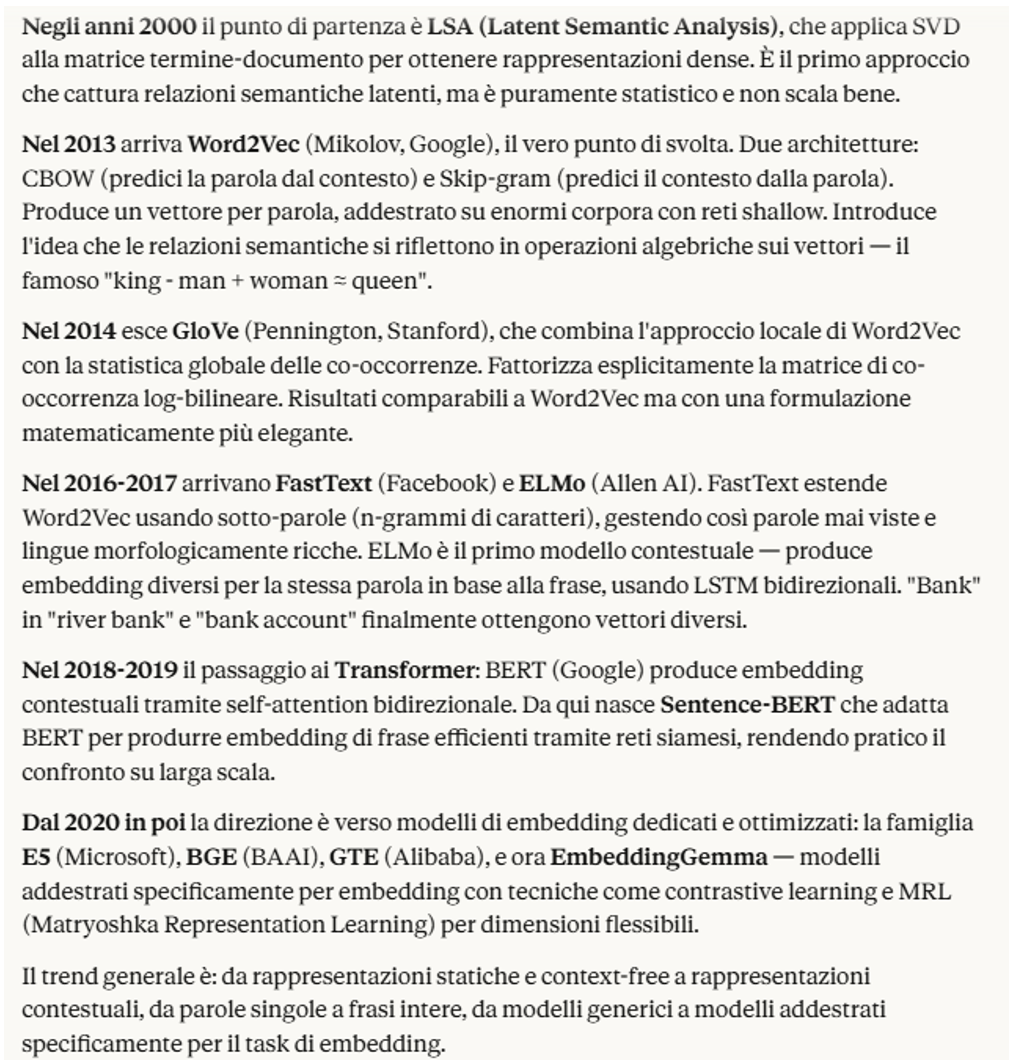

In [26]:
Image('storia_word_embedding_claude.png')

> 🔧 **Da personalizzare — il numero di dimensioni.** `N_DIMENSIONI_LSA = 30` va bene per i nostri cinque temi. Su un archivio reale, più vario, i valori tipici stanno tra 100 e 300.

In [10]:
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer

N_DIMENSIONI_LSA = 30
# make_pipeline concatena due passi: 1) SVD troncata: da migliaia di colonne sparse a 30 colonne dense;
#                                    2) Normalizer: riporta ogni vettore a lunghezza 1 (così coseno = prodotto scalare).
lsa = make_pipeline(TruncatedSVD(n_components=N_DIMENSIONI_LSA, random_state=SEME), Normalizer(copy=False))
embeddings_lsa = lsa.fit_transform(matrice_tfidf)

print(f"Da {matrice_tfidf.shape} (sparsa) a {embeddings_lsa.shape} (densa)")
print("Le prime 8 componenti dell'embedding del primo documento:", embeddings_lsa[0, :8].round(3))


def cerca_lsa(domanda, k=5):
    """Ricerca per similarità nello spazio LSA. La domanda segue la stessa strada dei documenti:
    normalizzazione -> TF-IDF -> proiezione sulle dimensioni latenti."""
    vettore_tfidf = vettorizzatore_tfidf.transform([normalizza_testo(domanda)])
    if vettore_tfidf.nnz == 0:
        print(f"«{domanda}»: nessuna parola della domanda è nel vocabolario -> nemmeno la LSA può aiutare.")
        return None
    punteggi = embeddings_lsa @ lsa.transform(vettore_tfidf).ravel()
    migliori = punteggi.argsort()[::-1][:k]
    parole_domanda = set(tokenizza(normalizza_testo(domanda)))
    risultati = documenti.loc[migliori, ["file", "categoria"]].copy()
    risultati.insert(0, "similarità", punteggi[migliori].round(3))
    # Quali parole della domanda compaiono DAVVERO nel documento? (stringa vuota = nessuna)
    risultati["parole in comune"] = [", ".join(sorted(parole_domanda & set(tokenizza(t))))
                                     for t in documenti.loc[migliori, "testo_normalizzato"]]
    risultati["estratto"] = [estratto(t, 100) for t in documenti.loc[migliori, "testo_leggibile"]]
    return risultati


risultati_guasto = cerca_lsa("guasto", k=40)
senza_la_parola = risultati_guasto[risultati_guasto["parole in comune"] == ""]
print(f"\nDomanda 'guasto' - tra i primi 40 risultati: "
      f"{(risultati_guasto['categoria'] == 'assistenza').sum()} sono documenti di assistenza, "
      f"e {len(senza_la_parola)} NON contengono la parola 'guasto'. Eccone alcuni:")
senza_la_parola.head(6)

NameError: name 'SEME' is not defined

💡 **Che cosa è cambiato.** I documenti mostrati parlano di *malfunzionamento*, *anomalia*, *blocco*: la parola *guasto* **non la contengono** (colonna `parole in comune` vuota), eppure ottengono una similarità alta. La LSA li ha avvicinati perché condividono il contesto (server, tecnico, errore, aggiornamento…). Con il TF-IDF puro quegli stessi documenti avevano similarità zero.

Il **numero di dimensioni** è una manopola: poche dimensioni producono «temi» molto generali (si generalizza di più, ma si perdono i dettagli); molte dimensioni conservano più sfumature ma avvicinano meno i sinonimi. Su corpora reali i valori tipici stanno tra 100 e 300; qui ne bastano 30, perché i temi del nostro archivio sono pochi.

⚠️ **Il limite della LSA.** Conosce solo le parole del nostro corpus: per la domanda *«il programma si pianta»* non può fare nulla, perché quelle parole non le ha mai viste. Per questo servono i modelli preaddestrati.

## 3.8 ⭐ Embeddings neurali preaddestrati e ricerca semantica

I modelli della famiglia **Sentence Transformers** sono reti neurali (di tipo *transformer*, la stessa architettura degli LLM) addestrate su enormi quantità di testo proprio per questo scopo: ricevono una frase o un breve paragrafo e restituiscono un embedding tale che **frasi di significato simile abbiano coseno alto**. Usiamo `paraphrase-multilingual-MiniLM-L12-v2`: un modello piccolo (gira bene anche su CPU), multilingue (oltre 50 lingue, italiano compreso), che produce vettori di 384 dimensioni.

Tre avvertenze pratiche:

- **Testo naturale, non normalizzato.** A questi modelli passiamo il `testo_leggibile`: niente minuscole forzate, niente rimozione di stop word, niente stemming. Hanno imparato dalla lingua vera ed è così che rendono meglio.
- **Lunghezza massima.** Ogni modello legge al massimo un certo numero di token (per questo modello 128, cioè un centinaio di parole scarse): il resto viene **troncato in silenzio**. I nostri documenti sono brevi; per PDF lunghi occorre prima spezzarli in blocchi (*chunking*) e calcolare un embedding per ciascun blocco.
- **Primo avvio.** Alla prima esecuzione il modello viene scaricato da Internet (circa 0,5 GB) e salvato in una cache locale; dalle volte successive si carica in pochi secondi.

Se la libreria o il modello non sono disponibili, la cella lo segnala e il notebook prosegue usando gli embeddings LSA come ripiego.

> 🔧 **Da personalizzare — il modello e la lunghezza dei testi.** `NOME_MODELLO_EMBEDDING` si può sostituire con un modello più grande e accurato, a prezzo di più calcolo. Soprattutto: qui calcoliamo **un embedding per documento**, perché i nostri testi sono brevi. I PDF reali sono lunghi e questo modello legge solo i primi 128 token circa: occorre prima **dividere ogni documento in blocchi** (*chunking*, sezione 3.9) e calcolare un embedding per blocco. È l'unico punto del notebook in cui c'è del codice da **aggiungere**, non solo da adattare.

In [37]:
NOME_MODELLO_EMBEDDING = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

try:
    from sentence_transformers import SentenceTransformer
    modello_embedding = SentenceTransformer(NOME_MODELLO_EMBEDDING)
    print(f"Modello caricato: {NOME_MODELLO_EMBEDDING}")
except Exception as errore:                       # libreria assente, rete non disponibile, ecc.
    modello_embedding = None
    print(f"Modello di embedding non disponibile ({type(errore).__name__}).")
    print("Proseguiamo con gli embeddings LSA come ripiego: i risultati della ricerca semantica saranno più poveri.")

if modello_embedding is not None:
    inizio = time.perf_counter()
    # encode() trasforma una lista di testi in una matrice (n_testi x 384).
    # normalize_embeddings=True -> vettori di lunghezza 1, quindi coseno = prodotto scalare.
    embeddings_neurali = modello_embedding.encode(documenti["testo_leggibile"].tolist(), batch_size=32,
                                                  normalize_embeddings=True, show_progress_bar=False)
    print(f"Calcolati {embeddings_neurali.shape[0]} embeddings di {embeddings_neurali.shape[1]} dimensioni "
          f"in {time.perf_counter() - inizio:.1f} s")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8291.61it/s]


Modello caricato: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Calcolati 326 embeddings di 384 dimensioni in 6.2 s


In [38]:
def cerca_semantica(domanda, k=5):
    """Ricerca semantica: usa gli embeddings neurali se disponibili, altrimenti ripiega sulla LSA."""
    if modello_embedding is None:
        return cerca_lsa(domanda, k)
    vettore_domanda = modello_embedding.encode([domanda], normalize_embeddings=True)[0]
    punteggi = embeddings_neurali @ vettore_domanda
    migliori = punteggi.argsort()[::-1][:k]
    risultati = documenti.loc[migliori, ["file", "categoria"]].copy()
    risultati.insert(0, "similarità", punteggi[migliori].round(3))
    risultati["estratto"] = [estratto(t) for t in documenti.loc[migliori, "testo_leggibile"]]
    return risultati


# Le prime due domande sono quelle "colloquiali" che hanno messo in crisi il TF-IDF: nessuna delle loro
# parole chiave (pianta, soldi, indietro...) compare nei documenti. La terza usa invece parole del corpus.
for domanda in ["il programma si pianta di continuo",
                "rivoglio indietro i miei soldi",
                "il sistema non risponde e non riesco ad accedere"]:
    print(f"\nDomanda: «{domanda}»")
    risultati = cerca_semantica(domanda, k=4)
    if risultati is not None:
        display(risultati)


Domanda: «il programma si pianta di continuo»


,similarità,file,categoria,estratto
6,0.395,doc_0007.pdf,assistenza,Oggetto: Comunicazione Si trasmette la documentazione rif. TCK-140789 riguardante il servizio Fatturazione...
211,0.380,doc_0212.pdf,assistenza,Oggetto: Comunicazione In riferimento alla pratica n. TCK-179258 relativa al servizio Reportistica Avanzat...
210,0.377,doc_0211.pdf,candidatura,Oggetto: Invio curriculum vitae Si trasmette la documentazione rif. HR-2026-892 riguardante il servizio Fa...
126,0.375,doc_0127.pdf,assistenza,Oggetto: Comunicazione del 7 agosto 2026 Richiesta di assistenza TCK-178012 a causa di un guasto che rigua...



Domanda: «rivoglio indietro i miei soldi»


,similarità,file,categoria,estratto
203,0.455,doc_0204.pdf,reclamo,Oggetto: Contestazione della fattura n. FT-2025-09802 Reclamo n. REC-2025-3375: segnalo la mia totale inso...
299,0.453,doc_0300.pdf,reclamo,Oggetto: Reclamo n. REC-2025-3358 Reclamo n. REC-2025-3358: segnalo la mia totale insoddisfazione per il s...
224,0.429,doc_0225.pdf,reclamo,Oggetto: Comunicazione Scrivo per contestare quanto accaduto con il servizio Fatturazione Online (pratica ...
267,0.395,doc_0268.pdf,reclamo,Oggetto: Documentazione allegata Facciamo seguito ai precedenti contatti sul servizio Portale Clienti (rif...



Domanda: «il sistema non risponde e non riesco ad accedere»


,similarità,file,categoria,estratto
226,0.598,doc_0227.pdf,assistenza,Oggetto: Intervento previsto dal contratto n. CTR-2026-0154 Ticket TCK-150693: l'utente segnala un malfunz...
199,0.577,doc_0200.pdf,assistenza,Oggetto: Vostra richiesta Richiesta di assistenza TCK-118513 a causa di un malfunzionamento che riguarda i...
137,0.558,doc_0138.pdf,assistenza,Oggetto: Ticket TCK-190881 Segnalazione TCK-190881: da questa mattina si verifica un malfunzionamento sul ...
118,0.547,doc_0119.pdf,assistenza,Oggetto: Comunicazione del 01/09/2025 Richiesta di assistenza TCK-174648 a causa di un'anomalia che riguar...


💡 **Che cosa ci aspettiamo con il modello neurale attivo.** La prima domanda dovrebbe riportare in cima segnalazioni di **assistenza** tecnica e la seconda **reclami** con richiesta di rimborso, benché le parole usate siano del tutto diverse da quelle dei documenti: è la **ricerca semantica**, cioè per significato e non per parole. Se invece è attivo il ripiego LSA, per le prime due domande vedremo il messaggio «nessuna parola nel vocabolario» (è esattamente il limite descritto sopra) e solo la terza, che usa parole presenti nel corpus, darà risultati.

## 3.9 Dal prototipo alla produzione: cosa cambia sui grandi volumi

- **Ricerca esatta o approssimata.** Qui confrontiamo la domanda con *tutti* i vettori: con `numpy` si regge bene fino a qualche centinaio di migliaia di documenti. Oltre, si usano indici **ANN** (*Approximate Nearest Neighbors*, vicini approssimati), che trovano i vettori più vicini senza guardarli tutti, sacrificando una piccola quota di precisione per velocità di ordini di grandezza superiori.
- **Database vettoriali.** Strumenti come FAISS (una libreria), Qdrant, Chroma, Milvus o l'estensione `pgvector` di PostgreSQL conservano gli embeddings insieme ai metadati dei documenti e offrono la ricerca ANN già pronta, con filtri (per esempio «solo i documenti del 2026»).
- **Chunking.** Un PDF di cinquanta pagine non si rappresenta con un solo vettore: lo si divide in blocchi di qualche centinaio di parole, possibilmente rispettando paragrafi e sezioni, e si indicizza ogni blocco.
- **Il collegamento con gli LLM.** La ricerca semantica è il primo pezzo della tecnica **RAG** (*Retrieval-Augmented Generation*, generazione aumentata dal recupero): si recuperano i blocchi più pertinenti a una domanda e li si passa a un LLM perché risponda *basandosi su quei testi*. Tutto ciò che abbiamo visto su estrazione e pulizia dei PDF è il prerequisito perché una RAG funzioni bene.

### Riepilogo della sezione

| | Bag-of-words | TF-IDF | LSA | Embeddings neurali |
|---|---|---|---|---|
| Coglie i sinonimi | no | no | in parte (solo se presenti nel corpus) | sì |
| Richiede modelli esterni | no | no | no | sì (download, più calcolo) |
| Interpretabile | sì | sì | poco | no |
| Costo di calcolo | minimo | minimo | basso | medio-alto (meglio con GPU sui grandi volumi) |
| Quando usarlo | conteggi, analisi esplorative | **punto di partenza** per ricerca e classificazione | corpus medio, niente dipendenze | ricerca semantica, RAG, pochi esempi etichettati |

---
# 4. Classificazione: assegnare a ogni documento la sua categoria

*Tempo indicativo: 35 minuti. Terzo punto del programma (prima parte).*

## 4.1 L'idea e le regole del gioco

**Classificare** significa assegnare a ogni documento una categoria scelta in un elenco prefissato: nel nostro caso `fattura`, `contratto`, `assistenza`, `reclamo`, `candidatura`. È il caso tipico di **apprendimento supervisionato**: disponiamo di esempi *già etichettati* e chiediamo a un algoritmo di ricavarne la regola che lega il testo alla categoria. Usi concreti: smistare la posta in arrivo verso l'ufficio giusto, dare priorità ai reclami, archiviare automaticamente.

Quattro concetti vanno fissati prima di scrivere codice, perché sono quelli su cui si sbaglia più spesso:

1. **Addestramento e verifica su dati diversi.** Un modello si giudica su documenti che **non ha mai visto**. Dividiamo quindi il corpus in due parti: l'insieme di **addestramento** (*training set*), da cui il modello impara, e l'insieme di **verifica** (*test set*), che teniamo da parte e usiamo solo per misurare. Valutare sugli stessi dati dell'addestramento equivale a dare a uno studente, all'esame, gli stessi esercizi già corretti in classe.
2. **Overfitting** (sovra-adattamento). È il rischio da cui ci protegge il punto 1: un modello può «imparare a memoria» gli esempi, comprese le loro particolarità casuali, e poi sbagliare sui documenti nuovi. Si riconosce da risultati eccellenti in addestramento e deludenti in verifica.
3. **Stratificazione.** Le nostre classi sono sbilanciate (le fatture sono più del doppio delle candidature). Dividendo a caso rischieremmo un insieme di verifica con pochissime candidature. Con la divisione **stratificata** ogni categoria mantiene la stessa proporzione in entrambe le parti.
4. **Data leakage** (fuga di informazioni). Si verifica quando informazioni dell'insieme di verifica «trapelano» nell'addestramento e gonfiano i risultati. L'esempio classico nel text mining: calcolare vocabolario e IDF su *tutto* il corpus prima di dividerlo. Il rimedio è la **`Pipeline`** di scikit-learn: un oggetto che incatena vettorizzatore e classificatore e garantisce che *tutto* ciò che viene «imparato» (vocabolario, IDF, pesi) provenga dai soli dati di addestramento.

⚠️ Un'altra forma di leakage riguarda proprio il nostro archivio: i **quasi-duplicati**. Se un sollecito finisce nell'addestramento e la sua copia nella verifica, il modello viene «interrogato» su un documento che in pratica conosce già. Qui sono solo 6 su 326 e l'effetto è trascurabile, ma negli archivi reali i duplicati sono molti: conviene individuarli (sezione 5.5) e tenerli dalla stessa parte.

> 🔧 **Da personalizzare — categorie ed etichette.** Le categorie sono quelle del file di etichette: qui non c'è codice da cambiare, ma è la personalizzazione che conta di più. Tre attenzioni con dati reali: servono, indicativamente, **almeno alcune decine di esempi per categoria**; va deciso che cosa fare dei documenti che **non appartengono a nessuna categoria** (una categoria `altro`, oppure la revisione manuale quando la confidenza è bassa: il notebook non gestisce questo caso); se ci sono molti quasi-duplicati, vanno tenuti dalla stessa parte della divisione (sezione 4.1).

In [39]:
from sklearn.model_selection import train_test_split

testi = documenti["testo_normalizzato"]          # l'ingresso del modello (in gergo: X)
etichette = documenti["categoria"]               # la risposta giusta (in gergo: y)

# test_size=0.25   -> il 25% dei documenti è messo da parte per la verifica
# stratify         -> stesse proporzioni tra le categorie nelle due parti
# random_state     -> divisione riproducibile: a ogni esecuzione gli stessi documenti finiscono dalle stesse parti
testi_train, testi_test, etichette_train, etichette_test = train_test_split(
    testi, etichette, test_size=0.25, stratify=etichette, random_state=SEME)

print(f"Documenti per l'addestramento: {len(testi_train)}   -   per la verifica: {len(testi_test)}\n")
pd.DataFrame({"addestramento": etichette_train.value_counts(normalize=True).round(2),
              "verifica": etichette_test.value_counts(normalize=True).round(2)})

Documenti per l'addestramento: 244   -   per la verifica: 82



,addestramento,verifica
categoria,,
fattura,0.28,0.28
assistenza,0.25,0.26
reclamo,0.19,0.18
contratto,0.16,0.16
candidatura,0.13,0.12


## 4.2 Un termine di paragone: il classificatore «finto»

Prima di costruire un modello vero ci chiediamo: **quanto otterrebbe una strategia banale?** Il `DummyClassifier` risponde sempre con la categoria più frequente, senza nemmeno leggere il testo. Il suo risultato è la nostra **baseline**, il termine di paragone minimo: un modello che non la supera nettamente non sta imparando nulla. Con classi sbilanciate questo controllo evita brutte figure: in un archivio con il 90% di fatture, rispondere sempre «fattura» dà il 90% di risposte esatte.

In [40]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

finto = DummyClassifier(strategy="most_frequent").fit(testi_train, etichette_train)
accuratezza_baseline = accuracy_score(etichette_test, finto.predict(testi_test))
print(f"Il classificatore finto risponde sempre: '{finto.predict(testi_test)[0]}'")
print(f"Accuratezza della baseline: {accuratezza_baseline:.1%}")

Il classificatore finto risponde sempre: 'fattura'
Accuratezza della baseline: 28.0%


## 4.3 Il primo modello vero: TF-IDF + regressione logistica

Nonostante il nome, la **regressione logistica** è un classificatore. Funziona così: per ogni categoria impara un **peso per ogni termine** del vocabolario (positivo se il termine è un indizio *a favore* della categoria, negativo se è un indizio *contro*). Per classificare un documento calcola, per ogni categoria, la somma dei pesi dei termini presenti (moltiplicati per il loro valore TF-IDF), trasforma i punteggi in **probabilità** che sommano a 1 e sceglie la categoria più probabile. È un modello **lineare**: semplice, veloce, sorprendentemente efficace sui testi e, cosa preziosa, **ispezionabile** (sezione 4.6).

Due parametri:

- `C` regola la **regolarizzazione**, cioè un freno che scoraggia pesi molto grandi per limitare l'overfitting. Attenzione al verso: `C` **piccolo** = freno forte, `C` **grande** = freno debole. Con feature TF-IDF (valori piccoli, tra 0 e 1) conviene di solito un valore maggiore del predefinito 1.
- `max_iter` è il numero massimo di passi dell'algoritmo di ottimizzazione che cerca i pesi: lo alziamo per essere sicuri che arrivi a convergenza.

> 🔧 **Da personalizzare — gli iperparametri del modello.** `C=10` e le impostazioni di `crea_vettorizzatore_tfidf` sono state scelte a buon senso sul nostro corpus. Su dati reali si rimettono in discussione con la ricerca a griglia della sezione 4.9.

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


def crea_vettorizzatore_tfidf():
    """Il vettorizzatore TF-IDF con le impostazioni discusse nella sezione 3.6 (una funzione, per non ripeterle)."""
    return TfidfVectorizer(token_pattern=TOKEN_PATTERN, stop_words=STOP_WORD_IT, ngram_range=(1, 2), min_df=2)


# La Pipeline è una lista di passi (nome, oggetto). Chiamando fit(): il vettorizzatore impara vocabolario e IDF
# dai SOLI testi di addestramento e li trasforma in vettori; il classificatore impara i pesi da quei vettori.
modello = Pipeline([
    ("tfidf", crea_vettorizzatore_tfidf()),
    ("classificatore", LogisticRegression(C=10, max_iter=1000)),
])

inizio = time.perf_counter()
modello.fit(testi_train, etichette_train)
print(f"Addestramento completato in {time.perf_counter() - inizio:.2f} s")

# Chiamando predict(): i testi nuovi passano per lo STESSO vettorizzatore (solo transform) e poi per il classificatore.
previsioni = modello.predict(testi_test)
print(f"\nAccuratezza sull'insieme di verifica : {accuracy_score(etichette_test, previsioni):.1%}"
      f"   (baseline: {accuratezza_baseline:.1%})")
print(f"Accuratezza sull'insieme di addestramento: {accuracy_score(etichette_train, modello.predict(testi_train)):.1%}"
      "   <- sempre più alta: qui il modello 'conosce già le risposte'")

Addestramento completato in 0.09 s

Accuratezza sull'insieme di verifica : 97.6%   (baseline: 28.0%)
Accuratezza sull'insieme di addestramento: 100.0%   <- sempre più alta: qui il modello 'conosce già le risposte'


## 4.4 Leggere i risultati: accuratezza, precision, recall, F1 e matrice di confusione

L'**accuratezza** (*accuracy*: risposte esatte diviso risposte totali) è la misura più intuitiva, ma riassume tutto in un numero e, con classi sbilanciate, può ingannare. Per capire *dove* il modello sbaglia servono misure **per categoria**. Prendiamo come esempio la categoria `reclamo`:

| Misura | Domanda a cui risponde | Formula |
|---|---|---|
| **Precision** (precisione) | *Quando il modello dice «reclamo», quante volte ha ragione?* | reclami veri tra quelli segnalati ÷ tutti quelli segnalati come reclamo |
| **Recall** (richiamo, o sensibilità) | *Di tutti i reclami veri, quanti ne ha trovati?* | reclami veri trovati ÷ tutti i reclami veri |
| **F1** | Una sintesi delle due: la loro *media armonica*, che è alta solo se **entrambe** sono alte. | 2 · P · R ÷ (P + R) |
| **Support** | Quanti documenti di quella categoria ci sono nell'insieme di verifica. | — |

Quale conta di più dipende dal **costo degli errori**: se un reclamo non riconosciuto significa un cliente ignorato, ci interessa soprattutto il *recall* dei reclami, anche a costo di qualche falso allarme in più (precision più bassa).

Nelle righe di riepilogo, **macro avg** è la media semplice tra le categorie (ogni categoria pesa uguale, anche le piccole: è la misura più severa con classi sbilanciate), mentre **weighted avg** pesa ogni categoria per il suo support.

,precision,recall,f1-score,support
assistenza,1.00,1.00,1.00,21
candidatura,1.00,1.00,1.00,10
contratto,1.00,0.92,0.96,13
fattura,0.92,1.00,0.96,23
reclamo,1.00,0.93,0.97,15
macro avg,0.98,0.97,0.98,82
weighted avg,0.98,0.98,0.98,82


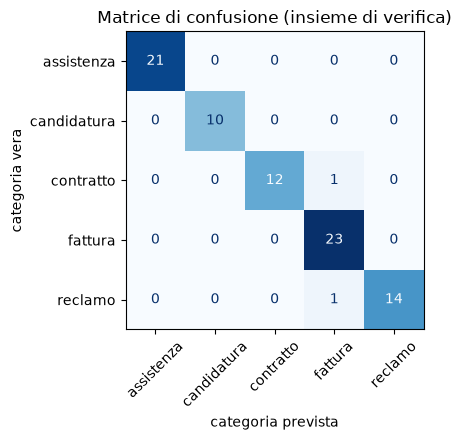

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

# output_dict=True ci restituisce i numeri in un dizionario, che trasformiamo in tabella.
rapporto = pd.DataFrame(classification_report(etichette_test, previsioni, output_dict=True, zero_division=0)).T
rapporto["support"] = rapporto["support"].astype(int)
display(rapporto.drop(index="accuracy").round(2))

# La MATRICE DI CONFUSIONE: righe = categoria vera, colonne = categoria prevista.
# Sulla diagonale ci sono le risposte esatte; ogni cella fuori diagonale è un tipo preciso di errore.
figura, asse = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(etichette_test, previsioni, ax=asse, cmap="Blues", colorbar=False,
                                        xticks_rotation=45)
asse.set_xlabel("categoria prevista")
asse.set_ylabel("categoria vera")
asse.set_title("Matrice di confusione (insieme di verifica)")
plt.tight_layout()
plt.show()

💡 **Come si legge la matrice di confusione.** Ogni riga è una categoria *vera*, ogni colonna una categoria *prevista*; la diagonale contiene le risposte esatte. Le celle fuori diagonale ci dicono **quali categorie il modello confonde tra loro**: ci aspettiamo che gli errori si concentrino tra categorie che condividono il lessico (reclami che citano una fattura o un ticket, segnalazioni che citano il contratto di manutenzione), cioè proprio sulle frasi «ibride» che abbiamo inserito nel corpus.

Ricordiamo l'avvertenza iniziale: questi numeri sono **ottimistici**, perché il corpus è sintetico. Su documenti reali, con lessico più vario e categorie dai confini sfumati, è normale partire da valori più bassi e migliorare per gradi.

## 4.5 Confrontare più modelli con la validazione incrociata

Con meno di cento documenti di verifica, **un singolo documento sbagliato sposta l'accuratezza di oltre un punto percentuale**: confrontare due modelli su un'unica divisione è poco affidabile. La **validazione incrociata** (*cross-validation*) dà una stima più stabile: si divide il corpus in *k* parti (qui 5); a turno, ciascuna parte fa da insieme di verifica mentre le altre quattro servono per l'addestramento; alla fine si fa la media dei 5 risultati. Ogni documento viene così usato per la verifica esattamente una volta.

Mettiamo a confronto tre algoritmi classici per il testo e tre varianti di rappresentazione:

| Algoritmo | In due righe |
|---|---|
| **Naive Bayes** | Modello probabilistico: stima quanto è probabile ogni parola in ciascuna categoria e assume, «ingenuamente» (*naive*), che le parole siano indipendenti tra loro. Rapidissimo, ottimo termine di paragone. |
| **Regressione logistica** | Lineare, produce probabilità, pesi ispezionabili (sezione 4.3). |
| **SVM lineare** (*Support Vector Machine*) | Lineare anch'essa: cerca il confine che separa le categorie con il **margine** più ampio possibile. Spesso è la più accurata sui testi; di base non fornisce probabilità. |

Come misura usiamo l'**F1 macro**, più severa dell'accuratezza quando le classi sono sbilanciate.

In [43]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC


def tokenizza_con_stemming(testo):
    """Tokenizzatore completo della sezione 2.9, con stemming attivo (toglie già le stop word)."""
    return tokenizza(testo, applica_stemming=True)


candidati = {
    "Bag-of-words + Regressione logistica": Pipeline([
        ("bow", CountVectorizer(token_pattern=TOKEN_PATTERN, stop_words=STOP_WORD_IT, ngram_range=(1, 2), min_df=2)),
        ("classificatore", LogisticRegression(C=10, max_iter=1000))]),
    "TF-IDF + Naive Bayes": Pipeline([
        ("tfidf", crea_vettorizzatore_tfidf()), ("classificatore", MultinomialNB(alpha=0.1))]),
    "TF-IDF + Regressione logistica": Pipeline([
        ("tfidf", crea_vettorizzatore_tfidf()), ("classificatore", LogisticRegression(C=10, max_iter=1000))]),
    "TF-IDF + SVM lineare": Pipeline([
        ("tfidf", crea_vettorizzatore_tfidf()), ("classificatore", LinearSVC(C=1))]),
    "TF-IDF con stemming + Regressione logistica": Pipeline([
        # tokenizer= sostituisce la tokenizzazione interna con la nostra funzione; token_pattern=None evita un avviso
        ("tfidf", TfidfVectorizer(tokenizer=tokenizza_con_stemming, token_pattern=None, lowercase=False,
                                  ngram_range=(1, 2), min_df=2)),
        ("classificatore", LogisticRegression(C=10, max_iter=1000))]),
}

# shuffle=True mescola i documenti prima di dividerli nelle 5 parti; stratificato come sopra.
divisione = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEME)
righe = []
for nome, pipeline_candidata in candidati.items():
    inizio = time.perf_counter()
    punteggi = cross_val_score(pipeline_candidata, testi, etichette, cv=divisione, scoring="f1_macro")
    righe.append({"modello": nome, "F1 macro (media)": punteggi.mean(), "deviazione std": punteggi.std(),
                  "tempo (s)": time.perf_counter() - inizio})

# ⭐ Se nella sezione 3.8 abbiamo calcolato gli embeddings neurali, li proviamo come feature al posto del TF-IDF.
if modello_embedding is not None:
    inizio = time.perf_counter()
    punteggi = cross_val_score(LogisticRegression(C=10, max_iter=1000), embeddings_neurali, etichette,
                               cv=divisione, scoring="f1_macro")
    righe.append({"modello": "Embeddings neurali + Regressione logistica", "F1 macro (media)": punteggi.mean(),
                  "deviazione std": punteggi.std(), "tempo (s)": time.perf_counter() - inizio})

confronto_modelli = pd.DataFrame(righe).set_index("modello").sort_values("F1 macro (media)", ascending=False)
confronto_modelli.round(3)

,F1 macro (media),deviazione std,tempo (s)
modello,,,
TF-IDF + SVM lineare,0.966,0.012,0.190
Bag-of-words + Regressione logistica,0.965,0.013,0.223
TF-IDF + Naive Bayes,0.963,0.016,0.171
TF-IDF + Regressione logistica,0.961,0.021,0.269
TF-IDF con stemming + Regressione logistica,0.961,0.021,0.256
Embeddings neurali + Regressione logistica,0.959,0.024,0.077


💡 **Come leggere il confronto.**

- La colonna **deviazione std** dice quanto il risultato oscilla tra le 5 prove: se la differenza tra due modelli è più piccola di questa oscillazione, **non è una vera differenza**. È facile «vedere» un vincitore dove c'è solo rumore.
- Sui testi, i modelli **lineari** sono molto vicini tra loro: la scelta si fa anche su altri criteri (servono le probabilità? serve ispezionare i pesi? quanto conta la velocità?).
- L'effetto dello **stemming** lo leggiamo direttamente nella tabella: coerentemente con quanto detto nella sezione 2.8, non è garantito che aiuti. Si misura, non si presume.

Nel seguito teniamo **TF-IDF + regressione logistica**: è tra i migliori, fornisce probabilità (ci serviranno tra poco) ed è ispezionabile.

## 4.6 Guardare dentro il modello: quali parole contano?

Un vantaggio dei modelli lineari è che possiamo **aprirli**: per ogni categoria, i termini con il peso più alto sono quelli che spingono di più verso quella categoria. Questo controllo non è una curiosità: è il modo per accorgersi se il modello ha imparato la cosa giusta o una **scorciatoia** (per esempio il nome di un cliente che, per caso, compare solo nei reclami).

In [44]:
vettorizzatore_modello = modello.named_steps["tfidf"]                 # i passi della Pipeline si recuperano per nome
classificatore = modello.named_steps["classificatore"]
termini_modello = vettorizzatore_modello.get_feature_names_out()

# coef_ è una matrice (n_categorie x n_termini): una riga di pesi per ciascuna categoria.
termini_per_categoria = {}
for categoria, pesi_categoria in zip(classificatore.classes_, classificatore.coef_):
    piu_pesanti = pesi_categoria.argsort()[::-1][:10]
    termini_per_categoria[categoria] = [termini_modello[i] for i in piu_pesanti]

pd.DataFrame(termini_per_categoria)

,assistenza,candidatura,contratto,fattura,reclamo
0,dopo,presso,contratto,fattura,reclamo
1,problema,candidatura,parti,totale,quanto
2,richiesta assistenza,resto,fornitore,importo,ricevuto
3,ripristinare,annuncio,firmata,pagamento,pratica
4,ripristinare servizio,resto disponibile,condizioni fornitura,pagare,subito
5,intervento,condizioni economiche,proposta rinnovo,totale pagare,effettuato
6,tecnico,economiche,rinnovo,euro,riguarda fattura
7,segnalazione,disponibile discutere,proposta,emessa,effettuato tramite
8,viene,decorrenza,servizio app,fattura emessa,reclamo riguarda
9,mattina,economiche decorrenza,mobile,totale fattura,pagamento effettuato


💡 I termini in cima alle colonne sono quelli che ci aspetteremmo (il lessico del pagamento per le fatture, quello del malcontento per i reclami…): il modello ha imparato il **linguaggio** di ogni categoria e non una scorciatoia. Se in una colonna comparisse il nome di una persona o di un'azienda, sarebbe un campanello d'allarme.

## 4.7 Analisi degli errori e soglia di confidenza

I numeri dicono *quanto* sbaglia il modello; per capire *perché*, e decidere come migliorarlo, bisogna **leggere i documenti sbagliati**. È il lavoro più utile che si possa fare su un classificatore.

C'è però un problema pratico: l'insieme di verifica è piccolo e gli errori al suo interno sono pochissimi, troppo pochi per ricavarne qualcosa. Usiamo allora lo stesso meccanismo della validazione incrociata, ma invece di farci restituire un punteggio ci facciamo restituire **le previsioni**: `cross_val_predict` addestra 5 modelli, e per ogni documento conserva la previsione del modello che **non lo ha visto** in addestramento (previsioni *fuori campione*). Otteniamo così una previsione onesta per **tutti** i documenti del corpus, e quindi molti più errori da studiare.

Con `method="predict_proba"` otteniamo, per ogni documento, la probabilità di ciascuna categoria. Chiamiamo **confidenza** la probabilità della categoria scelta: un valore vicino a 1 indica una decisione netta, un valore basso un documento su cui il modello è incerto.

In [45]:
from sklearn.model_selection import cross_val_predict

# Previsioni "fuori campione" per TUTTI i documenti: ognuno è giudicato da un modello che non lo ha mai visto.
probabilita = cross_val_predict(modello, testi, etichette, cv=divisione, method="predict_proba")
categorie = np.array(sorted(etichette.unique()))          # stesso ordine (alfabetico) delle colonne di probabilita

esiti = pd.DataFrame({
    "file": documenti["file"],
    "vera": etichette,
    "prevista": categorie[probabilita.argmax(axis=1)],     # la categoria con la probabilità più alta
    "confidenza": probabilita.max(axis=1).round(2),        # ... e il valore di quella probabilità
    "estratto": [estratto(t, 150) for t in documenti["testo_leggibile"]],
})
esatti = esiti["vera"] == esiti["prevista"]
errori = esiti[~esatti].sort_values("confidenza", ascending=False)

print(f"Documenti sbagliati: {len(errori)} su {len(esiti)}  (accuratezza fuori campione: {esatti.mean():.1%})")
print(f"Confidenza media sulle risposte esatte   : {esiti.loc[esatti, 'confidenza'].mean():.2f}")
print(f"Confidenza media sulle risposte sbagliate: {errori['confidenza'].mean():.2f}")

print("\nQuali categorie vengono confuse? (righe = categoria vera, colonne = categoria prevista)")
display(pd.crosstab(esiti["vera"], esiti["prevista"]))
print("I documenti sbagliati, dal più 'sicuro' al più incerto:")
errori

Documenti sbagliati: 11 su 326  (accuratezza fuori campione: 96.6%)
Confidenza media sulle risposte esatte   : 0.90
Confidenza media sulle risposte sbagliate: 0.56

Quali categorie vengono confuse? (righe = categoria vera, colonne = categoria prevista)


prevista,assistenza,candidatura,contratto,fattura,reclamo
vera,,,,,
assistenza,80,0,0,0,1
candidatura,0,40,1,0,0
contratto,0,3,45,3,0
fattura,0,0,2,90,0
reclamo,0,0,0,1,60


I documenti sbagliati, dal più 'sicuro' al più incerto:


,file,vera,prevista,confidenza,estratto
54,doc_0055.pdf,candidatura,contratto,0.71,Oggetto: Comunicazione del 04/02/2025 Si trasmette la documentazione rif. HR-2025-515 riguardante il servi...
70,doc_0071.pdf,contratto,fattura,0.67,Oggetto: Comunicazione del 04/08/2025 Contratto di servizio n. CTR-2025-5693: le parti concordano le condi...
161,doc_0162.pdf,contratto,candidatura,0.63,Oggetto: Condizioni di fornitura In riferimento alla pratica n. CTR-2025-3496 relativa al servizio Reporti...
119,doc_0120.pdf,reclamo,fattura,0.61,Oggetto: Comunicazione del 14/02/2026 Si trasmette la documentazione rif. REC-2026-8988 riguardante il ser...
125,doc_0126.pdf,contratto,candidatura,0.58,Oggetto: Comunicazione del 03/05/2026 In riferimento alla pratica n. CTR-2026-4680 relativa al servizio Ap...
32,doc_0033.pdf,assistenza,reclamo,0.55,Oggetto: Comunicazione del 29/08/2025 Facciamo seguito ai precedenti contatti sul servizio Portale Clienti...
177,doc_0178.pdf,contratto,fattura,0.54,Oggetto: Comunicazione del 19 maggio 2026 In riferimento alla pratica n. CTR-2026-3094 relativa al servizi...
288,doc_0289.pdf,fattura,contratto,0.54,Oggetto: Documentazione allegata Si trasmette la documentazione rif. FT-2026-37269 riguardante il servizio...
22,doc_0023.pdf,fattura,contratto,0.53,Oggetto: Comunicazione Si trasmette la documentazione rif. FT-2025-39227 riguardante il servizio Posta Cer...
260,doc_0261.pdf,contratto,fattura,0.43,Oggetto: Vostra richiesta Facciamo seguito ai precedenti contatti sul servizio Archivio Documentale (rif. ...


💡 **Che cosa ci dicono gli errori.**

- Si concentrano tra categorie **vicine**, che condividono parte del lessico (la tabella qui sopra dice quali: tipicamente fatture e contratti, che parlano entrambi di canoni e pagamenti). Sono i documenti brevi, con apertura generica o con contenuto misto, cioè gli stessi su cui esiterebbe anche una persona. Leggendo gli estratti ci si rende conto che alcune etichette sono **discutibili**: nei progetti reali, una parte degli «errori del modello» si rivela essere un errore (o un'ambiguità) dell'etichettatura.
- L'accuratezza fuori campione **non coincide** con quella misurata nella sezione 4.3 sull'unica divisione addestramento/verifica. Non è una contraddizione: con poche decine di documenti di verifica ogni errore in più o in meno sposta il risultato di oltre un punto, e una singola divisione può essere fortunata o sfortunata. È la dimostrazione pratica di quanto detto nella sezione 4.5: la stima ottenuta su tutto il corpus è quella di cui fidarsi.
- Gli errori hanno in media una **confidenza più bassa** delle risposte esatte.

Quest'ultimo fatto si può sfruttare con una politica molto usata in azienda, l'**automazione parziale** (in inglese *human in the loop*, «con una persona nel circuito»):

> se la confidenza supera una **soglia**, il documento viene smistato automaticamente; altrimenti finisce nella coda di **revisione manuale**.

La soglia è una decisione *di business*, non tecnica: alzandola aumenta la qualità di ciò che viene automatizzato, ma cresce il lavoro manuale. La tabella seguente mostra il compromesso.

> 🔧 **Da personalizzare — la soglia di confidenza.** Non esiste un valore giusto in generale: dipende da quanto costa un documento smistato male rispetto a un documento controllato a mano. Questa tabella, ricalcolata sui documenti veri, è lo strumento per deciderlo insieme a chi è responsabile del processo. Il valore scelto va poi riportato in `soglia_confidenza` (sezione 7.2).

In [46]:
righe = []
for soglia in [0.0, 0.5, 0.6, 0.7, 0.8, 0.9]:
    automatici = esiti[esiti["confidenza"] >= soglia]
    sbagliati_automatici = (automatici["vera"] != automatici["prevista"]).sum()
    righe.append({
        "soglia di confidenza": soglia,
        "smistati in automatico": f"{len(automatici) / len(esiti):.0%}",
        "da rivedere a mano": len(esiti) - len(automatici),
        "errori che sfuggono": sbagliati_automatici,
        "accuratezza sugli automatici": f"{1 - sbagliati_automatici / len(automatici):.1%}" if len(automatici) else "-",
    })
pd.DataFrame(righe).set_index("soglia di confidenza")

,smistati in automatico,da rivedere a mano,errori che sfuggono,accuratezza sugli automatici
soglia di confidenza,,,,
0.0,100%,0,11,96.6%
0.5,98%,6,9,97.2%
0.6,94%,20,4,98.7%
0.7,90%,33,1,99.7%
0.8,83%,56,0,100.0%
0.9,69%,100,0,100.0%


💡 La colonna da guardare è **errori che sfuggono**: sono gli smistamenti sbagliati che nessuno controllerà. Alzando la soglia diminuiscono, al prezzo di più documenti da rivedere a mano. Notiamo anche che qualche errore può sopravvivere a soglie alte: un modello può essere **sicuro e sbagliare**, quindi la soglia riduce il rischio ma non lo azzera (un controllo a campione sugli automatici resta una buona abitudine).

## 4.8 Classificare testi nuovi

Proviamo il modello su testi scritti al momento. Devono percorrere **la stessa strada** dei documenti di addestramento: normalizzazione (`normalizza_testo`) e poi `Pipeline`. Dimenticare la normalizzazione, o farla in modo diverso, è uno degli errori più comuni quando un modello passa dal notebook alla produzione.

In aula: modifichiamo le frasi, inventiamone di ambigue e osserviamo come cambia la confidenza.

In [47]:
testi_nuovi = [
    "Buongiorno, da ieri l'app non si apre più e compare un codice di errore. Potete intervenire?",
    "Vi ricordiamo che la fattura di marzo risulta ancora da saldare: attendiamo il bonifico entro dieci giorni.",
    "Sono laureata in matematica e vorrei propormi per il ruolo di analista: allego il curriculum.",
    "È la terza volta che vi scrivo: il pacco è arrivato rotto e voglio essere rimborsato subito!",
    "Il servizio non funziona da giorni nonostante il contratto preveda l'intervento in quattro ore: è inaccettabile.",
]
probabilita_nuovi = modello.predict_proba([normalizza_testo(t) for t in testi_nuovi])
risultati_nuovi = pd.DataFrame(probabilita_nuovi.round(2), columns=modello.classes_)
risultati_nuovi.insert(0, "categoria prevista", modello.classes_[probabilita_nuovi.argmax(axis=1)])
risultati_nuovi.insert(0, "testo", [t[:70] + "..." for t in testi_nuovi])
risultati_nuovi

,testo,categoria prevista,assistenza,candidatura,contratto,fattura,reclamo
0,"Buongiorno, da ieri l'app non si apre più e compare un codice di error...",assistenza,0.61,0.09,0.10,0.09,0.10
1,Vi ricordiamo che la fattura di marzo risulta ancora da saldare: atten...,fattura,0.17,0.08,0.08,0.55,0.12
2,Sono laureata in matematica e vorrei propormi per il ruolo di analista...,candidatura,0.19,0.43,0.10,0.14,0.14
3,È la terza volta che vi scrivo: il pacco è arrivato rotto e voglio ess...,reclamo,0.14,0.13,0.11,0.11,0.51
4,Il servizio non funziona da giorni nonostante il contratto preveda l'i...,assistenza,0.60,0.05,0.15,0.05,0.15


💡 L'ultima frase è volutamente **ambigua** (un problema tecnico, un contratto e un tono da reclamo): la probabilità si distribuisce su più categorie e la confidenza cala. È il comportamento desiderabile: un buon modello *sa di non sapere*.

## 4.9 ⭐ Regolare le «manopole» in modo sistematico: la ricerca a griglia

Finora i valori di `C`, `ngram_range` e `min_df` li abbiamo scelti a buon senso. Questi valori, che **non** vengono imparati dai dati ma decisi da noi, si chiamano **iperparametri**. `GridSearchCV` prova tutte le combinazioni di una griglia di valori, valuta ciascuna con la validazione incrociata e tiene la migliore. I nomi dei parametri seguono la convenzione `nomepasso__nomeparametro` (con due *underscore*), dove il nome del passo è quello dato nella `Pipeline`.

⚠️ La ricerca si fa **solo sui dati di addestramento**: l'insieme di verifica va toccato una volta sola, alla fine, altrimenti anche la scelta degli iperparametri diventa una forma di *leakage*.

In [48]:
from sklearn.model_selection import GridSearchCV

griglia = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],          # solo parole singole, oppure anche bigrammi
    "tfidf__min_df": [1, 2, 5],                      # quante volte deve comparire un termine per essere considerato
    "classificatore__C": [1, 10, 100],               # forza della regolarizzazione
}
ricerca = GridSearchCV(
    Pipeline([("tfidf", crea_vettorizzatore_tfidf()), ("classificatore", LogisticRegression(max_iter=1000))]),
    param_grid=griglia, scoring="f1_macro", cv=divisione)

inizio = time.perf_counter()
ricerca.fit(testi_train, etichette_train)
print(f"Provate {len(ricerca.cv_results_['params'])} combinazioni x 5 parti in {time.perf_counter() - inizio:.1f} s")
print(f"Combinazione migliore : {ricerca.best_params_}")
print(f"F1 macro in validazione incrociata: {ricerca.best_score_:.3f}")
print(f"Accuratezza sull'insieme di verifica (usato UNA volta, alla fine): "
      f"{accuracy_score(etichette_test, ricerca.predict(testi_test)):.1%}")

Provate 18 combinazioni x 5 parti in 3.1 s
Combinazione migliore : {'classificatore__C': 1, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}
F1 macro in validazione incrociata: 0.948
Accuratezza sull'insieme di verifica (usato UNA volta, alla fine): 93.9%


💡 **Un risultato da leggere con onestà.** Confrontiamo questa accuratezza con quella del modello della sezione 4.3, i cui iperparametri avevamo scelto a buon senso: può essere più alta, uguale o anche **più bassa**. Non è un difetto della ricerca a griglia: con poche centinaia di documenti le differenze tra combinazioni vicine sono più piccole dell'oscillazione dovuta al caso, e la «migliore» in validazione incrociata non è necessariamente la migliore sui documenti nuovi. La ricerca sistematica ripaga quando i dati sono migliaia; con pochi dati, valori ragionevoli e un modello semplice sono una scelta più che difendibile.

---
# 5. Clustering: raggruppare i documenti senza etichette

*Tempo indicativo: 15 minuti. Terzo punto del programma (seconda parte).*

## 5.1 Quando non abbiamo le etichette

Nella sezione 4 avevamo un vantaggio enorme: qualcuno aveva già etichettato i documenti. In un archivio reale spesso **le etichette non ci sono**, e crearle costa. Il **clustering** (raggruppamento) è la tecnica di **apprendimento non supervisionato** per eccellenza: l'algoritmo riceve solo i vettori dei documenti e cerca da solo dei **gruppi** (*cluster*) di documenti simili tra loro.

A che cosa serve in pratica:

- **esplorare** un archivio sconosciuto: «di che cosa parlano questi 200.000 PDF?»;
- **proporre le categorie** di una futura classificazione, invece di deciderle a tavolino;
- **etichettare in blocco**: si guarda un gruppo, gli si dà un nome, e in pochi minuti si ottengono centinaia di esempi etichettati con cui addestrare un classificatore.

⚠️ Una differenza di fondo rispetto alla classificazione: nel clustering **non esiste una risposta giusta**. L'algoritmo trova *dei* gruppi, non necessariamente *i nostri*: potrebbe raggruppare per argomento, ma anche per lunghezza del documento o per mittente. Il risultato va sempre **interpretato da una persona**.

## 5.2 K-Means in breve

**K-Means** è l'algoritmo di clustering più diffuso. Gli diciamo quanti gruppi vogliamo (`k`) e lui procede così:

1. sceglie `k` punti di partenza, i **centroidi** (il centroide è il «baricentro» di un gruppo: la media dei suoi vettori);
2. assegna ogni documento al centroide più vicino;
3. ricalcola ogni centroide come media dei documenti che gli sono stati assegnati;
4. ripete i passi 2 e 3 finché le assegnazioni non cambiano più.

Due dettagli pratici:

- **Su quali vettori?** Usiamo gli embeddings **LSA** della sezione 3.7 (30 dimensioni dense, già normalizzati a lunghezza 1). K-Means misura la distanza «in linea d'aria» (euclidea), che su migliaia di dimensioni sparse funziona male; su vettori di lunghezza 1, invece, distanza euclidea e similarità del coseno **ordinano i documenti allo stesso modo**, quindi stiamo di fatto raggruppando per coseno.
- **Il risultato dipende dai punti di partenza.** Per questo si fanno più tentativi (`n_init=10`) e si tiene il migliore, e si fissa `random_state` per avere risultati riproducibili.

## 5.3 Quanti gruppi? Il coefficiente di silhouette

`k` dobbiamo sceglierlo noi, e senza etichette non possiamo misurare un'accuratezza. Una misura molto usata è il **coefficiente di silhouette**, che per ogni documento confronta due distanze: quella media dai documenti **del proprio gruppo** e quella media dai documenti **del gruppo vicino più prossimo**. Il valore va da −1 a +1:

- vicino a **+1**: il documento è ben dentro il suo gruppo e lontano dagli altri;
- vicino a **0**: è sul confine tra due gruppi;
- **negativo**: probabilmente è nel gruppo sbagliato.

Proviamo diversi valori di `k` e guardiamo la silhouette media. È un'**indicazione**, non un verdetto: va sempre incrociata con il buon senso e con la lettura dei gruppi.

> 🔧 **Da personalizzare — l'intervallo dei valori di k.** `range(2, 10)` basta per il nostro piccolo corpus. Su un archivio vero, con decine di tipi di documento, l'intervallo va allargato (per esempio da 5 a 50, a passi di 5); per contenere i tempi, la silhouette si può calcolare su un campione di documenti (`silhouette_score` ha per questo il parametro `sample_size`).

c:\Users\Utente\miniconda3\envs\corso-python-TM\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Utente\miniconda3\envs\corso-python-TM\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Utente\miniconda3\envs\corso-python-TM\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Utente\miniconda3\envs\corso-python-TM\Lib\site-packages\s

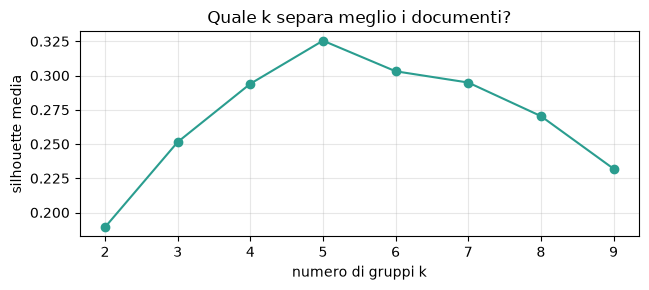

Silhouette media per k: {2: 0.189, 3: 0.251, 4: 0.294, 5: 0.325, 6: 0.303, 7: 0.295, 8: 0.27, 9: 0.232}
Il valore più alto si ottiene con k = 5


In [49]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

valori_k = list(range(2, 10))
silhouette_per_k = []
for k in valori_k:
    # n_init=10: dieci tentativi con punti di partenza diversi, si tiene il migliore.
    gruppi_k = KMeans(n_clusters=k, n_init=10, random_state=SEME).fit_predict(embeddings_lsa)
    silhouette_per_k.append(silhouette_score(embeddings_lsa, gruppi_k, metric="cosine"))

figura, asse = plt.subplots(figsize=(6.5, 3))
asse.plot(valori_k, silhouette_per_k, marker="o", color="#2a9d8f")
asse.set_xlabel("numero di gruppi k")
asse.set_ylabel("silhouette media")
asse.set_title("Quale k separa meglio i documenti?")
asse.grid(alpha=0.3)
plt.tight_layout()
plt.show()

k_migliore = valori_k[int(np.argmax(silhouette_per_k))]
print("Silhouette media per k:", {k: round(s, 3) for k, s in zip(valori_k, silhouette_per_k)})
print(f"Il valore più alto si ottiene con k = {k_migliore}")

💡 Sul nostro corpus la curva ha un massimo netto, e coincide con il numero di categorie che sappiamo esistere. Su un archivio reale la curva è di solito **più piatta e più ambigua**: capita che più valori di `k` siano quasi equivalenti, e la scelta si fa leggendo i gruppi (un `k` più alto dà gruppi più fini, per esempio *solleciti* distinti dalle *fatture*).

## 5.4 Dare un nome ai gruppi e confrontarli con le categorie vere

Un gruppo è solo un numero (0, 1, 2…): per capire **di che cosa parla** guardiamo i suoi termini più caratteristici. Il modo più trasparente è calcolare, per ogni gruppo, il **peso TF-IDF medio** di ciascun termine tra i suoi documenti e prendere i primi della lista.

In [50]:
kmeans = KMeans(n_clusters=k_migliore, n_init=10, random_state=SEME)
documenti["gruppo"] = kmeans.fit_predict(embeddings_lsa)

# Per ogni gruppo: media dei vettori TF-IDF dei suoi documenti -> i termini con la media più alta lo descrivono.
solo_parole_singole = np.array([" " not in termine for termine in termini])      # tralasciamo i bigrammi
descrizioni = []
for gruppo in range(k_migliore):
    righe_del_gruppo = np.flatnonzero(documenti["gruppo"].to_numpy() == gruppo)  # posizioni dei documenti del gruppo
    peso_medio = np.asarray(matrice_tfidf[righe_del_gruppo].mean(axis=0)).ravel()
    peso_medio[~solo_parole_singole] = 0
    migliori = peso_medio.argsort()[::-1][:8]
    descrizioni.append({"gruppo": gruppo, "documenti": len(righe_del_gruppo),
                        "termini più caratteristici": ", ".join(termini[migliori])})
pd.DataFrame(descrizioni).set_index("gruppo")

c:\Users\Utente\miniconda3\envs\corso-python-TM\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,documenti,termini più caratteristici
gruppo,,
0,89,"fattura, pagamento, importo, bonifico, euro, totale, tramite, iva"
1,42,"resto, dati, candidatura, presso, invio, disponibile, documentazione, decorrenza"
2,61,"quanto, ricevuto, reclamo, servizio, volte, non, giorni, subito"
3,55,"contratto, parti, parte, servizio, fornitore, canone, dati, firmata"
4,79,"dopo, problema, non, errore, servizio, tecnico, viene, ripristinare"


Leggendo i termini riusciamo a dare un nome a ogni gruppo **senza aver letto un solo documento**. Dato che, eccezionalmente, qui conosciamo le categorie vere, possiamo anche verificare quanto i gruppi trovati coincidano con esse. Due strumenti:

- la **tabella di contingenza** (`pd.crosstab`): righe = categorie vere, colonne = gruppi trovati;
- l'**Adjusted Rand Index** (ARI): un numero che misura l'accordo tra due suddivisioni degli stessi oggetti, senza badare ai *nomi* dei gruppi. Vale **1** se le due suddivisioni coincidono e circa **0** se l'accordo è quello che si otterrebbe a caso.

In [51]:
from sklearn.metrics import adjusted_rand_score

display(pd.crosstab(documenti["categoria"], documenti["gruppo"]))
print(f"Adjusted Rand Index tra gruppi trovati e categorie vere: "
      f"{adjusted_rand_score(documenti['categoria'], documenti['gruppo']):.2f}")

gruppo,0,1,2,3,4
categoria,,,,,
assistenza,0,0,2,0,79
candidatura,0,39,0,2,0
contratto,0,3,0,48,0
fattura,87,0,0,5,0
reclamo,2,0,59,0,0


Adjusted Rand Index tra gruppi trovati e categorie vere: 0.90


💡 Ogni categoria finisce in larga parte in un solo gruppo: l'algoritmo ha ritrovato **da solo**, senza alcuna etichetta, una struttura molto vicina alla nostra. I documenti «fuori posto» sono in buona parte gli stessi che mettevano in difficoltà il classificatore (brevi, generici o misti). Ricordiamo però che su dati reali il risultato è meno pulito e che, senza le categorie vere, questa verifica **non è possibile**: resta la lettura dei gruppi.

Un grafico aiuta l'intuizione. Non possiamo disegnare 30 dimensioni, quindi **proiettiamo** i documenti sulle 2 dimensioni latenti più importanti (una nuova SVD con 2 componenti). È una semplificazione drastica: gruppi che nel disegno appaiono sovrapposti possono essere ben separati nelle altre 28 dimensioni. Nei due disegni i punti sono gli stessi: i documenti che **cambiano colore** passando da sinistra a destra sono quelli che K-Means ha messo in un gruppo diverso dalla loro categoria.

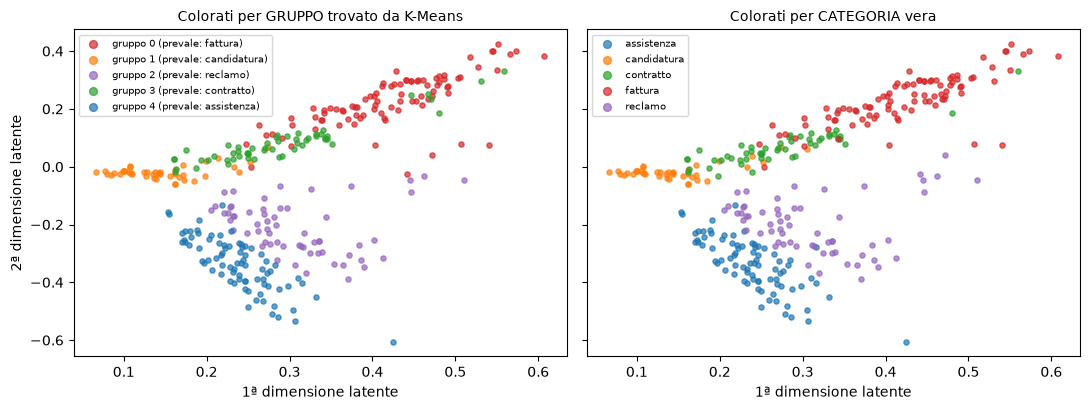

In [52]:
coordinate = TruncatedSVD(n_components=2, random_state=SEME).fit_transform(matrice_tfidf)

# Un colore fisso per ogni categoria. Per rendere confrontabili i due disegni, ogni GRUPPO prende il colore
# della categoria che vi prevale (usiamo le etichette vere solo per colorare: K-Means non le ha mai viste).
colore_categoria = {categoria: plt.cm.tab10(i) for i, categoria in enumerate(sorted(documenti["categoria"].unique()))}
prevalente = documenti.groupby("gruppo")["categoria"].agg(lambda valori: valori.value_counts().index[0])

figura, assi = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True, sharey=True)
for gruppo, categoria_prevalente in prevalente.items():
    selezione = (documenti["gruppo"] == gruppo).to_numpy()
    assi[0].scatter(coordinate[selezione, 0], coordinate[selezione, 1], s=14, alpha=0.7,
                    color=colore_categoria[categoria_prevalente], label=f"gruppo {gruppo} (prevale: {categoria_prevalente})")
for categoria, colore in colore_categoria.items():
    selezione = (documenti["categoria"] == categoria).to_numpy()
    assi[1].scatter(coordinate[selezione, 0], coordinate[selezione, 1], s=14, alpha=0.7, color=colore, label=categoria)
assi[0].set_title("Colorati per GRUPPO trovato da K-Means", fontsize=10)
assi[1].set_title("Colorati per CATEGORIA vera", fontsize=10)
assi[0].set_ylabel("2ª dimensione latente")
for asse in assi:
    asse.set_xlabel("1ª dimensione latente")
    asse.legend(fontsize=7.5, markerscale=1.5)
plt.tight_layout()
plt.show()

**Sui grandi volumi.** K-Means classico rilegge tutti i documenti a ogni passo. La variante `MiniBatchKMeans` (stessa interfaccia, stesso modulo `sklearn.cluster`) aggiorna i centroidi usando piccoli campioni casuali: è molto più veloce e consuma poca memoria, con una perdita di qualità di solito trascurabile. Una strategia comune è determinare i centroidi su un campione di qualche decina di migliaia di documenti e poi **assegnare** tutti gli altri con `predict`.

## 5.5 ⭐ Un uso concreto della similarità: scovare i quasi-duplicati

Negli archivi aziendali i **quasi-duplicati** abbondano: solleciti, reinvii, la stessa lettera con data e protocollo diversi. Occupano spazio, falsano le statistiche e, come visto nella sezione 4.1, possono gonfiare le prestazioni di un classificatore. Con i vettori TF-IDF individuarli è immediato: due documenti quasi identici hanno **coseno vicino a 1**.

Nel nostro corpus ne abbiamo nascosti 6 (colonna `quasi_duplicato_di` dell'indice): vediamo se li ritroviamo.

> 🔧 **Da personalizzare — la soglia dei duplicati.** `SOGLIA_DUPLICATI = 0.95` qui non è critica, perché le copie sono identiche agli originali. Su documenti reali va scelta guardando un campione di coppie a vari livelli di similarità. Con più di qualche decina di migliaia di documenti, inoltre, la matrice di tutte le similarità non sta in memoria: servono le tecniche indicate alla fine della sezione.

In [53]:
# Tutte le similarità tra coppie di documenti in un colpo solo: prodotto tra la matrice TF-IDF e la sua trasposta.
similarita = (matrice_tfidf @ matrice_tfidf.T).toarray()
# Teniamo solo le coppie (i, j) con i < j: np.triu azzera la diagonale (ogni documento con se stesso)
# e la metà inferiore (le stesse coppie in ordine inverso).
similarita = np.triu(similarita, k=1)

SOGLIA_DUPLICATI = 0.95
coppie = np.argwhere(similarita >= SOGLIA_DUPLICATI)
trovati = pd.DataFrame({
    "documento A": documenti.loc[coppie[:, 0], "file"].to_numpy(),
    "documento B": documenti.loc[coppie[:, 1], "file"].to_numpy(),
    "similarità": similarita[coppie[:, 0], coppie[:, 1]].round(3),
}).sort_values("similarità", ascending=False)

# Verità di riferimento: le coppie dichiarate nell'indice (l'ordine dei due file non conta -> frozenset)
coppie_vere = {frozenset(coppia) for coppia in
               documenti.loc[documenti["quasi_duplicato_di"].notna(), ["file", "quasi_duplicato_di"]].to_numpy()}
coppie_trovate = {frozenset(coppia) for coppia in trovati[["documento A", "documento B"]].to_numpy()}
trovati["duplicato vero?"] = [frozenset(coppia) in coppie_vere
                              for coppia in trovati[["documento A", "documento B"]].to_numpy()]

print(f"Coppie con similarità >= {SOGLIA_DUPLICATI}: {len(trovati)}")
print(f"Duplicati veri ritrovati: {len(coppie_vere & coppie_trovate)} su {len(coppie_vere)}")
trovati

Coppie con similarità >= 0.95: 6
Duplicati veri ritrovati: 6 su 6


,documento A,documento B,similarità,duplicato vero?
0,doc_0036.pdf,doc_0152.pdf,1.0,True
1,doc_0059.pdf,doc_0285.pdf,1.0,True
2,doc_0076.pdf,doc_0219.pdf,1.0,True
3,doc_0077.pdf,doc_0151.pdf,1.0,True
4,doc_0122.pdf,doc_0280.pdf,1.0,True
5,doc_0209.pdf,doc_0235.pdf,1.0,True


💡 **Che cosa osserviamo.** I duplicati nascosti vengono ritrovati tutti, con similarità pari a 1: le copie differiscono dall'originale solo per il numero del documento, e i codici li abbiamo **eliminati in fase di normalizzazione** (sezione 2.5). Per il TF-IDF sono quindi testi identici. È un buon esempio di come le scelte di pulizia influenzino tutto ciò che viene dopo: qui ci aiutano, ma se volessimo distinguere un sollecito dall'originale dovremmo confrontare anche i campi estratti (sezione 6). Notiamo anche che la coppia successiva in classifica è molto più in basso: la soglia 0,95 non è quindi critica. Su documenti reali il confine è meno netto e la soglia va scelta guardando un campione di coppie.

**Sui grandi volumi.** Confrontare *tutte* le coppie costa `n²` operazioni: con i nostri 326 documenti sono circa 53.000 confronti, con un milione di documenti sarebbero 500 miliardi. Per la deduplicazione su larga scala si usano tecniche di **hashing sensibile alla similarità** (*MinHash* e *LSH*, *Locality-Sensitive Hashing*), che mettono nello stesso «secchio» i documenti probabilmente simili e confrontano solo quelli. Per i duplicati **esatti** basta molto meno: un'impronta (*hash*, per esempio SHA-256) del testo pulito.

---
# 6. Estrazione di informazioni: dal testo libero ai campi di una tabella

*Tempo indicativo: 20 minuti. Terzo punto del programma (terza parte).*

## 6.1 Due famiglie di tecniche

Classificazione e clustering ci dicono **di che tipo** è un documento. L'**estrazione di informazioni** (*information extraction*) risponde a un'altra domanda: **quali dati contiene?** Numero del documento, data, importo, IBAN, mittente… L'obiettivo è riempire le colonne di una tabella a partire da testo libero, cioè trasformare dati non strutturati in dati strutturati.

| Famiglia | Adatta a… | Esempi | Pregi e difetti |
|---|---|---|---|
| **Regole** (espressioni regolari) | dati riconoscibili dalla loro **forma** | date, importi, codici, e-mail, IBAN, partite IVA | Precise, velocissime, spiegabili, nessun addestramento. Fragili davanti a formati non previsti. |
| **Modelli** (NER, LLM) | dati riconoscibili dal **contesto** | nomi di persone, aziende, luoghi; «chi deve pagare chi» | Flessibili. Richiedono un modello, sono più lenti e sbagliano in modi meno prevedibili. |

In pratica si combinano: regole dove la forma è chiara, modelli per il resto, e **controlli di validità** su tutto ciò che si estrae.

⚠️ Lavoriamo sul **`testo_leggibile`**, non su quello normalizzato: qui maiuscole, cifre e punteggiatura sono esattamente ciò che ci serve (sezione 2.1).

## 6.2 Un'espressione regolare per ogni campo

Le regex diventano presto illeggibili. Python offre un rimedio prezioso: con l'opzione `re.VERBOSE` spazi e a capo dentro l'espressione vengono ignorati e si possono inserire **commenti**, così ogni pezzo può essere spiegato sul posto. Costruiamo gli estrattori uno alla volta.

> 🔧 **Da personalizzare — le espressioni regolari dei campi.** È la parte più legata ai documenti: `RE_NUMERO_DOCUMENTO` elenca le *nostre* sigle; `SCHEMA_DATA` e `SCHEMA_IMPORTO` coprono le scritture presenti nel *nostro* corpus (mancano, per esempio, le date come `12-03-26` o `12.03.2026` e gli importi senza decimali). Si riusa la **struttura** (uno schema per tipo di dato, una funzione che converte, un controllo di validità); le regole si riscrivono una per una, partendo da esempi veri e da casi di prova, come negli esercizi.

In [54]:
from decimal import Decimal

# --- NUMERO DEL DOCUMENTO -------------------------------------------------------------------------------
RE_NUMERO_DOCUMENTO = re.compile(r"""
    \b(?:FT|CTR|TCK|REC|HR)     # una delle sigle previste; (?: ... ) raggruppa senza catturare
    -(?:\d{4}-)?                # trattino e, per alcune sigle, l'anno seguito da un altro trattino (FT-2026-)
    \d{3,6}\b                   # il progressivo: da 3 a 6 cifre, poi un confine di parola
""", re.VERBOSE)

# --- DATE: due scritture diverse ------------------------------------------------------------------------
# Teniamo lo schema della data in una stringa a parte, perché lo riuseremo dentro espressioni più grandi.
NUMERO_DEL_MESE = {nome: numero for numero, nome in enumerate(MESI, start=1)}       # {'gennaio': 1, ...}
SCHEMA_DATA = r"""
    \b(?P<giorno>\d{1,2})                       # giorno: una o due cifre. (?P<nome> ... ) è un gruppo CON NOME
    (?:
        /(?P<mese_numero>\d{1,2})/              #   forma numerica:  12/03/2026
      |                                         #   oppure
        \s+(?P<mese_nome>(?i:""" + "|".join(MESI) + r"""))\s+   #   forma estesa: 12 marzo 2026 ((?i: ... ) = ignora maiuscole/minuscole)
    )
    (?P<anno>\d{4})\b
"""
RE_DATA = re.compile(SCHEMA_DATA, re.VERBOSE)


def data_in_formato_iso(corrispondenza):
    """Da un risultato di RE_DATA alla data in formato ISO 'AAAA-MM-GG' (None se la data non esiste)."""
    mese = corrispondenza["mese_numero"] or NUMERO_DEL_MESE[corrispondenza["mese_nome"].lower()]
    try:
        return date(int(corrispondenza["anno"]), int(mese), int(corrispondenza["giorno"])).isoformat()
    except ValueError:                           # per esempio 31/02/2026: la forma è giusta, la data no
        return None


# --- IMPORTI --------------------------------------------------------------------------------------------
SCHEMA_IMPORTO = r"\d{1,3}(?:\.\d{3})*,\d{2}"   # 1.234,56: gruppi di tre cifre separati da punti, virgola, due decimali
RE_IMPORTO = re.compile(SCHEMA_IMPORTO)


def importo_in_decimale(testo_importo):
    """'1.234,56' -> Decimal('1234.56').

    Per il denaro usiamo Decimal e non float: i float sono binari e non rappresentano esattamente
    i centesimi (0.1 + 0.2 != 0.3), e negli importi gli errori di arrotondamento non sono accettabili."""
    return Decimal(testo_importo.replace(".", "").replace(",", "."))


# --- IBAN: riusiamo RE_IBAN dell'esercizio 1 e aggiungiamo il CONTROLLO DI VALIDITÀ -----------------------
def iban_formalmente_valido(iban):
    """Controllo internazionale 'modulo 97': scova quasi tutti gli errori di battitura.
    Si spostano i primi 4 caratteri in fondo, si convertono le lettere in numeri (A=10 ... Z=35)
    e il numero che ne risulta, diviso per 97, deve dare resto 1."""
    compatto = re.sub(r"\s+", "", iban).upper()
    if not re.fullmatch(r"IT\d{2}[A-Z]\d{10}[A-Z0-9]{12}", compatto):
        return False
    numerico = "".join(str(int(carattere, 36)) for carattere in compatto[4:] + compatto[:4])
    return int(numerico) % 97 == 1


prova = "Torino, 12 marzo 2026. Fattura n. FT-2026-00123, scadenza 11/04/2026. Totale da pagare: € 1.220,00."
print("Numero documento:", RE_NUMERO_DOCUMENTO.findall(prova))
print("Date            :", [data_in_formato_iso(c) for c in RE_DATA.finditer(prova)])
print("Importi         :", [importo_in_decimale(i) for i in RE_IMPORTO.findall(prova)])
print("IBAN valido?    :", iban_formalmente_valido("IT60 X054 2811 1010 0000 0123 456"),
      "| con una cifra sbagliata:", iban_formalmente_valido("IT60 X054 2811 1010 0000 0123 457"))

Numero documento: ['FT-2026-00123']
Date            : ['2026-03-12', '2026-04-11']
Importi         : [Decimal('1220.00')]
IBAN valido?    : True | con una cifra sbagliata: False


## 6.3 Prima versione: «prendiamo il primo che troviamo»

Riuniamo gli estrattori in una funzione che da un testo restituisce un dizionario di campi. Quando un documento contiene **più valori** dello stesso tipo (più date, più codici, più importi) serve una regola per scegliere. Partiamo dalla regola più semplice che viene in mente, e che è anche quella che un assistente AI propone quasi sempre al primo colpo: **vale il primo che compare**.

In [55]:
def estrai_campi_ingenuo(testo_leggibile):
    """PRIMA VERSIONE: per ogni campo prendiamo il primo valore che ha la forma giusta. I campi assenti valgono None."""
    numero = RE_NUMERO_DOCUMENTO.search(testo_leggibile)
    prima_data = next((data_in_formato_iso(c) for c in RE_DATA.finditer(testo_leggibile)), None)
    importo = RE_IMPORTO.search(testo_leggibile)
    email = RE_EMAIL.search(testo_leggibile)
    iban = RE_IBAN.search(testo_leggibile)
    iban_compatto = re.sub(r"\s+", "", iban.group()) if iban else None
    return {
        "numero_documento": numero.group() if numero else None,
        "data_documento": prima_data,
        "importo_totale": float(importo_in_decimale(importo.group())) if importo else None,
        "email": email.group() if email else None,
        "iban": iban_compatto,
        "iban_valido": iban_formalmente_valido(iban_compatto) if iban_compatto else None,
    }


# .apply(...) produce un dizionario per riga; pd.DataFrame(... .tolist()) trasforma i dizionari in colonne.
campi_ingenui = pd.DataFrame(documenti["testo_leggibile"].apply(estrai_campi_ingenuo).tolist(), index=documenti.index)
campi_ingenui.head()

,numero_documento,data_documento,importo_totale,email,iban,iban_valido
0,FT-2026-88347,2026-02-04,3960.57,stefano.bruno@sigmaconsulting.example,IT41F1402612624165460975402,True
1,FT-2026-52184,2026-05-28,6661.67,elena.ricci@sigmaconsulting.example,IT88V1560898017490613131976,True
2,HR-2025-405,2025-11-10,355.97,stefano.bruno@deltaassicurazioni.example,NaN,None
3,TCK-112617,2026-06-14,NaN,elena.ricci@alfasistemi.example,NaN,None
4,TCK-158904,2025-02-16,NaN,giulia.bianchi@sigmaconsulting.example,NaN,None


## 6.4 Quanto possiamo fidarci? Misuriamo contro la verità di riferimento

A guardare le prime righe sembra tutto a posto. Ma un estrattore non si giudica «a occhio» su cinque esempi: si **misura**. Per ogni campo confrontiamo il valore estratto con quello vero conservato nell'indice. Un campo conta come corretto anche quando è giustamente **assente** (per esempio l'importo totale in un contratto): un estrattore che «inventa» un valore dove non c'è sbaglia tanto quanto uno che non lo trova.

In [56]:
CAMPI = ["numero_documento", "data_documento", "importo_totale", "email", "iban", "iban_valido"]


def uguali(estratto, vero):
    """Confronto tra valore estratto e valore vero, che tratta None e NaN come 'assente'."""
    if pd.isna(estratto) or pd.isna(vero):
        return bool(pd.isna(estratto) and pd.isna(vero))
    if isinstance(vero, float):
        return abs(float(estratto) - vero) < 0.005            # importi: uguali al centesimo
    return str(estratto) == str(vero)


def misura_estrazione(campi_estratti, verita):
    """Per ogni campo: in quanti documenti il valore estratto coincide con quello vero."""
    righe, esiti = [], {}
    for campo in CAMPI:
        esiti[campo] = pd.Series([uguali(e, v) for e, v in zip(campi_estratti[campo], verita[campo])],
                                 index=verita.index)
        righe.append({"campo": campo, "presente in (documenti)": int(verita[campo].notna().sum()),
                      "errori": int((~esiti[campo]).sum()), "esattezza": f"{esiti[campo].mean():.1%}"})
    return pd.DataFrame(righe).set_index("campo"), esiti


tabella_ingenua, esiti_ingenui = misura_estrazione(campi_ingenui, documenti)
tabella_ingenua

,presente in (documenti),errori,esattezza
campo,,,
numero_documento,326,13,96.0%
data_documento,326,11,96.6%
importo_totale,92,60,81.6%
email,326,0,100.0%
iban,32,0,100.0%
iban_valido,32,0,100.0%


I campi che hanno **una sola occorrenza possibile** (e-mail del mittente, IBAN) vanno bene; quelli in cui bisogna **scegliere tra più candidati** no. Come per il classificatore, il passo più utile è **leggere gli errori**: guardiamo un esempio per ciascun campo problematico.

In [57]:
for campo in ["importo_totale", "data_documento", "numero_documento"]:
    sbagliati = documenti.index[~esiti_ingenui[campo]]
    if len(sbagliati) == 0:
        continue
    # Tra i documenti sbagliati scegliamo il più corto: si legge per intero in pochi secondi.
    i = min(sbagliati, key=lambda posizione: len(documenti.loc[posizione, "testo_leggibile"]))
    print(f"--- {campo}: {len(sbagliati)} errori. Esempio: {documenti.loc[i, 'file']} ({documenti.loc[i, 'categoria']})")
    print(f"    estratto: {campi_ingenui.loc[i, campo]}    vero: {documenti.loc[i, campo]}")
    print(textwrap.fill(documenti.loc[i, "testo_leggibile"], width=110,
                        initial_indent="    ", subsequent_indent="    "), "\n")

--- importo_totale: 60 errori. Esempio: doc_0117.pdf (fattura)
    estratto: 1855.96    vero: 2264.27
    Data: 26/09/2025 Mittente: Sara Gallo - Alfa Sistemi S.r.l. - sara.gallo@alfasistemi.example Oggetto:
    Comunicazione Fattura n. FT-2025-22773 emessa per il canone periodico del servizio Posta Certificata.
    L'imponibile ammonta a 1.855,96 euro, a cui si aggiunge l'IVA al 22% pari a 408,31 euro. In caso di
    ritardato pagamento saranno applicati gli interessi di mora previsti dalla legge. Totale fattura: 2.264,27
    euro. In attesa di un cortese riscontro, porgiamo i nostri migliori saluti. 

--- data_documento: 11 errori. Esempio: doc_0299.pdf (fattura)
    estratto: 2026-01-30    vero: 2025-12-31
    Mittente: Marta De Luca - Sigma Consulting S.r.l. - marta.de.luca@sigmaconsulting.example Oggetto:
    Documentazione allegata Si trasmette in allegato la fattura n. FT-2025-83585 relativa alla fornitura del
    servizio Fatturazione Online. Si prega di indicare nella causale 

💡 **Che cosa impariamo dagli errori.** Tre difetti diversi, tutti figli della stessa scorciatoia:

- **Importo**: il primo numero «a forma di importo» è spesso l'imponibile, o il canone di un contratto, o un rimborso richiesto. Nei documenti che non sono fatture l'estrattore **inventa** un totale che non esiste.
- **Data**: quando la lettera porta luogo e data **in fondo**, la prima data che si incontra è una scadenza o una data citata nell'oggetto.
- **Numero**: quando l'oggetto cita **un altro documento** (il reclamo che contesta una fattura), il primo codice è quello del documento citato.

## 6.5 Seconda versione: sfruttare il contesto

La cura è la stessa in tutti e tre i casi: non basta la **forma** del dato, serve il **contesto** in cui compare.

| Campo | Regola ingenua | Regola migliorata |
|---|---|---|
| Importo totale | il primo importo | l'importo **ancorato** alle parole che lo introducono (*Totale da pagare*, *Totale fattura*, *Importo totale dovuto*) |
| Data del documento | la prima data | la data introdotta da `Data:` oppure da «Luogo, » (come in `Torino, 12 marzo 2026`); solo in mancanza, la prima data |
| Numero del documento | il primo codice | il primo codice **con la sigla coerente con la categoria** del documento (`REC-` per un reclamo…): è un esempio di come i passi di una pipeline si aiutano a vicenda |

> 🔧 **Da personalizzare — le regole di contesto.** Le formule di `RE_IMPORTO_TOTALE` (*Totale da pagare*, *Totale fattura*…), i modi di introdurre la data in `RE_DATA_INTRODOTTA` e la corrispondenza `SIGLA_DELLA_CATEGORIA` valgono per i nostri documenti. Su quelli veri si ricavano leggendo gli errori della versione ingenua, esattamente come abbiamo fatto qui. Vanno aggiunti anche i **campi che interessano all'azienda** (partita IVA, codice fiscale, numero d'ordine…), ciascuno con il proprio controllo di validità, dove esiste.

In [58]:
RE_IMPORTO_TOTALE = re.compile(r"""
    (?i:totale\s+da\s+pagare|totale\s+fattura|importo\s+totale\s+dovuto)   # le formule che introducono il totale
    \s*:?\s*                                    # eventuali due punti e spazi
    (?:€|EUR|euro)?\s*                          # la valuta può stare PRIMA del numero
    (?P<numero>""" + SCHEMA_IMPORTO + r""")
""", re.VERBOSE)

RE_DATA_INTRODOTTA = re.compile(r"""
    (?: \bData:\s*                              # 'Data: 12/03/2026'
      | \b[A-Z][a-zà-ù]+,\s+ )                  # oppure 'Torino, 12 marzo 2026': parola con iniziale maiuscola e virgola
""" + SCHEMA_DATA, re.VERBOSE)

SIGLA_DELLA_CATEGORIA = {"fattura": "FT", "contratto": "CTR", "assistenza": "TCK", "reclamo": "REC", "candidatura": "HR"}


def estrai_campi(testo_leggibile, categoria=None):
    """SECONDA VERSIONE: come la prima, ma sceglie i valori in base al CONTESTO.
    Se conosciamo la categoria del documento (vera o prevista dal classificatore), la usiamo per scegliere il numero."""
    campi = estrai_campi_ingenuo(testo_leggibile)             # e-mail e IBAN restano quelli della prima versione

    codici = RE_NUMERO_DOCUMENTO.findall(testo_leggibile)
    coerenti = [c for c in codici if categoria and c.startswith(SIGLA_DELLA_CATEGORIA[categoria] + "-")]
    campi["numero_documento"] = (coerenti or codici or [None])[0]   # prima i coerenti, poi il primo qualsiasi, poi None

    data_introdotta = RE_DATA_INTRODOTTA.search(testo_leggibile)
    if data_introdotta and data_in_formato_iso(data_introdotta):
        campi["data_documento"] = data_in_formato_iso(data_introdotta)

    totale = RE_IMPORTO_TOTALE.search(testo_leggibile)
    campi["importo_totale"] = float(importo_in_decimale(totale["numero"])) if totale else None
    return campi


campi_estratti = pd.DataFrame([estrai_campi(testo, categoria) for testo, categoria
                               in zip(documenti["testo_leggibile"], documenti["categoria"])], index=documenti.index)
tabella_migliorata, esiti_migliorati = misura_estrazione(campi_estratti, documenti)
tabella_ingenua[["errori"]].rename(columns={"errori": "errori (prima versione)"}).join(
    tabella_migliorata[["errori", "esattezza"]].rename(columns={"errori": "errori (seconda versione)"}))

,errori (prima versione),errori (seconda versione),esattezza
campo,,,
numero_documento,13,0,100.0%
data_documento,11,0,100.0%
importo_totale,60,0,100.0%
email,0,0,100.0%
iban,0,0,100.0%
iban_valido,0,0,100.0%


💡 **Come leggere il risultato, senza illudersi.** Il miglioramento è netto, ma va preso per quello che è: abbiamo scritto le regole *guardando gli errori di questo corpus*, che nasce da pochi modelli di frase. Su documenti reali ogni nuovo fornitore, ogni nuova impaginazione può rompere una regola. Per questo il vero risultato della sezione non sono le tre regex, ma il **metodo**: un campione con i valori veri (anche solo 100–200 documenti compilati a mano), una funzione di misura, e il ciclo *misura → leggi gli errori → correggi → rimisura*. Notiamo anche che il numero del documento dipende ora dalla **categoria**: nella pipeline completa useremo quella *prevista* dal classificatore, quindi un errore di classificazione può trascinarsi dietro un errore di estrazione.

**I controlli di validità come controllo di qualità dei dati.** Il controllo «modulo 97» non serve solo a scartare i falsi positivi della regex: segnala gli IBAN **scritti male nel documento originale**, prima che un bonifico torni indietro.

In [ ]:
iban_sospetti = campi_estratti[campi_estratti["iban_valido"] == False].join(documenti[["file", "categoria"]])
print(f"IBAN estratti: {campi_estratti['iban'].notna().sum()}  -  formalmente NON validi: {len(iban_sospetti)}")
iban_sospetti[["file", "categoria", "numero_documento", "iban"]]

## 6.6 ⭐ Riconoscere nomi di persone e aziende: la NER

Nomi di persone, aziende e luoghi non hanno una forma riconoscibile: nessuna regex distingue *Mario Rossi* da *Posta Certificata*. Serve un modello che guardi il **contesto**: è la **NER** (*Named Entity Recognition*, riconoscimento di entità nominate). Il modello italiano di spaCy caricato nella sezione 2.8 la esegue già: ogni entità trovata ha un testo e un'etichetta (`PER` persona, `ORG` organizzazione, `LOC` luogo, `MISC` altro).

⚠️ Il modello `sm` è piccolo e addestrato su testi giornalistici: su documenti aziendali commette errori (sigle scambiate per organizzazioni, nomi di prodotto scambiati per persone). Va trattato come un **suggerimento** da verificare, non come una verità.

In [59]:
if nlp_it is None:
    print("spaCy o il modello italiano non sono disponibili: saltiamo la dimostrazione della NER.")
else:
    righe = []
    for testo in documenti["testo_leggibile"].head(3):
        # Analizziamo solo l'inizio del documento, dove stanno mittente e oggetto.
        for entita in nlp_it(testo[:300]).ents:
            righe.append({"entità": entita.text, "etichetta": entita.label_, "contesto": testo[:80] + "..."})
    display(pd.DataFrame(righe))

,entità,etichetta,contesto
0,Stefano Bruno - Sigma Consulting S.r.l,PER,Mittente: Stefano Bruno - Sigma Consulting S.r.l. - stefano.bruno@sigmaconsultin...
1,Oggetto:,MISC,Mittente: Stefano Bruno - Sigma Consulting S.r.l. - stefano.bruno@sigmaconsultin...
2,Documentazione,PER,Mittente: Stefano Bruno - Sigma Consulting S.r.l. - stefano.bruno@sigmaconsultin...
3,In riferimento alla pratica n. FT-2026-88347,MISC,Mittente: Stefano Bruno - Sigma Consulting S.r.l. - stefano.bruno@sigmaconsultin...
4,Posta Certificata,LOC,Mittente: Stefano Bruno - Sigma Consulting S.r.l. - stefano.bruno@sigmaconsultin...
5,IBAN IT41 F140 2612,MISC,Mittente: Stefano Bruno - Sigma Consulting S.r.l. - stefano.bruno@sigmaconsultin...
6,Mittente,MISC,Data: 28/05/2026 Mittente: Elena Ricci - Sigma Consulting S.r.l. - elena.ricci@s...
7,Elena Ricci - Sigma Consulting S.r.l,PER,Data: 28/05/2026 Mittente: Elena Ricci - Sigma Consulting S.r.l. - elena.ricci@s...
8,FT-2026-52184,MISC,Data: 28/05/2026 Mittente: Elena Ricci - Sigma Consulting S.r.l. - elena.ricci@s...
9,Fatturazione Online,MISC,Data: 28/05/2026 Mittente: Elena Ricci - Sigma Consulting S.r.l. - elena.ricci@s...


## 6.7 E l'estrazione con un LLM?

Un LLM può estrarre campi da impaginazioni mai viste, senza regole: gli si passa il testo e gli si chiede di restituire un oggetto JSON con uno schema fissato. È l'approccio giusto quando i formati sono **molti e imprevedibili**. Ha però costi diversi dalle regex, che conviene avere presenti:

| | Regex | LLM |
|---|---|---|
| Costo e velocità | trascurabile; migliaia di documenti al secondo | un costo e qualche secondo **per documento**: su milioni di PDF pesa |
| Prevedibilità | stesso ingresso, stessa uscita; gli errori si spiegano | può **inventare** un valore plausibile (*allucinazione*) |
| Riservatezza | tutto in casa | se il modello è un servizio esterno, i documenti **escono dall'azienda**: serve un'autorizzazione esplicita |
| Formati nuovi | si rompe | regge bene |

Una strategia diffusa è **ibrida**: regex e controlli di validità per il grosso dei documenti, LLM solo per quelli in cui le regole non trovano nulla o i controlli falliscono. In ogni caso, **i controlli di validità si applicano anche all'uscita dell'LLM**: una data deve esistere, un IBAN deve superare il modulo 97, il totale deve essere imponibile più IVA.

## 6.8 🛠️ Esercizio 2 (con l'assistente AI): la scadenza del pagamento

Vogliamo una funzione `estrai_scadenza(testo)` che restituisca la **data di scadenza del pagamento** in formato ISO (`AAAA-MM-GG`), oppure `None` se il documento non ne indica una **esplicita**. Attenzione ai due tranelli: la funzione **non** deve restituire la data del documento, e **non** deve farsi ingannare dalle scadenze *relative* («entro 30 giorni»), che non contengono una data.

Seguiamo il metodo dell'esercizio 1: i test sono già pronti qui sotto; generiamo la funzione con l'assistente e collaudiamola.

**Prompt suggerito:**

```text
Scrivi in Python la funzione estrai_scadenza(testo: str) -> str | None usando il modulo re.
Deve trovare la data di scadenza di un pagamento in un testo italiano e restituirla in formato ISO AAAA-MM-GG.
La data può essere scritta come 11/04/2026 oppure come 30 aprile 2026 ed è introdotta da espressioni come
"la scadenza del pagamento è fissata al", "scaduta il", "entro il".
Deve restituire None se non c'è una scadenza esplicita: in particolare NON deve restituire la data del documento
(es. "Data: 12/03/2026") e deve ignorare le scadenze relative come "entro 30 giorni dalla data di emissione".
Usa re.VERBOSE e commenta in italiano ogni parte dell'espressione regolare.
Poi elencami tre testi realistici su cui la funzione fallirebbe.
```

💡 L'ultima riga del prompt è un'abitudine preziosa: chiedere all'assistente **dove il suo codice fallisce** fa emergere i casi limite a cui non avevamo pensato, e spesso suggerisce nuovi test.

In [60]:
def collauda_scadenza(funzione):
    """Casi di prova per estrai_scadenza: (testo, risultato atteso)."""
    casi = [
        ("La scadenza del pagamento è fissata al 11/04/2026.", "2026-04-11"),
        ("Si sollecita il saldo della fattura, scaduta il 05/02/2026 e non ancora pagata.", "2026-02-05"),
        ("Il saldo dovrà pervenire entro il 30 aprile 2026.", "2026-04-30"),
        # casi "negativi": nessuna scadenza esplicita -> None
        ("Data: 12/03/2026 Oggetto: Invio fattura Totale da pagare: € 100,00.", None),
        ("Il pagamento dovrà avvenire tramite bonifico entro 30 giorni dalla data di emissione.", None),
    ]
    superati = 0
    for testo, atteso in casi:
        ottenuto = funzione(testo)
        superati += ottenuto == atteso
        print(f"[{'OK ' if ottenuto == atteso else 'NO '}] {testo}")
        if ottenuto != atteso:
            print(f"        atteso: {atteso}   ottenuto: {ottenuto}")
    print(f"\nCasi superati: {superati} su {len(casi)}")

In [61]:
# 🛠️ SPAZIO PER L'ESERCIZIO: incolliamo qui sotto la funzione generata dall'assistente, poi eseguiamo la cella.


if "estrai_scadenza" in globals():
    collauda_scadenza(estrai_scadenza)
else:
    print("La funzione estrai_scadenza non è ancora definita: generiamola con l'assistente e rieseguiamo.")

La funzione estrai_scadenza non è ancora definita: generiamola con l'assistente e rieseguiamo.


**Soluzione di riferimento.** Riusa lo `SCHEMA_DATA` della sezione 6.2 e gli antepone le formule che introducono una scadenza.

In [62]:
RE_SCADENZA = re.compile(r"""
    (?i: scadenza [^.]{0,40}?         # la parola 'scadenza' seguita da al massimo 40 caratteri SENZA punto (restiamo nella frase);
                                      #   il ? finale rende la ripetizione "pigra": si ferma alla prima data utile
       | scadut[ao] \s+ il \s+        # 'scaduta il' / 'scaduto il'
       | entro \s+ il \s+             # 'entro il' (ma NON 'entro 30 giorni': dopo 'entro' pretendiamo 'il')
    )
""" + SCHEMA_DATA, re.VERBOSE)


def estrai_scadenza_rif(testo):
    """Data di scadenza esplicita del pagamento in formato ISO, oppure None."""
    corrispondenza = RE_SCADENZA.search(testo)
    return data_in_formato_iso(corrispondenza) if corrispondenza else None


collauda_scadenza(estrai_scadenza_rif)
quante = documenti["testo_leggibile"].apply(estrai_scadenza_rif).notna().sum()
print(f"\nSul corpus: scadenza esplicita trovata in {quante} documenti su {len(documenti)}.")

[OK ] La scadenza del pagamento è fissata al 11/04/2026.
[OK ] Si sollecita il saldo della fattura, scaduta il 05/02/2026 e non ancora pagata.
[OK ] Il saldo dovrà pervenire entro il 30 aprile 2026.
[OK ] Data: 12/03/2026 Oggetto: Invio fattura Totale da pagare: € 100,00.
[OK ] Il pagamento dovrà avvenire tramite bonifico entro 30 giorni dalla data di emissione.

Casi superati: 5 su 5

Sul corpus: scadenza esplicita trovata in 60 documenti su 326.


💡 **Per chi finisce prima.** Le scadenze *relative* («entro 30 giorni dalla data di emissione») si possono trasformare in date: basta estrarre il numero di giorni e sommarlo alla data del documento con `timedelta`. È un buon secondo giro con l'assistente, partendo ancora una volta dai test.

---
# 7. La pipeline completa, e come costruirla con un assistente AI

*Tempo indicativo: 20 minuti. Quarto punto del programma.*

## 7.1 Il quadro d'insieme

Abbiamo costruito tutti i pezzi; ora li montiamo in un'unica catena che, data una cartella di PDF **mai visti**, produce una tabella pronta per un gestionale.

```text
 cartella di PDF
      │
      ▼
 1. ESTRAZIONE del testo ........ estrai_cartella()       (sez. 1)  → file illeggibili e scansioni messi da parte
      ▼
 2. PULIZIA ..................... pulisci_estrazione()    (sez. 2)  → con le RIGHE_FISSE imparate dall'archivio storico
      ▼
 3. NORMALIZZAZIONE ............. normalizza_testo()      (sez. 2)
      ▼
 4. CLASSIFICAZIONE ............. modello.predict_proba() (sez. 4)  → categoria + confidenza + segnalazione "da rivedere"
      ▼
 5. ESTRAZIONE DEI CAMPI ........ estrai_campi()          (sez. 6)  → usa la categoria prevista al passo 4
      ▼
 tabella dei risultati (CSV / JSON Lines)
```

Due principi guidano il montaggio:

- **ciò che è stato «imparato» dall'archivio storico si riusa tale e quale** sui documenti nuovi: l'elenco delle righe fisse, il vocabolario e gli IDF, i pesi del classificatore. Sui documenti nuovi non si «impara» nulla, si applica soltanto;
- **i documenti nuovi devono percorrere esattamente la stessa strada** di quelli usati per l'addestramento. Una normalizzazione anche solo leggermente diversa tra addestramento ed esercizio è una delle cause più frequenti (e più difficili da scoprire) di modelli che «in laboratorio funzionavano».

## 7.2 Il modello definitivo: addestrarlo, salvarlo, ricaricarlo

Finora una parte dei documenti è rimasta fuori dall'addestramento, perché ci serviva per misurare. Ora che la misura l'abbiamo (è quella della validazione incrociata), il modello da mettere in esercizio si addestra su **tutti** i documenti etichettati: più esempi, modello migliore.

Un modello addestrato è un oggetto Python in memoria: per usarlo domani, o su un altro computer, va **salvato su disco**. Lo strumento consueto per gli oggetti di scikit-learn è `joblib`. Insieme al modello salviamo tutto ciò che serve a usarlo correttamente: le righe fisse, la soglia di confidenza e le **versioni delle librerie**.

> 🔧 **Da personalizzare — il pacchetto del modello.** `soglia_confidenza` riporta il valore deciso con la tabella della sezione 4.7. In esercizio conviene inoltre mettere nel nome del file la data o un numero di versione (per esempio `smistatore_2026-09-20.joblib`), così da poter tornare al modello precedente se quello nuovo si comporta peggio.

In [63]:
from datetime import datetime

import joblib
import sklearn

modello_finale = Pipeline([
    ("tfidf", crea_vettorizzatore_tfidf()),
    ("classificatore", LogisticRegression(C=10, max_iter=1000)),
])
modello_finale.fit(testi, etichette)                      # TUTTI i documenti etichettati

# Salviamo un "pacchetto" (un dizionario) e non il solo modello: così chi lo ricarica ha tutto il necessario.
artefatti = {
    "modello": modello_finale,
    "righe_fisse": sorted(RIGHE_FISSE),
    "soglia_confidenza": 0.7,
    "addestrato_il": datetime.now().isoformat(timespec="seconds"),
    "numero_documenti": len(testi),
    "versioni": {"python": sys.version.split()[0], "scikit-learn": sklearn.__version__},
}
FILE_MODELLO = CARTELLA_MODELLI / "smistatore_documenti.joblib"
joblib.dump(artefatti, FILE_MODELLO)
print(f"Salvato {FILE_MODELLO} ({FILE_MODELLO.stat().st_size / 1024:.0f} KB)")

# Simuliamo "il giorno dopo": ricarichiamo dal disco e d'ora in poi usiamo SOLO ciò che abbiamo ricaricato.
pacchetto = joblib.load(FILE_MODELLO)
print("Ricaricato. Contenuto del pacchetto:", {k: v for k, v in pacchetto.items() if k not in ("modello", "righe_fisse")})

Salvato dati_corso\modelli\smistatore_documenti.joblib (131 KB)
Ricaricato. Contenuto del pacchetto: {'soglia_confidenza': 0.7, 'addestrato_il': '2026-09-20T20:21:57', 'numero_documenti': 326, 'versioni': {'python': '3.11.16', 'scikit-learn': '1.9.1'}}


⚠️ **Tre avvertenze sul salvataggio dei modelli**, che in produzione fanno la differenza:

1. **Versioni.** Un file salvato con una versione di scikit-learn può non caricarsi, o comportarsi diversamente, con un'altra. Per questo annotiamo le versioni nel pacchetto e, in un progetto vero, fissiamo le dipendenze (`requirements.txt` o `environment.yml`).
2. **Sicurezza.** I file `joblib` (come i `pickle` su cui si basano) possono **eseguire codice** nel momento in cui vengono caricati. Si caricano solo file di provenienza certa: mai un modello scaricato da una fonte non verificata.
3. **Funzioni definite nel notebook.** La nostra `Pipeline` contiene solo componenti standard, quindi si ricarica ovunque. Se invece contenesse una funzione definita in una cella (per esempio `tokenizza_con_stemming` della sezione 4.5), il file salverebbe solo un *riferimento* a quella funzione, e il caricamento fallirebbe in un programma che non la definisce. La soluzione è spostare le funzioni in un **modulo `.py`** importato sia da chi addestra sia da chi usa il modello. Lo stesso vale per `pulisci_estrazione`, `normalizza_testo` ed `estrai_campi`, che stanno *fuori* dalla `Pipeline`: devono viaggiare insieme al modello, come codice sotto controllo di versione.

## 7.3 Arrivano documenti nuovi

Simuliamo la posta del giorno: 30 PDF mai visti (generati con un seme diverso, quindi con testi, nomi e importi diversi), più i soliti due file problematici. La loro verità di riferimento la mettiamo da parte: la useremo solo alla fine, per controllare.

> 🔧 **Da personalizzare — i documenti in arrivo.** Con documenti veri questa cella **si salta** (⚠️ svuota `CARTELLA_ARRIVI`): nella cartella ci sono già i PDF da smistare. Non esisterà nemmeno `verita_arrivi`, quindi il controllo finale della sezione 7.4 non si può fare: in esercizio la qualità si sorveglia con controlli a campione e con le correzioni degli operatori (sezione 7.5).

In [64]:
NUOVI_PER_CATEGORIA = {"fattura": 8, "assistenza": 7, "reclamo": 6, "contratto": 5, "candidatura": 4}

svuota_cartella_pdf(CARTELLA_ARRIVI)                      # ripartiamo da una cartella vuota
verita_arrivi = genera_corpus(CARTELLA_ARRIVI, NUOVI_PER_CATEGORIA, n_quasi_duplicati=0, seme=SEME + 1)
crea_file_problematici(CARTELLA_ARRIVI)
print(f"Nella cartella {CARTELLA_ARRIVI} ci sono ora {len(list(CARTELLA_ARRIVI.glob('*.pdf')))} file PDF da elaborare.")

Nella cartella dati_corso\in_arrivo ci sono ora 32 file PDF da elaborare.


## 7.4 La funzione che fa tutto

`elabora_cartella` riunisce i cinque passi. Notiamo due scelte pensate per i volumi:

- la classificazione avviene **in blocco** (una sola chiamata a `predict_proba` per tutti i documenti), molto più veloce di una chiamata per documento;
- ogni file produce **sempre** una riga nel risultato, anche quando non è leggibile: nessun documento sparisce in silenzio.

> 🔧 **Da personalizzare — le uscite.** I risultati qui finiscono in due file. In esercizio vanno scritti dove servono (il gestionale, un database, una coda di lavoro), aggiungendo a ogni riga la versione del modello e la data di elaborazione (sezione 7.5). I nomi delle colonne vanno concordati con chi userà i dati.

In [65]:
def elabora_cartella(cartella, pacchetto):
    """Dalla cartella di PDF alla tabella dei risultati: una riga per file, anche per quelli non leggibili."""
    modello_caricato = pacchetto["modello"]
    righe_fisse = set(pacchetto["righe_fisse"])
    soglia = pacchetto["soglia_confidenza"]

    # 1. ESTRAZIONE (la funzione generatrice della sezione 1.4)
    risultati = pd.DataFrame(estrai_cartella(cartella))
    leggibili = risultati["stato"] == "ok"

    # 2. PULIZIA e 3. NORMALIZZAZIONE, solo per i file da cui è uscito del testo
    testi_leggibili = risultati.loc[leggibili, "testo_grezzo"].apply(pulisci_estrazione, righe_da_scartare=righe_fisse)
    testi_normalizzati = testi_leggibili.apply(normalizza_testo)

    # 4. CLASSIFICAZIONE in blocco, con confidenza e segnalazione per la revisione manuale
    probabilita = modello_caricato.predict_proba(testi_normalizzati)
    risultati.loc[leggibili, "categoria"] = modello_caricato.classes_[probabilita.argmax(axis=1)]
    risultati.loc[leggibili, "confidenza"] = probabilita.max(axis=1).round(2)
    # Va rivisto a mano ciò che non si è potuto leggere e ciò su cui il modello è incerto.
    risultati["da_rivedere"] = ~leggibili | (risultati["confidenza"] < soglia)

    # 5. ESTRAZIONE DEI CAMPI, usando la categoria PREVISTA per scegliere il numero del documento
    campi = pd.DataFrame([estrai_campi(testo, categoria) for testo, categoria
                          in zip(testi_leggibili, risultati.loc[leggibili, "categoria"])], index=testi_leggibili.index)
    risultati = risultati.join(campi)
    return risultati.drop(columns=["testo_grezzo", "n_pagine"])


inizio = time.perf_counter()
risultati = elabora_cartella(CARTELLA_ARRIVI, pacchetto)
print(f"Elaborati {len(risultati)} file in {time.perf_counter() - inizio:.2f} s  -  da rivedere a mano: {risultati['da_rivedere'].sum()}")

# Salvataggio: CSV per chi usa un foglio di calcolo, JSON Lines per i programmi.
# JSON Lines = un oggetto JSON per riga: si legge e si scrive una riga alla volta, quindi regge file enormi.
risultati.to_csv(CARTELLA_DATI / "risultati_smistamento.csv", index=False)
risultati.to_json(CARTELLA_DATI / "risultati_smistamento.jsonl", orient="records", lines=True, force_ascii=False)

risultati[["file", "stato", "categoria", "confidenza", "da_rivedere", "numero_documento", "data_documento", "importo_totale"]].head(12)

Elaborati 32 file in 0.12 s  -  da rivedere a mano: 5


,file,stato,categoria,confidenza,da_rivedere,numero_documento,data_documento,importo_totale
0,doc_0001.pdf,ok,contratto,0.95,False,CTR-2025-5451,2025-11-25,NaN
1,doc_0002.pdf,ok,contratto,0.82,False,CTR-2025-6469,2025-04-04,NaN
2,doc_0003.pdf,ok,reclamo,0.69,True,FT-2026-34961,2026-04-28,5567.45
3,doc_0004.pdf,ok,candidatura,0.89,False,HR-2026-826,2026-05-29,NaN
4,doc_0005.pdf,ok,candidatura,0.96,False,HR-2025-297,2025-03-08,NaN
5,doc_0006.pdf,ok,fattura,0.88,False,FT-2026-88065,2026-04-05,6709.57
6,doc_0007.pdf,ok,assistenza,0.51,True,REC-2026-9401,2026-01-12,NaN
7,doc_0008.pdf,ok,fattura,0.96,False,FT-2026-42907,2026-06-02,4479.25
8,doc_0009.pdf,ok,reclamo,0.85,False,REC-2025-7965,2025-04-29,NaN
9,doc_0010.pdf,ok,assistenza,0.98,False,TCK-134660,2025-02-17,NaN


In [66]:
# Controllo finale contro la verità di riferimento dei documenti nuovi (in un caso reale non l'avremmo!).
confronto = risultati.merge(verita_arrivi, on="file", suffixes=("", "_vero"))       # solo i file etichettati
categoria_giusta = confronto["categoria"] == confronto["categoria_vero"]
print(f"Categoria corretta: {categoria_giusta.sum()} su {len(confronto)} documenti nuovi ({categoria_giusta.mean():.0%})")
print(f"  ... di cui tra quelli smistati in automatico: "
      f"{(categoria_giusta & ~confronto['da_rivedere']).sum()} su {(~confronto['da_rivedere']).sum()}")

# Dopo il merge, i valori veri stanno nelle colonne con il suffisso "_vero": li riportiamo ai nomi originali.
verita_allineata = confronto[[campo + "_vero" for campo in CAMPI]].set_axis(CAMPI, axis=1)
tabella_arrivi, _ = misura_estrazione(confronto[CAMPI], verita_allineata)
tabella_arrivi

Categoria corretta: 28 su 30 documenti nuovi (93%)
  ... di cui tra quelli smistati in automatico: 27 su 27


,presente in (documenti),errori,esattezza
campo,,,
numero_documento,30,0,100.0%
data_documento,30,0,100.0%
importo_totale,8,0,100.0%
email,30,0,100.0%
iban,5,0,100.0%
iban_valido,5,0,100.0%


In [ ]:
# I file che la pipeline ha messo da parte per la revisione manuale, con il motivo.
risultati.loc[risultati["da_rivedere"], ["file", "stato", "dettaglio", "categoria", "confidenza"]]

💡 **Come leggere l'esito.** La pipeline ha smistato da sola i documenti su cui era sicura e ha messo da parte gli altri: il file corrotto, la scansione e i documenti a bassa confidenza. Gli eventuali errori di classificazione dovrebbero trovarsi proprio tra questi ultimi, cioè dove una persona li avrebbe comunque controllati: è il senso dell'**automazione parziale** vista nella sezione 4.7.

## 7.5 Dal notebook ai grandi volumi

Il notebook è lo strumento giusto per **esplorare e mettere a punto**; per elaborare milioni di PDF la stessa logica va spostata in moduli Python e in processi pianificati. I punti a cui prestare attenzione, in ordine di impatto:

| Tema | Che cosa fare |
|---|---|
| **Estrarre una volta sola** | L'estrazione del testo dai PDF è di gran lunga il passo più lento. Il testo estratto si **salva** (database, file Parquet) con un'impronta del file (*hash*): i file già elaborati si saltano e tutti i passi successivi ripartono dal testo, non dal PDF. |
| **Flussi, non liste** | Funzioni generatrici e **lotti** (*batch*) di qualche migliaio di documenti: la memoria occupata non deve dipendere dalla dimensione dell'archivio. |
| **Parallelismo** | I file sono indipendenti: più processi (sezione 1.5) o più macchine, ognuna con la sua porzione di archivio. |
| **Scansioni** | Una coda separata per l'OCR, molto più lento: non deve rallentare i PDF nativi. |
| **Modelli che non stanno in memoria** | Apprendimento **incrementale**, a lotti (esempio qui sotto). |
| **Tracciabilità** | Per ogni risultato: versione del modello, versione delle regole di pulizia, data di elaborazione. Quando una regola cambia, si deve poter sapere quali documenti rielaborare. |
| **Sorveglianza nel tempo** | I documenti cambiano (nuovi fornitori, nuovi moduli): è la **deriva dei dati** (*data drift*). Segnali da tenere d'occhio: la confidenza media che scende, la quota «da rivedere» che sale, la distribuzione delle categorie che si sposta. Le correzioni fatte dagli operatori sui documenti «da rivedere» sono i migliori nuovi esempi per riaddestrare il modello. |

### ⭐ Apprendimento incrementale: quando il corpus non sta in memoria

Il `TfidfVectorizer` deve vedere **tutto** il corpus per costruire vocabolario e IDF. Se i documenti sono troppi, due strumenti di scikit-learn permettono di lavorare a lotti:

- `HashingVectorizer`: invece di un vocabolario, usa una **funzione di hash** che trasforma direttamente ogni termine nel numero di una colonna (tra un numero fisso di colonne, qui 2¹⁸ = 262.144). Non deve «imparare» nulla, quindi non ha bisogno di vedere il corpus. Il prezzo: due termini diversi possono finire nella stessa colonna (*collisione*, rara se le colonne sono tante) e non si può più risalire dalla colonna al termine, quindi si perde l'ispezionabilità della sezione 4.6.
- `SGDClassifier` con `partial_fit`: un classificatore lineare che si aggiorna **un lotto alla volta** (SGD sta per *Stochastic Gradient Descent*, discesa stocastica del gradiente: i pesi vengono corretti un poco a ogni lotto). Con `loss="log_loss"` è una regressione logistica.

In [67]:
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.linear_model import SGDClassifier

vettorizzatore_hash = HashingVectorizer(token_pattern=TOKEN_PATTERN, stop_words=STOP_WORD_IT, ngram_range=(1, 2),
                                        n_features=2 ** 18, alternate_sign=False)
classificatore_incrementale = SGDClassifier(loss="log_loss", random_state=SEME)
tutte_le_categorie = np.array(sorted(etichette.unique()))     # partial_fit deve conoscerle fin dal primo lotto


def lotti(testi_da_dividere, etichette_da_dividere, dimensione=64):
    """Funzione generatrice: produce un lotto alla volta. In un caso reale leggerebbe da disco o da un database."""
    for inizio_lotto in range(0, len(testi_da_dividere), dimensione):
        yield (testi_da_dividere.iloc[inizio_lotto:inizio_lotto + dimensione],
               etichette_da_dividere.iloc[inizio_lotto:inizio_lotto + dimensione])


# Un'"epoca" è un passaggio completo sui dati di addestramento. A ogni epoca rimescoliamo i documenti:
# l'apprendimento a lotti è sensibile all'ordine in cui gli esempi si presentano.
for epoca in range(5):
    testi_mescolati = testi_train.sample(frac=1, random_state=epoca)
    for testi_lotto, etichette_lotto in lotti(testi_mescolati, etichette_train.loc[testi_mescolati.index]):
        classificatore_incrementale.partial_fit(vettorizzatore_hash.transform(testi_lotto), etichette_lotto,
                                                classes=tutte_le_categorie)

accuratezza_incrementale = accuracy_score(etichette_test,
                                          classificatore_incrementale.predict(vettorizzatore_hash.transform(testi_test)))
print(f"Accuratezza del modello incrementale sull'insieme di verifica: {accuratezza_incrementale:.1%}")
print(f"(modello 'classico' della sezione 4.3, sullo stesso insieme : {accuracy_score(etichette_test, previsioni):.1%})")

Accuratezza del modello incrementale sull'insieme di verifica: 96.3%
(modello 'classico' della sezione 4.3, sullo stesso insieme : 97.6%)


## 7.6 Lavorare con Copilot e Cursor su codice di text mining

Lungo il notebook abbiamo usato l'assistente in modo disciplinato. Raccogliamo qui il metodo e le trappole tipiche di questo genere di codice. È un primo assaggio: test e debugging con l'AI saranno il tema della quarta mezza giornata, e le linee guida su privacy, sicurezza e proprietà intellettuale quello della quinta.

**Il metodo in cinque mosse**

1. **La specifica è il prompt.** Firma della funzione con i tipi (*type hint*), docstring, due o tre esempi di ingresso e uscita: è il contesto migliore che possiamo dare, e resta nel codice come documentazione.
2. **I test prima del codice.** Li scriviamo noi, o li facciamo proporre all'assistente e li **controlliamo** noi: sono la definizione di «funziona». Includiamo sempre i casi *negativi* (ciò che la funzione **non** deve fare).
3. **Un passo alla volta.** Una funzione per volta, collaudata subito. Un'intera pipeline generata in un colpo solo è difficile da verificare e nasconde meglio gli errori.
4. **Farsi spiegare, e farsi criticare.** Due richieste che costano poco: *«spiegami questa espressione regolare pezzo per pezzo»* e *«elencami tre ingressi realistici su cui questo codice fallisce»*.
5. **Leggere prima di accettare.** Il codice generato è una proposta di un collega molto veloce e a volte distratto: la responsabilità resta nostra.

**Che cosa controllare nel codice generato** (lista di revisione per il codice di ML e di text mining)

| Controllo | Perché |
|---|---|
| `fit` o `fit_transform` chiamati su **tutti** i dati prima della divisione addestramento/verifica? | È il *data leakage* della sezione 4.1: l'errore più frequente nel codice ML generato. Rimedio: `Pipeline`. |
| La stessa pulizia e normalizzazione in addestramento e in esercizio? | Altrimenti il modello vede in esercizio testi diversi da quelli su cui ha imparato. |
| Solo l'**accuratezza** come misura, con classi sbilanciate? | Chiediamo precision, recall e F1 per categoria, e una baseline. |
| `random_state` fissato? | Senza, i risultati cambiano a ogni esecuzione e i confronti non valgono nulla. |
| `except:` generici che **nascondono** gli errori (`except: pass`)? | Un errore catturato va almeno registrato, come in `estrai_cartella`. |
| Regex senza confini di parola, o provate solo sui casi positivi? | Aggiungiamo casi negativi ai test (sezioni 2.10 e 6.8). |
| Codifica dei file non dichiarata (`open(...)` senza `encoding="utf-8"`)? | Su Windows la codifica predefinita non è UTF-8: gli accenti si rompono. |
| **Dipendenze nuove** suggerite dall'assistente? | Verifichiamo che il pacchetto **esista davvero** e sia quello giusto (gli assistenti a volte inventano nomi plausibili, e nomi inventati possono essere registrati da malintenzionati), che sia mantenuto, e con quale **licenza** (ricordiamo il caso AGPL della sezione 1.6). |

**Riservatezza.** Nei prompt e nei file aperti mentre l'assistente lavora **non devono comparire dati reali** (assunzione A8): un documento incollato nella chat esce dal perimetro aziendale. Il generatore di dati sintetici della sezione 1.2 serve anche a questo: permette di sviluppare e collaudare senza toccare un solo documento vero.

**Istruzioni di progetto.** Entrambi gli strumenti permettono di fissare una volta per tutte le convenzioni del progetto in un file che l'assistente legge a ogni richiesta: per GitHub Copilot il file `.github/copilot-instructions.md`, per Cursor le *rules* nella cartella `.cursor/rules`. Esempi di istruzioni utili per un progetto come questo: *«commenti e nomi di variabile in italiano»*, *«usa sempre type hint e docstring»*, *«non aggiungere dipendenze senza chiederlo»*, *«per ogni funzione proponi anche i test, compresi i casi negativi»*. Questi strumenti cambiano in fretta: nomi e posizioni dei file vanno verificati nella documentazione aggiornata.

## 7.7 🛠️ Esercizio 3 (con l'assistente AI): le regole di revisione

Oggi la pipeline segnala un documento «da rivedere» solo per bassa confidenza o perché illeggibile. Il responsabile dell'ufficio chiede regole più ricche. Vogliamo una funzione `motivi_di_revisione(riga, soglia=0.7)` che riceve **una riga dei risultati** (un dizionario) e restituisce la **lista dei motivi** per cui una persona deve controllarla (lista vuota = nessun controllo):

| Codice del motivo | Quando |
|---|---|
| `CONFIDENZA_BASSA` | la confidenza è inferiore alla soglia |
| `IBAN_NON_VALIDO` | è stato estratto un IBAN, ma non supera il controllo di validità |
| `FATTURA_SENZA_TOTALE` | la categoria è `fattura` ma l'importo totale manca |
| `DATA_MANCANTE` | la data del documento manca |

⚠️ **Il tranello di questo esercizio.** Le righe arrivano da un DataFrame di pandas, dove un valore mancante non è `None` ma **`NaN`** (*Not a Number*, il segnaposto numerico per «dato assente»). Un controllo scritto come `if riga["importo_totale"] is None` **non se ne accorge**. È un errore tipico del codice generato: i test qui sotto lo mettono alla prova di proposito.

**Prompt suggerito:**

```text
Scrivi in Python la funzione motivi_di_revisione(riga: dict, soglia: float = 0.7) -> list[str].
La riga ha le chiavi: categoria, confidenza, data_documento, importo_totale, iban, iban_valido.
Restituisce la lista dei codici dei motivi di revisione, in quest'ordine:
CONFIDENZA_BASSA se confidenza < soglia; IBAN_NON_VALIDO se iban è presente e iban_valido è False;
FATTURA_SENZA_TOTALE se categoria == "fattura" e importo_totale è mancante; DATA_MANCANTE se data_documento è mancante.
Attenzione: i valori mancanti possono essere None oppure NaN (la riga proviene da un DataFrame pandas): usa pandas.isna.
Aggiungi type hint, docstring in italiano e commenti.
```

In [68]:
def collauda_motivi(funzione):
    """Casi di prova per motivi_di_revisione: (riga, motivi attesi). 'nan' simula un valore mancante di pandas."""
    nan = float("nan")
    base = {"categoria": "fattura", "confidenza": 0.95, "data_documento": "2026-03-12",
            "importo_totale": 1220.0, "iban": None, "iban_valido": None}
    casi = [
        ("tutto in ordine", base, []),
        ("confidenza bassa", {**base, "confidenza": 0.55}, ["CONFIDENZA_BASSA"]),
        ("IBAN non valido", {**base, "iban": "IT60X0542811101000000123457", "iban_valido": False}, ["IBAN_NON_VALIDO"]),
        ("IBAN valido", {**base, "iban": "IT60X0542811101000000123456", "iban_valido": True}, []),
        ("fattura senza totale (None)", {**base, "importo_totale": None}, ["FATTURA_SENZA_TOTALE"]),
        ("fattura senza totale (NaN)", {**base, "importo_totale": nan}, ["FATTURA_SENZA_TOTALE"]),
        ("reclamo senza totale: va bene", {**base, "categoria": "reclamo", "importo_totale": nan}, []),
        ("più motivi insieme", {**base, "confidenza": 0.4, "data_documento": nan}, ["CONFIDENZA_BASSA", "DATA_MANCANTE"]),
    ]
    superati = 0
    for descrizione, riga, attesi in casi:
        ottenuti = funzione(riga)
        superati += ottenuti == attesi
        print(f"[{'OK ' if ottenuti == attesi else 'NO '}] {descrizione}")
        if ottenuti != attesi:
            print(f"        attesi: {attesi}   ottenuti: {ottenuti}")
    print(f"\nCasi superati: {superati} su {len(casi)}")

In [69]:
# 🛠️ SPAZIO PER L'ESERCIZIO: incolliamo qui sotto la funzione generata dall'assistente, poi eseguiamo la cella.


if "motivi_di_revisione" in globals():
    collauda_motivi(motivi_di_revisione)
else:
    print("La funzione motivi_di_revisione non è ancora definita: generiamola con l'assistente e rieseguiamo.")

La funzione motivi_di_revisione non è ancora definita: generiamola con l'assistente e rieseguiamo.


**Soluzione di riferimento**, applicata subito ai risultati della pipeline.

> 🔧 **Da personalizzare — le regole di revisione.** I quattro motivi dell'esercizio sono un esempio. Le regole vere le detta il processo aziendale: importi sopra una certa cifra, fornitori nuovi, categorie delicate come i reclami, campi obbligatori mancanti. La forma della funzione (una riga in ingresso, una lista di motivi in uscita) resta la stessa.

In [70]:
def motivi_di_revisione_rif(riga, soglia=0.7):
    """Restituisce i codici dei motivi per cui il documento va controllato da una persona (lista vuota = nessuno)."""
    motivi = []
    # pd.isna riconosce sia None sia NaN: è il controllo giusto per dati che arrivano da un DataFrame.
    if pd.isna(riga["confidenza"]) or riga["confidenza"] < soglia:
        motivi.append("CONFIDENZA_BASSA")
    if not pd.isna(riga["iban"]) and not riga["iban_valido"]:          # l'IBAN c'è, ma il controllo è fallito
        motivi.append("IBAN_NON_VALIDO")
    if riga["categoria"] == "fattura" and pd.isna(riga["importo_totale"]):
        motivi.append("FATTURA_SENZA_TOTALE")
    if pd.isna(riga["data_documento"]):
        motivi.append("DATA_MANCANTE")
    return motivi


collauda_motivi(motivi_di_revisione_rif)

# Applichiamo le regole ai documenti arrivati oggi (solo a quelli che è stato possibile leggere).
letti = risultati[risultati["stato"] == "ok"].copy()
# to_dict("records") trasforma la tabella in una lista di dizionari, uno per riga: proprio il formato che la funzione si aspetta.
letti["motivi"] = [", ".join(motivi_di_revisione_rif(riga)) for riga in letti.to_dict("records")]
print(f"\nDocumenti con almeno un motivo di revisione: {(letti['motivi'] != '').sum()} su {len(letti)}")
letti.loc[letti["motivi"] != "", ["file", "categoria", "confidenza", "iban", "motivi"]]

[OK ] tutto in ordine
[OK ] confidenza bassa
[OK ] IBAN non valido
[OK ] IBAN valido
[OK ] fattura senza totale (None)
[OK ] fattura senza totale (NaN)
[OK ] reclamo senza totale: va bene
[OK ] più motivi insieme

Casi superati: 8 su 8

Documenti con almeno un motivo di revisione: 3 su 30


,file,categoria,confidenza,iban,motivi
2,doc_0003.pdf,reclamo,0.69,IT85D4212146946400861350665,"CONFIDENZA_BASSA, IBAN_NON_VALIDO"
6,doc_0007.pdf,assistenza,0.51,NaN,CONFIDENZA_BASSA
10,doc_0011.pdf,contratto,0.67,NaN,CONFIDENZA_BASSA


## 7.8 Nota di raccordo per chi lavora in C#

Tutto ciò che abbiamo visto è **indipendente dal linguaggio**: cambiano le librerie, non i concetti. Una mappa per orientarsi:

| In questo notebook (Python) | Nel mondo .NET |
|---|---|
| Funzioni generatrici con `yield` | Iteratori con `yield return` e `IEnumerable<T>` |
| *Comprehension* (`[f(x) for x in dati if …]`) | LINQ (`dati.Where(…).Select(…)`) |
| Modulo `re` | `System.Text.RegularExpressions`. La sintassi è quasi identica; i gruppi con nome si scrivono `(?<nome>…)` invece di `(?P<nome>…)`, e l'equivalente di `re.VERBOSE` è `RegexOptions.IgnorePatternWhitespace` |
| `unicodedata.normalize("NFKC", s)` | `s.Normalize(NormalizationForm.FormKC)` |
| `Decimal` per gli importi | `decimal` |
| `pypdf` | Librerie come *PdfPig*; anche qui le **licenze** vanno verificate una per una (alcune librerie PDF molto diffuse sono AGPL o commerciali) |
| `scikit-learn` (`TfidfVectorizer`, `LogisticRegression`, `Pipeline`) | **ML.NET**: trasformazione `FeaturizeText` per le feature testuali, addestratori multiclasse, e lo stesso concetto di *pipeline* |

Due strade pratiche per usare da un'applicazione C# un modello messo a punto in Python:

1. **Servizio.** Il modello resta in Python, dietro una piccola API HTTP (per esempio con *FastAPI*); l'applicazione C# lo chiama come qualsiasi altro servizio. È la via più semplice e mantiene identica la catena di pulizia.
2. **Esportazione in ONNX.** ONNX è un formato aperto per scambiare modelli tra ambienti diversi: il modello si esporta da Python e si esegue in .NET con *ONNX Runtime*. Attenzione: va esportata, o riscritta in modo **identico**, anche tutta la parte di pulizia e tokenizzazione, e non tutte le opzioni dei vettorizzatori di scikit-learn sono convertibili. Va verificato caso per caso, confrontando le previsioni dei due ambienti sugli stessi documenti.

## 7.9 Che cosa ci portiamo a casa

1. **Il grosso del lavoro sta prima del modello.** Estrazione e pulizia decidono la qualità di tutto ciò che segue. Ogni pulizia automatica va controllata guardando *che cosa butta via* (la riga `Data:` della sezione 2.3).
2. **Non esiste «la» pulizia giusta**: testo naturale per regex, embeddings e LLM; testo normalizzato per i metodi che contano le parole.
3. **TF-IDF + modello lineare è un punto di partenza serio**: veloce, ispezionabile, spesso sufficiente. Gli **embeddings** servono quando contano i sinonimi e il significato (ricerca semantica, pochi esempi etichettati, RAG).
4. **Si misura sempre, e su dati mai visti**: baseline, divisione addestramento/verifica, validazione incrociata, verità di riferimento anche per l'estrazione dei campi. Un numero ottenuto su poche decine di documenti oscilla di parecchi punti.
5. **Gli errori si leggono**, non si contano soltanto: è lì che si capisce se sbaglia il modello, la pulizia o l'etichetta.
6. **Automazione parziale**: soglia di confidenza, controlli di validità e revisione manuale dei casi dubbi valgono più di un punto percentuale di accuratezza.
7. **Con l'assistente AI: specifica, test, piccoli passi, lettura critica.** L'assistente accelera la scrittura; la verifica resta a noi, e la lista di controllo della sezione 7.6 indica dove guardare.

**Per approfondire** (documentazione ufficiale, con esempi eseguibili):

- scikit-learn, guida *Working with text data* e capitoli su `Pipeline` e validazione incrociata: <https://scikit-learn.org>
- spaCy, corso interattivo e modelli per l'italiano: <https://spacy.io>
- Sentence Transformers, modelli preaddestrati e ricerca semantica: <https://www.sbert.net>
- pypdf: <https://pypdf.readthedocs.io>

*Nella prossima mezza giornata, dedicata all'analisi predittiva, ritroveremo gli stessi concetti di metodo visti oggi (addestramento e verifica, validazione incrociata, pipeline, lettura degli errori) applicati a dati numerici anziché a testi.*

---
# 🔧 Appendice — Mappa delle personalizzazioni

Riepilogo di tutti i punti segnalati con 🔧 lungo il notebook: che cosa cambiare quando si passa dai documenti di esempio a quelli veri. La colonna di destra indica **quanto il punto dipende dai documenti dell'azienda**: *bassa* = si cambia un valore; *media* = va ritarato o completato; *alta* = va ripensato guardando l'archivio; *totale* = si riusa solo la struttura, le regole si riscrivono.

| Sezione | Che cosa cambiare | Tipo | Dipendenza dai documenti |
|---|---|---|---|
| **0.4** (cartelle di lavoro) | `CARTELLA_PDF`, `CARTELLA_ARRIVI`; `rglob` al posto di `glob` se ci sono sottocartelle. Lavorare su una copia dei documenti. | Ingressi e uscite | bassa |
| **1.2** | Saltare le tre celle di generazione (⚠️ svuotano la cartella) e caricare in `indice` il proprio file di etichette, con le colonne `file` e `categoria`. | Ingressi · Categorie ed etichette | bassa |
| **1.3** | `estrai_testo_pdf`: PDF protetti da password, lista di pagine invece di un'unica stringa, libreria adatta all'impaginazione. | Regole di dominio | media |
| **1.4** | `caratteri_minimi_per_pagina`; salvataggio del testo estratto; coda separata per l'OCR. | Soglie e parametri · Uscite | media |
| **2.3** | `soglia` e `max_varianti` delle righe fisse; ricerca per famiglia di documenti; regola apposita per i numeri di pagina. | Soglie e parametri | alta |
| **2.5** | `RE_CODICE`: i formati dei codici dell'azienda. | Regole di dominio | alta |
| **2.7** | `STOP_WORD_DOMINIO`; lingua (`STOP_WORD_IT`, stemmer, modello spaCy). | Regole di dominio | alta |
| **3.6** | `min_df`, `max_df`, `max_features`, `ngram_range` del vettorizzatore. | Soglie e parametri | media |
| **3.7** | `N_DIMENSIONI_LSA` (100–300 su archivi reali). | Soglie e parametri | bassa |
| **3.8** | `NOME_MODELLO_EMBEDDING`; **divisione in blocchi dei documenti lunghi: codice da aggiungere**. | Soglie e parametri | media |
| **4.1** | Le categorie e gli esempi etichettati; il caso del documento che non appartiene a nessuna categoria; i quasi-duplicati. | Categorie ed etichette | alta |
| **4.3 · 4.9** | `C` e gli altri iperparametri, da rimettere in discussione con la ricerca a griglia. | Soglie e parametri | bassa |
| **4.7** | La soglia di confidenza: una decisione organizzativa, da prendere con la tabella ricalcolata sui dati veri. | Soglie e parametri | media |
| **5.3** | `valori_k` (intervallo più ampio) e calcolo della silhouette su un campione. | Soglie e parametri | bassa |
| **5.5** | `SOGLIA_DUPLICATI`; tecniche per i grandi volumi. | Soglie e parametri | media |
| **6.2** | `RE_NUMERO_DOCUMENTO`, `SCHEMA_DATA`, `SCHEMA_IMPORTO`: i formati dei dati dell'azienda. | Regole di dominio | **totale** |
| **6.5** | `RE_IMPORTO_TOTALE`, `RE_DATA_INTRODOTTA`, `SIGLA_DELLA_CATEGORIA`; nuovi campi con i relativi controlli di validità. | Regole di dominio | **totale** |
| **7.2** | `soglia_confidenza`; data o versione nel nome del file del modello. | Soglie e parametri · Uscite | bassa |
| **7.3** | Saltare la cella (⚠️ svuota `CARTELLA_ARRIVI`): i documenti da smistare sono già nella cartella. | Ingressi | bassa |
| **7.4** | Destinazione e formato dei risultati; versione del modello e data in ogni riga. | Uscite | media |
| **7.7** | Le regole di revisione dettate dal processo aziendale. | Regole di dominio | alta |

**In sintesi.** Gli ingressi si cambiano in poche righe; le regole delle sezioni 2 e 6 sono il lavoro vero; le categorie e gli esempi etichettati sono ciò che più conta; il **metodo** non si tocca.